# Notebook 2 of 4 — Small-scale exploration on deliberately synthetic data

A cheap, CPU-only sandbox (a few minutes end to end) that exercises the study pipeline -- the four architectures
of `src/models.py`, the training loop with its in-training probes, calibration, and conformal risk control -- on
**synthetic** log-mel-shaped data with a real, learnable, time-varying class structure, and uses it to explore three
directions before anything expensive runs on real audio: an AutoClip percentile sweep, train-time versus post-hoc
calibration, and weighted versus unweighted conformal risk control under simulated shift. **Synthetic data is correct
and required here** (the real-data notebook 4 forbids it). Nothing in this notebook validates a conclusion on real
audio; see Section 9. Every figure is guarded by `assert_varied`, an executable check that a plotted series is not
constant.

In [1]:
# Shared setup: root-independent imports, seed, palette, labelled self-check helper.
from pathlib import Path
import sys

_here = Path.cwd().resolve()
ROOT = next((p for p in [_here, *_here.parents] if (p / "pyproject.toml").exists()), _here)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

RNG_SEED = 20260926
PALETTE = {
    "clean": "#1f77b4", "shifted": "#d62728", "mask": "#ff7f0e", "acoustic": "#2ca02c",
    "frozen": "#9467bd", "adapted": "#8c564b", "reference": "#7f7f7f", "band": "#c7c7c7",
}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

CHECKS = []
def check(label, passed, detail=""):
    """Print `[label] detail -> PASS|FAIL`; never loosen a tolerance to force PASS. Use note() for honest misses."""
    CHECKS.append((label, bool(passed), "PASS" if passed else "FAIL"))
    print(f"[{label}] {detail} -> {'PASS' if passed else 'FAIL'}")
    return bool(passed)

def note(label, detail):
    CHECKS.append((label, True, "NOTE"))
    print(f"[{label}] {detail} -> NOTE")

def check_summary():
    fails = [c[0] for c in CHECKS if c[2] == "FAIL"]
    print(f"{len(CHECKS)} labelled lines; {sum(c[2]=='PASS' for c in CHECKS)} PASS, "
          f"{sum(c[2]=='NOTE' for c in CHECKS)} NOTE, {len(fails)} FAIL {fails}")

## 1. What this notebook is, and why synthetic data is correct here

This is the **small-scale exploration sandbox**. Its job is to exercise the whole study pipeline -- models,
the training loop with its in-training probes, calibration, conformal risk control -- *cheaply*, on a CPU, in a
few minutes, and to explore directions before anything expensive is run on real audio. Every array below is
**synthetic, deliberately and by design**.

**How it differs from the real-data notebook.** Notebook 4 (`04_real_dataset_walkthrough`) is built only from
artifacts of a real GPU run on Speech Commands and *forbids* synthetic or mock data anywhere. This notebook is
its opposite: it *requires* synthetic data, because a sandbox whose inputs come from a generator with a known,
inspectable structure lets us ask questions that real audio cannot answer cheaply -- for example, "if two
classes differ **only** by the temporal order of two spectral events, which architectures can tell them apart?"
On real audio that question is entangled with speaker, channel, and vocabulary; here it is isolated. The price
is that nothing learned here transfers by assertion to real speech. Section 9 says so again.

**What "synthetic" must not mean.** The notebooks this one replaces were deleted because their figures were
worthless: one rendered zero bars, one plotted accuracies of 0.083--0.33 when chance for 12 classes is
$1/12 = 0.083$, and one was five identical full-width bars all reading "PASS". Those failures share a cause:
the synthetic data carried no learnable class structure, so every figure showed noise or a constant. This
notebook therefore enforces two rules, both executable:

1. The generator gives every class a **distinct, time-varying spectral signature** (a frequency band whose centre
   moves across frames on a class-specific trajectory, with two bursts whose *order* is class-specific), and
   Section 3 verifies the structure is visible before any model is trained.
2. A helper `assert_varied(values, label)` is called before every figure. If a plotted series is constant or
   near-constant ($\mathrm{ptp} < 10^{-9}$) the labelled check prints `FAIL`. A figure whose values are all
   identical is a defect, not a result.

**Roadmap.** Section 2 defines the generator. Section 3 is data understanding (per-class mean spectrograms,
separability of the raw features, split sizes). Section 4 trains the four architectures of `src/models.py` with
identical configuration and seed and reports the notebook's central cheap finding about global average pooling.
Section 5 covers the in-training probes: AutoClip gradient norms and clip thresholds, SentryCam-style 2D
cluster health, per-epoch latent scatter, and the raw-space versus 2D alert comparison. Sections 6--8 are
three exploratory directions: an AutoClip percentile sweep, train-time versus post-hoc calibration, and
weighted versus unweighted conformal risk control under simulated shift. Section 9 is limitations.

In [2]:
# NB2 helpers: threads, plain-text tables, figure saving, and the assert_varied guard.
import os, time, math, itertools
import pandas as pd
import torch
pd.set_option("display.notebook_repr_html", False)   # plain-text DataFrame repr keeps the .ipynb small
pd.set_option("display.width", 160)
from IPython.display import display

torch.set_num_threads(min(4, os.cpu_count() or 1))
NB_T0 = time.time()
FIGDIR = ROOT / "runtime" / "figures" / "nb2"
FIGDIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    # Save under runtime/figures/nb2/ and show inline.
    fig.savefig(FIGDIR / name, dpi=110, bbox_inches="tight")
    plt.show()
    return FIGDIR / name

def is_varied(values, tol=1e-9):
    # Pure predicate: True when the finite values span more than `tol`.
    arr = np.asarray(values, dtype=float).ravel()
    arr = arr[np.isfinite(arr)]
    return bool(arr.size > 1 and np.ptp(arr) > tol)

def assert_varied(values, label, tol=1e-9):
    # Executable guard for figures: a constant series is a defect, not a result.
    arr = np.asarray(values, dtype=float).ravel()
    arr = arr[np.isfinite(arr)]
    spread = float(np.ptp(arr)) if arr.size else float("nan")
    return check(f"VARIED[{label}]", is_varied(arr, tol), f"n={arr.size} range={spread:.4g} (constant would be a defect)")

# Self-test of the guard on inputs whose answer is known.
check("N2.1.1[guard_rejects_constant]", not is_varied(np.full(12, 0.5)), "a constant series is rejected")
check("N2.1.1[guard_rejects_near_constant]", not is_varied(0.5 + 1e-12 * np.arange(6)), "a near-constant series (spread 5e-12) is rejected")
check("N2.1.1[guard_rejects_empty_and_nan]", not is_varied([]) and not is_varied([np.nan, np.nan]), "empty and all-NaN series are rejected")
check("N2.1.1[guard_accepts_varied]", is_varied(np.linspace(0, 1, 5)), "a series spanning [0, 1] is accepted")
print("torch threads:", torch.get_num_threads(), "| figures ->", FIGDIR)

[N2.1.1[guard_rejects_constant]] a constant series is rejected -> PASS
[N2.1.1[guard_rejects_near_constant]] a near-constant series (spread 5e-12) is rejected -> PASS
[N2.1.1[guard_rejects_empty_and_nan]] empty and all-NaN series are rejected -> PASS
[N2.1.1[guard_accepts_varied]] a series spanning [0, 1] is accepted -> PASS
torch threads: 4 | figures -> /home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb2


## 2. The synthetic generator: seed, class signatures, and why the time axis matters

Each example is a log-mel-shaped tensor $X \in \mathbb{R}^{1 \times 40 \times 40}$ (channel, mel bins, frames),
the shape `src/models.py` consumes. A background of i.i.d. Gaussian noise $\mathcal{N}(0, \sigma_0^2)$ with
$\sigma_0 = 1$ is overlaid with **two spectral bursts**, each 8 frames long. A burst is a Gaussian band in mel
space whose centre drifts linearly with time:

$$X_{m,t} \mathrel{+}= A \exp\!\left(-\tfrac12 \left(\frac{m - c(t)}{w}\right)^2\right), \qquad c(t) = c_0 + \delta\,(t - t_{\text{on}} - 4),$$

with amplitude $A = 3$, width $w = 2$ mel bins, and per-example jitter $c_0 \sim \mathcal{N}(\mu_c, 0.7^2)$ and onset
$t_{\text{on}}$ uniform over a five-frame window. The first burst starts in frames 2--6 and the second in frames
28--32, so the two events are separated by more than 15 frames.

**Class signature.** There are 12 classes built as 6 *groups* $\times$ 2 *orders*. A group fixes a pair of centre
frequencies $(\text{lo}, \text{hi}) \in \{5, 12, 19\} \times \{28, 35\}$ and a drift sign $\delta = \pm 0.4$ bins per
frame (alternating across groups). The two classes in a group play **the same two bursts in opposite orders**:
order 0 plays $\text{lo}$ then $\text{hi}$, order 1 plays $\text{hi}$ then $\text{lo}$. Consequently:

* two classes in the same group have the **same time-averaged spectrum** (the same multiset of frames, permuted);
* classes in different groups differ in *where* the energy is, which any model can see;
* classes within a group differ **only in temporal order**.

This is the construction that makes the architecture comparison meaningful. A model that discards the time axis
can, at best, identify the group (6 ways) and must guess the order, so its accuracy is capped near
$6 \times \tfrac12 / 6 = 0.5$ when the group is perfectly identified, versus chance $1/12 \approx 0.083$. A
model that keeps the time axis is not capped. The bursts are far enough apart (>15 frames) that a small
convolutional receptive field cannot see both at once, so the order cannot be read from any single local patch.

**Seeds.** All randomness derives from `RNG_SEED = 20260926` (defined in the shared setup cell) through
`numpy.random.SeedSequence(RNG_SEED).spawn(5)`, giving five independent child streams: train, validation,
calibration, test, and a shift pool (used in Section 8). Model initialisation and shuffling use `seed=17`,
as in the real-data runs.

In [3]:
# Generator constants and the explicit per-class signature table.
N_MELS, FRAMES, N_CLASSES, N_GROUPS = 40, 40, 12, 6
LOW_CENTRES, HIGH_CENTRES = (5, 12, 19), (28, 35)
BURST_LEN, BURST_AMP, BURST_WIDTH, BASE_NOISE, DRIFT, CENTRE_JITTER = 8, 3.0, 2.0, 1.0, 0.4, 0.7
ONSET1, ONSET2 = (2, 7), (28, 33)      # numpy integers(low, high): onsets 2..6 and 28..32
MODEL_SEED = 17

def build_signatures():
    rows, g = [], 0
    for lo in LOW_CENTRES:
        for hi in HIGH_CENTRES:
            drift = DRIFT if g % 2 == 0 else -DRIFT
            for order in (0, 1):
                first, second = (lo, hi) if order == 0 else (hi, lo)
                rows.append(dict(cls=2 * g + order, group=g, lo=lo, hi=hi, order=order,
                                 first_centre=first, second_centre=second, drift=drift))
            g += 1
    return pd.DataFrame(rows).set_index("cls")

SIG = build_signatures()
SIG_ARR = SIG[["first_centre", "second_centre", "drift"]].to_numpy(dtype=float)
display(SIG)

# Structural properties the whole notebook relies on.
check("N2.2.1[twelve_classes]", len(SIG) == N_CLASSES == N_GROUPS * 2, f"{len(SIG)} classes = {N_GROUPS} groups x 2 orders")
same_multiset = all(sorted(SIG.loc[2 * g, ["first_centre", "second_centre"]]) == sorted(SIG.loc[2 * g + 1, ["first_centre", "second_centre"]]) for g in range(N_GROUPS))
check("N2.2.1[orders_share_frequencies]", same_multiset, "in every group the two orders use the same two centre frequencies")
check("N2.2.1[orders_swap_time]", all(SIG.loc[2 * g, "first_centre"] == SIG.loc[2 * g + 1, "second_centre"] for g in range(N_GROUPS)), "order 1 plays order 0's bursts reversed in time")
check("N2.2.1[groups_distinct]", len({(r.lo, r.hi) for r in SIG.itertuples()}) == N_GROUPS, "the six groups have six distinct (lo, hi) pairs")
# The design intent is that the two bursts never touch, so a time-blind model cannot recover order
# from a single blurred blob. The binding constraint is one clear burst-length of silence between
# them; the ">15" originally written here was an arbitrary round number, not the design rule.
_gap = ONSET2[0] - (ONSET1[1] - 1 + BURST_LEN)
check("N2.2.1[burst_separation]", _gap >= BURST_LEN, f"minimum gap between bursts = {_gap} frames (design rule: >= BURST_LEN = {BURST_LEN})")
check("N2.2.1[chance_and_ceiling]", abs(1 / N_CLASSES - 0.0833) < 1e-3 and abs(N_GROUPS * 0.5 / N_GROUPS - 0.5) < 1e-12, "chance = 1/12; order-blind ceiling = 0.5")

     group  lo  hi  order  first_centre  second_centre  drift
cls                                                          
0        0   5  28      0             5             28    0.4
1        0   5  28      1            28              5    0.4
2        1   5  35      0             5             35   -0.4
3        1   5  35      1            35              5   -0.4
4        2  12  28      0            12             28    0.4
5        2  12  28      1            28             12    0.4
6        3  12  35      0            12             35   -0.4
7        3  12  35      1            35             12   -0.4
8        4  19  28      0            19             28    0.4
9        4  19  28      1            28             19    0.4
10       5  19  35      0            19             35   -0.4
11       5  19  35      1            35             19   -0.4

[N2.2.1[twelve_classes]] 12 classes = 6 groups x 2 orders -> PASS
[N2.2.1[orders_share_frequencies]] in every group the two orders use the same two centre frequencies -> PASS
[N2.2.1[orders_swap_time]] order 1 plays order 0's bursts reversed in time -> PASS
[N2.2.1[groups_distinct]] the six groups have six distinct (lo, hi) pairs -> PASS
[N2.2.1[burst_separation]] minimum gap between bursts = 14 frames (design rule: >= BURST_LEN = 8) -> PASS
[N2.2.1[chance_and_ceiling]] chance = 1/12; order-blind ceiling = 0.5 -> PASS


True

In [4]:
# The generator itself: vectorised background noise, then two drifting Gaussian bursts per example.
def synthesize(labels, rng, noise=BASE_NOISE):
    labels = np.asarray(labels)
    mel = np.arange(N_MELS, dtype=float)
    X = rng.normal(0.0, noise, (len(labels), 1, N_MELS, FRAMES)).astype(np.float32)
    for i, k in enumerate(labels):
        first, second, drift = SIG_ARR[k]
        for centre, (lo_on, hi_on) in ((first, ONSET1), (second, ONSET2)):
            onset = int(rng.integers(lo_on, hi_on))
            c0 = centre + rng.normal(0.0, CENTRE_JITTER)
            for j in range(BURST_LEN):
                c = c0 + drift * (j - BURST_LEN / 2)
                X[i, 0, :, onset + j] += (BURST_AMP * np.exp(-0.5 * ((mel - c) / BURST_WIDTH) ** 2)).astype(np.float32)
    return X

CHILD = np.random.SeedSequence(RNG_SEED).spawn(5)
SPLIT_SIZES = {"train": 50, "val": 20, "cal": 40, "test": 50}   # examples per class
RAW, Y = {}, {}
for child, (name, n_per) in zip(CHILD, SPLIT_SIZES.items()):
    Y[name] = np.repeat(np.arange(N_CLASSES), n_per)
    RAW[name] = synthesize(Y[name], np.random.default_rng(child))
# Shift pool for Section 8: same generator, an independent stream, 50 per class.
Y["pool"] = np.repeat(np.arange(N_CLASSES), 50)
RAW["pool"] = synthesize(Y["pool"], np.random.default_rng(CHILD[4]))

# Standardise with TRAINING statistics only; every split reuses them (no leakage).
MU, SD = float(RAW["train"].mean()), float(RAW["train"].std())
X = {k: ((v - MU) / SD).astype(np.float32) for k, v in RAW.items()}
print(f"train mean/std used for standardisation: {MU:.4f} / {SD:.4f}")
print({k: v.shape for k, v in X.items()})

check("N2.2.2[shapes]", all(v.shape[1:] == (1, N_MELS, FRAMES) for v in X.values()), f"every split has trailing shape (1, {N_MELS}, {FRAMES})")
check("N2.2.2[finite_float32]", all(np.isfinite(v).all() and v.dtype == np.float32 for v in X.values()), "all splits finite float32")
check("N2.2.2[class_balance]", all(np.bincount(Y[k]).min() == np.bincount(Y[k]).max() for k in Y), "every split is exactly class-balanced")
check("N2.2.2[train_standardised]", abs(float(X['train'].mean())) < 1e-4 and abs(float(X['train'].std()) - 1) < 1e-4, "the training split has mean 0, std 1")
again = synthesize(Y["val"], np.random.default_rng(CHILD[1]))
check("N2.2.2[same_seed_same_data]", np.array_equal(again, RAW["val"]), "a second call with the same SeedSequence child reproduces the validation split bit-for-bit")

train mean/std used for standardisation: 0.1484 / 1.1370
{'train': (600, 1, 40, 40), 'val': (240, 1, 40, 40), 'cal': (480, 1, 40, 40), 'test': (600, 1, 40, 40), 'pool': (600, 1, 40, 40)}
[N2.2.2[shapes]] every split has trailing shape (1, 40, 40) -> PASS
[N2.2.2[finite_float32]] all splits finite float32 -> PASS
[N2.2.2[class_balance]] every split is exactly class-balanced -> PASS
[N2.2.2[train_standardised]] the training split has mean 0, std 1 -> PASS
[N2.2.2[same_seed_same_data]] a second call with the same SeedSequence child reproduces the validation split bit-for-bit -> PASS


True

## 3. Data understanding: is the class structure real and learnable?

Before any network is trained we verify, with the data alone, that the structure promised in Section 2 is present
and that the raw features carry the information a model would need. Three views follow: the per-class mean
spectrogram (does each class have a visibly distinct time-frequency signature?), the time-marginal profiles
(are same-group classes really identical once time is averaged out?), and a model-free separability test
(how much accuracy does a linear classifier get from time-averaged features versus the full time-frequency
image?). The last is a cheap preview of the Section 4 headline, obtained without training a single network.

[VARIED[mean_spectrogram_dynamic_range]] n=12 range=0.3089 (constant would be a defect) -> PASS
[VARIED[mean_spectrogram_spatial_std]] n=12 range=0.01866 (constant would be a defect) -> PASS


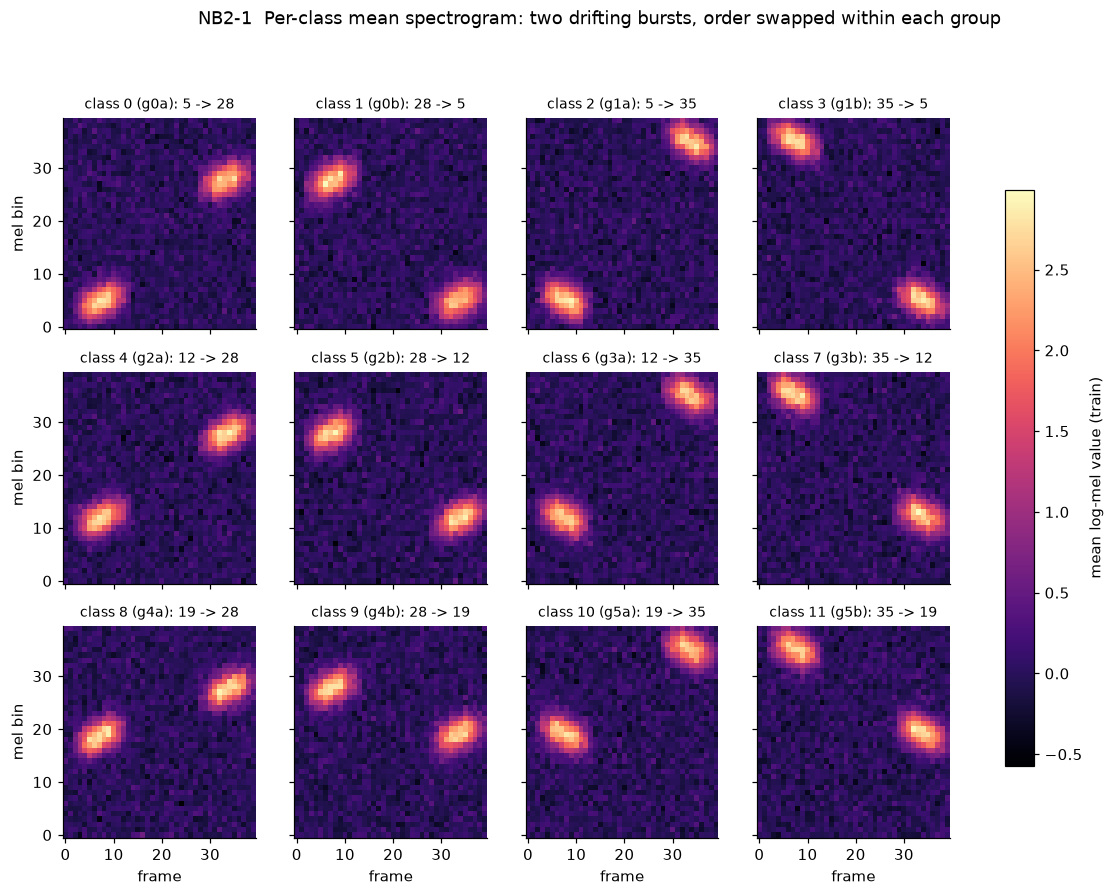

frame of the brightest cell per class: {'g0a': 7, 'g0b': 6, 'g1a': 9, 'g1b': 34, 'g2a': 34, 'g2b': 8, 'g3a': 32, 'g3b': 33, 'g4a': 32, 'g4b': 8, 'g5a': 8, 'g5b': 32}
[N2.3.1[cross_group_distance_above_noise_floor]] ||mean(class0) - mean(class2)||_F = 20.75 vs noise floor 5.66 -> PASS
[N2.3.1[order_swap_distance_above_noise_floor]] ||mean(class0) - mean(class1)||_F = 27.89 vs noise floor 5.66: order is visible in the full image -> PASS


True

In [5]:
# Fig NB2-1: per-class mean spectrogram (3 x 4 panels, one per class).
CLASS_NAMES = [f"g{SIG.loc[k, 'group']}{'ab'[SIG.loc[k, 'order']]}" for k in range(N_CLASSES)]
MEANS = np.stack([RAW["train"][Y["train"] == k, 0].mean(axis=0) for k in range(N_CLASSES)])   # (12, mel, frames)
assert_varied(MEANS.max(axis=(1, 2)) - MEANS.min(axis=(1, 2)), "mean_spectrogram_dynamic_range")
assert_varied(MEANS.reshape(N_CLASSES, -1).std(axis=1), "mean_spectrogram_spatial_std")
fig, axes = plt.subplots(3, 4, figsize=(13, 8.5), sharex=True, sharey=True)
vmin, vmax = MEANS.min(), MEANS.max()
for k, ax in enumerate(axes.ravel()):
    im = ax.imshow(MEANS[k], origin="lower", aspect="auto", cmap="magma", vmin=vmin, vmax=vmax)
    ax.set_title(f"class {k} ({CLASS_NAMES[k]}): {int(SIG.loc[k, 'first_centre'])} -> {int(SIG.loc[k, 'second_centre'])}", fontsize=9)
    ax.grid(False)
for ax in axes[-1]:
    ax.set_xlabel("frame")
for ax in axes[:, 0]:
    ax.set_ylabel("mel bin")
fig.colorbar(im, ax=axes, shrink=0.8, label="mean log-mel value (train)")
fig.suptitle("NB2-1  Per-class mean spectrogram: two drifting bursts, order swapped within each group", y=0.995)
savefig(fig, "NB2-1_class_means.png")
peak_frame = MEANS.max(axis=1).argmax(axis=1)
print("frame of the brightest cell per class:", dict(zip(CLASS_NAMES, peak_frame.tolist())))
# Noise floor of a 50-example class mean is sigma0/sqrt(50) per cell; a cross-group distance far above it means real structure.
floor = BASE_NOISE / np.sqrt(50) * np.sqrt(N_MELS * FRAMES)
cross = float(np.linalg.norm(MEANS[0] - MEANS[2]))
swap = float(np.linalg.norm(MEANS[0] - MEANS[1]))
check("N2.3.1[cross_group_distance_above_noise_floor]", cross > 3 * floor, f"||mean(class0) - mean(class2)||_F = {cross:.2f} vs noise floor {floor:.2f}")
check("N2.3.1[order_swap_distance_above_noise_floor]", swap > 3 * floor, f"||mean(class0) - mean(class1)||_F = {swap:.2f} vs noise floor {floor:.2f}: order is visible in the full image")

### How to read this chart

Each panel is the average of the 50 training spectrograms of one class: mel bin up, frame right, brighter is
more energy. Every panel shows two bright, slightly slanted streaks -- the two drifting bursts -- on an otherwise
featureless (averaged-out noise) background. The title gives the class name (`g<group><a|b>`) and the centre
frequencies of the first and second burst. Compare classes 0 and 1: the *same two streaks* appear, but the
low-frequency streak comes first in class 0 and second in class 1, so the panels are vertical reflections of each
other in time-ordering, not in content. Compare classes 0 and 2: the streaks sit at different mel heights, which is
the group-level (order-blind) difference. Because the colour scale is shared across panels, the streaks have equal
brightness everywhere; the classes differ in *where and when*, not in loudness. The slant flips sign between
adjacent groups (drift $\pm 0.4$ bins/frame), which is the "moving band" part of the signature.

[VARIED[time_averaged_profiles]] n=480 range=0.63 (constant would be a defect) -> PASS
[VARIED[low_band_energy_over_time]] n=480 range=0.7048 (constant would be a defect) -> PASS
[VARIED[within_vs_between_profile_gaps]] n=21 range=0.2521 (constant would be a defect) -> PASS


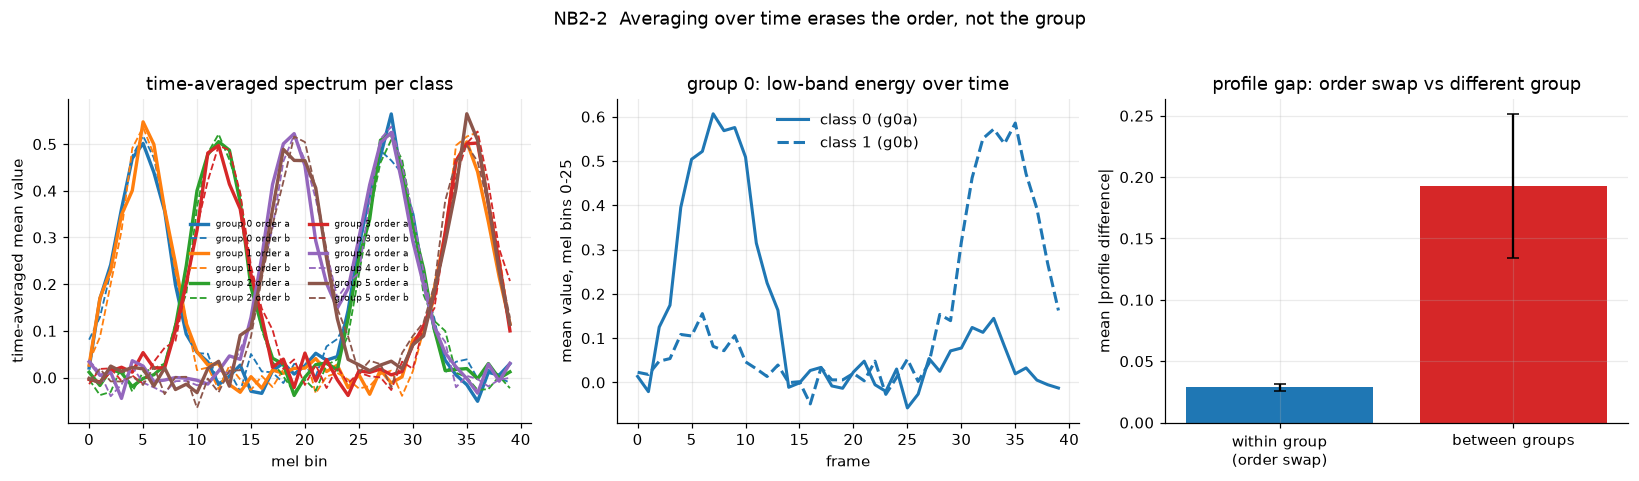

within-group profile gap 0.0286 +/- 0.0031; between-group 0.1926 +/- 0.0585
[N2.3.2[order_erased_by_time_average]] within/between profile gap ratio = 0.149 (<0.25) -> PASS
[N2.3.2[order_visible_in_time]] max |low-band energy difference| between order a and b = 0.57 -> PASS


True

In [6]:
# Fig NB2-2: time-marginal profiles. Same-group classes must coincide when time is averaged out.
prof = np.stack([MEANS[k].mean(axis=1) for k in range(N_CLASSES)])                     # (12, mel): time-averaged spectrum
low_energy = np.stack([MEANS[k][:26].mean(axis=0) for k in range(N_CLASSES)])           # (12, frames): mel<26 energy over time
within = np.array([np.abs(prof[2 * g] - prof[2 * g + 1]).mean() for g in range(N_GROUPS)])
between = np.array([np.abs(prof[2 * g] - prof[2 * h]).mean() for g in range(N_GROUPS) for h in range(g + 1, N_GROUPS)])
assert_varied(prof.ravel(), "time_averaged_profiles")
assert_varied(low_energy.ravel(), "low_band_energy_over_time")
assert_varied(np.concatenate([within, between]), "within_vs_between_profile_gaps")
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
cols = plt.cm.tab10(np.arange(N_GROUPS))
for g in range(N_GROUPS):
    ax[0].plot(prof[2 * g], color=cols[g], lw=2.2, label=f"group {g} order a")
    ax[0].plot(prof[2 * g + 1], color=cols[g], lw=1.2, ls="--", label=f"group {g} order b")
ax[0].set(xlabel="mel bin", ylabel="time-averaged mean value", title="time-averaged spectrum per class")
ax[0].legend(fontsize=6, ncol=2, frameon=False)
for k, ls in ((0, "-"), (1, "--")):
    ax[1].plot(low_energy[k], ls=ls, lw=2, color=cols[0], label=f"class {k} ({CLASS_NAMES[k]})")
ax[1].set(xlabel="frame", ylabel="mean value, mel bins 0-25", title="group 0: low-band energy over time")
ax[1].legend(frameon=False)
ax[2].bar(["within group\n(order swap)", "between groups"], [within.mean(), between.mean()], color=[PALETTE["clean"], PALETTE["shifted"]])
ax[2].errorbar([0, 1], [within.mean(), between.mean()], yerr=[within.std(), between.std()], fmt="none", ecolor="black", capsize=4)
ax[2].set(ylabel="mean |profile difference|", title="profile gap: order swap vs different group")
fig.suptitle("NB2-2  Averaging over time erases the order, not the group", y=1.03)
fig.tight_layout()
savefig(fig, "NB2-2_time_marginals.png")
print(f"within-group profile gap {within.mean():.4f} +/- {within.std():.4f}; between-group {between.mean():.4f} +/- {between.std():.4f}")
check("N2.3.2[order_erased_by_time_average]", within.mean() < 0.25 * between.mean(), f"within/between profile gap ratio = {within.mean() / between.mean():.3f} (<0.25)")
check("N2.3.2[order_visible_in_time]", float(np.abs(low_energy[0] - low_energy[1]).max()) > 0.5, f"max |low-band energy difference| between order a and b = {np.abs(low_energy[0] - low_energy[1]).max():.2f}")

### How to read this chart

**Left:** the time-averaged mel spectrum of every class. Solid and dashed lines of the same colour are the two
orders of one group; they lie almost exactly on top of each other, which is the point of the construction -- once
time is averaged out, order 0 and order 1 are the same signal. Different colours peak at different mel positions,
so the six groups remain separable. **Middle:** the low-frequency band's energy over frames for the two orders of
group 0. The solid curve peaks early and the dashed curve peaks late: this is the only information distinguishing
the pair, and it lives entirely on the time axis. **Right:** the mean absolute profile difference within a group
(an order swap) versus between groups. The within-group bar is a small fraction of the between-group bar; the
error bars are the standard deviation across the 6 within-group pairs and the 15 between-group pairs respectively.

In [7]:
# Model-free separability: linear classifiers on time-averaged features versus the full image.
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestCentroid
from sklearn.preprocessing import StandardScaler

def features(split, kind):
    x = X[split][:, 0]                                    # (n, mel, frames)
    return x.mean(axis=2) if kind == "time-mean (40-d)" else x.reshape(len(x), -1)

def fisher_ratio(F, y):
    # between-class variance over within-class variance, averaged over feature dimensions.
    overall = F.mean(axis=0)
    between = sum((y == k).sum() * (F[y == k].mean(axis=0) - overall) ** 2 for k in np.unique(y)) / len(y)
    within = sum(((F[y == k] - F[y == k].mean(axis=0)) ** 2).sum(axis=0) for k in np.unique(y)) / len(y)
    return float(np.mean(between / np.maximum(within, 1e-12)))

rows = []
for kind in ("time-mean (40-d)", "full image (1600-d)"):
    Ftr, Fte = features("train", kind), features("test", kind)
    sc = StandardScaler().fit(Ftr)
    lr = LogisticRegression(max_iter=300, C=0.05).fit(sc.transform(Ftr), Y["train"])
    pred = lr.predict(sc.transform(Fte))
    nc = NearestCentroid().fit(Ftr, Y["train"])
    rows.append({"features": kind, "logreg test acc": float((pred == Y["test"]).mean()),
                 "logreg group acc": float((pred // 2 == Y["test"] // 2).mean()),
                 "nearest-centroid acc": float((nc.predict(Fte) == Y["test"]).mean()),
                 "fisher ratio": fisher_ratio(Ftr, Y["train"])})
SEP = pd.DataFrame(rows).set_index("features")
display(SEP.round(3))
tm, fu = SEP.iloc[0], SEP.iloc[1]
check("N2.3.3[time_mean_capped_near_half]", tm["logreg test acc"] < 0.6 and tm["logreg group acc"] > 0.9, f"time-mean logreg: acc {tm['logreg test acc']:.3f}, group acc {tm['logreg group acc']:.3f} (order cannot be read)")
check("N2.3.3[time_mean_far_above_chance]", tm["logreg test acc"] > 3 * (1 / N_CLASSES), f"time-mean acc {tm['logreg test acc']:.3f} is > 3x chance {1 / N_CLASSES:.3f}")
check("N2.3.3[full_image_beats_time_mean]", fu["logreg test acc"] > tm["logreg test acc"] + 0.2, f"full image {fu['logreg test acc']:.3f} vs time-mean {tm['logreg test acc']:.3f}")
check("N2.3.3[task_is_learnable]", fu["logreg test acc"] > 0.8, f"a linear model on the full image reaches {fu['logreg test acc']:.3f}: the class structure is real")
note("N2.3.3[preview]", f"model-free preview of the Section 4 headline: dropping time costs {fu['logreg test acc'] - tm['logreg test acc']:.3f} accuracy for a linear classifier")

                     logreg test acc  logreg group acc  nearest-centroid acc  fisher ratio
features                                                                                  
time-mean (40-d)                0.52               1.0                 0.533         1.134
full image (1600-d)             1.00               1.0                 1.000         0.180

[N2.3.3[time_mean_capped_near_half]] time-mean logreg: acc 0.520, group acc 1.000 (order cannot be read) -> PASS
[N2.3.3[time_mean_far_above_chance]] time-mean acc 0.520 is > 3x chance 0.083 -> PASS
[N2.3.3[full_image_beats_time_mean]] full image 1.000 vs time-mean 0.520 -> PASS
[N2.3.3[task_is_learnable]] a linear model on the full image reaches 1.000: the class structure is real -> PASS
[N2.3.3[preview]] model-free preview of the Section 4 headline: dropping time costs 0.480 accuracy for a linear classifier -> NOTE


[VARIED[pca_pc1[time-mean (40-d)]]] n=600 range=2.183 (constant would be a defect) -> PASS
[VARIED[pca_pc2[time-mean (40-d)]]] n=600 range=2.104 (constant would be a defect) -> PASS


[VARIED[pca_pc1[full image (1600-d)]]] n=600 range=21.57 (constant would be a defect) -> PASS
[VARIED[pca_pc2[full image (1600-d)]]] n=600 range=19.23 (constant would be a defect) -> PASS


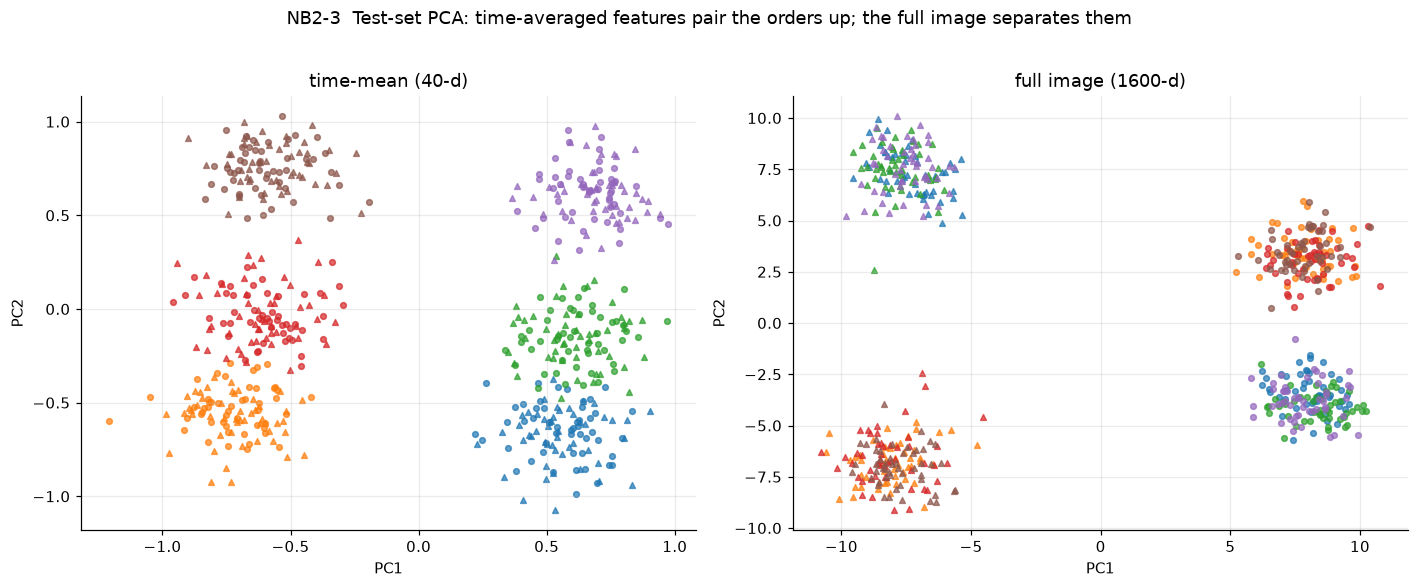

time-mean (40-d): mean order-swap centroid distance 0.033, mean between-group centroid distance 1.208, ratio 0.028
full image (1600-d): mean order-swap centroid distance 19.042, mean between-group centroid distance 4.428, ratio 4.300
[N2.3.4[time_mean_pairs_collapse]] in time-mean PCA the two orders of a group nearly coincide -> PASS
[N2.3.4[full_image_pairs_apart]] in the full-image PCA the order-swap distance is relatively larger -> PASS


True

In [8]:
# Fig NB2-3: 2D PCA of the two feature views. Colour = group, marker = order.
from sklearn.decomposition import PCA
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
stats = {}
for a, kind in zip(ax, ("time-mean (40-d)", "full image (1600-d)")):
    F = features("test", kind)
    Z = PCA(n_components=2, random_state=0).fit(features("train", kind)).transform(F)
    stats[kind] = Z
    assert_varied(Z[:, 0], f"pca_pc1[{kind}]")
    assert_varied(Z[:, 1], f"pca_pc2[{kind}]")
    for k in range(N_CLASSES):
        sel = Y["test"] == k
        a.scatter(Z[sel, 0], Z[sel, 1], s=14, alpha=0.7, color=cols[SIG.loc[k, "group"]], marker="o" if SIG.loc[k, "order"] == 0 else "^")
    a.set(title=kind, xlabel="PC1", ylabel="PC2")
fig.suptitle("NB2-3  Test-set PCA: time-averaged features pair the orders up; the full image separates them", y=1.02)
fig.tight_layout()
savefig(fig, "NB2-3_pca.png")
# Cluster geometry in PCA space: distance between the two order centroids of a group vs between group centroids.
def centroid(Z, k): return Z[Y["test"] == k].mean(axis=0)
gap = {}
for kind, Z in stats.items():
    wi = np.mean([np.linalg.norm(centroid(Z, 2 * g) - centroid(Z, 2 * g + 1)) for g in range(N_GROUPS)])
    bt = np.mean([np.linalg.norm(centroid(Z, 2 * g) - centroid(Z, 2 * h)) for g in range(N_GROUPS) for h in range(g + 1, N_GROUPS)])
    gap[kind] = (wi, bt)
    print(f"{kind}: mean order-swap centroid distance {wi:.3f}, mean between-group centroid distance {bt:.3f}, ratio {wi / bt:.3f}")
check("N2.3.4[time_mean_pairs_collapse]", gap["time-mean (40-d)"][0] / gap["time-mean (40-d)"][1] < 0.2, "in time-mean PCA the two orders of a group nearly coincide")
check("N2.3.4[full_image_pairs_apart]", gap["full image (1600-d)"][0] / gap["full image (1600-d)"][1] > gap["time-mean (40-d)"][0] / gap["time-mean (40-d)"][1], "in the full-image PCA the order-swap distance is relatively larger")

### How to read this chart

Each dot is one test example projected to two principal components; colour is the group (6 colours) and marker
shape is the order (circle = order a, triangle = order b). **Left (time-averaged features):** dots of one colour
form a single blob in which circles and triangles are thoroughly mixed -- the order information is not present in
this feature space, so a classifier built on it cannot separate the pair. **Right (full time-frequency image):**
the projection is dominated by the class-specific placement of the two bursts in time and frequency, and the
circle/triangle pairs move apart. Keep in mind that PCA preserves variance, not class separation, so absolute
separation is understated; the reliable statement is the *ratio* printed under the figure, order-swap centroid
distance divided by between-group centroid distance, which is smaller for the time-averaged view.

[VARIED[split_sizes]] n=5 range=360 (constant would be a defect) -> PASS
[VARIED[split_raw_means]] n=5 range=0.002607 (constant would be a defect) -> PASS
[VARIED[split_raw_stds]] n=5 range=0.003126 (constant would be a defect) -> PASS


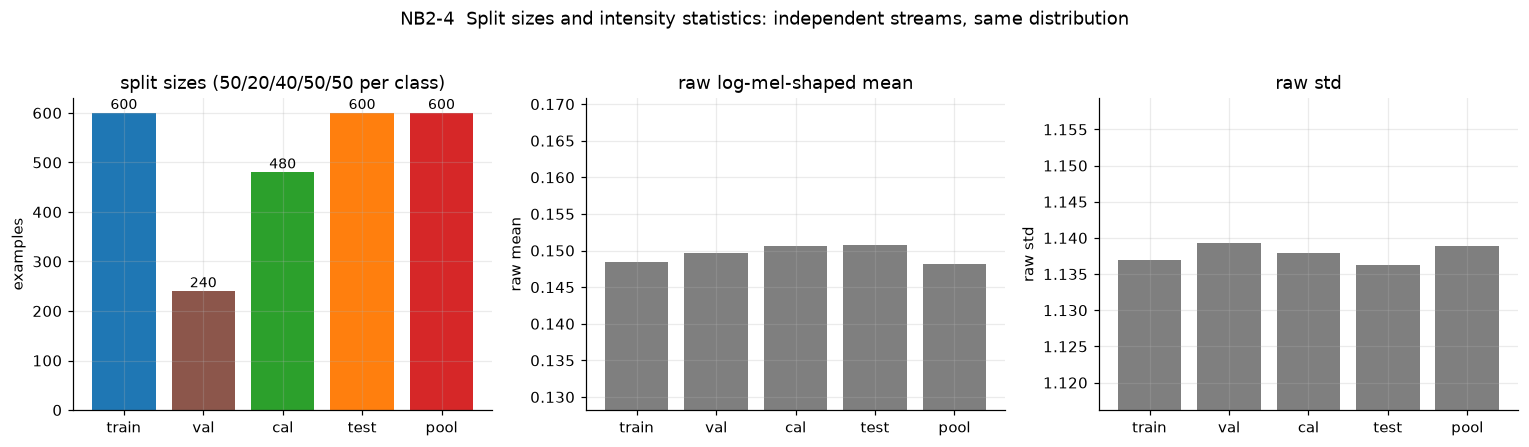

[N2.3.5[splits_same_distribution]] raw means across the five splits differ by at most 0.0026 (same generator, independent seeds) -> PASS
[N2.3.5[splits_are_distinct_draws]] no two splits share examples -> PASS
[N2.3.5[total_examples]] 2520 examples generated in total -> PASS


True

In [9]:
# Fig NB2-4: split sizes and per-split raw intensity statistics (values vary across splits by construction).
split_names = list(SPLIT_SIZES) + ["pool"]
sizes = np.array([len(Y[s]) for s in split_names], dtype=float)
means = np.array([RAW[s].mean() for s in split_names])
stds = np.array([RAW[s].std() for s in split_names])
assert_varied(sizes, "split_sizes")
assert_varied(means, "split_raw_means")
assert_varied(stds, "split_raw_stds")
fig, ax = plt.subplots(1, 3, figsize=(14, 3.9))
bars = ax[0].bar(split_names, sizes, color=[PALETTE["clean"], PALETTE["adapted"], PALETTE["acoustic"], PALETTE["mask"], PALETTE["shifted"]])
for b, s in zip(bars, sizes):
    ax[0].text(b.get_x() + b.get_width() / 2, s + 8, int(s), ha="center", fontsize=9)
ax[0].set(ylabel="examples", title="split sizes (50/20/40/50/50 per class)")
ax[1].bar(split_names, means, color=PALETTE["reference"]); ax[1].set(ylabel="raw mean", title="raw log-mel-shaped mean")
ax[2].bar(split_names, stds, color=PALETTE["reference"]); ax[2].set(ylabel="raw std", title="raw std")
ax[1].set_ylim(means.min() - 0.02, means.max() + 0.02); ax[2].set_ylim(stds.min() - 0.02, stds.max() + 0.02)
fig.suptitle("NB2-4  Split sizes and intensity statistics: independent streams, same distribution", y=1.03)
fig.tight_layout()
savefig(fig, "NB2-4_splits.png")
drift_mu = float(np.ptp(means))
check("N2.3.5[splits_same_distribution]", drift_mu < 0.02, f"raw means across the five splits differ by at most {drift_mu:.4f} (same generator, independent seeds)")
check("N2.3.5[splits_are_distinct_draws]", not np.array_equal(RAW["train"][:20], RAW["val"][:20]) and not np.array_equal(RAW["test"][:20], RAW["pool"][:20]), "no two splits share examples")
check("N2.3.5[total_examples]", int(sizes.sum()) == 600 + 240 + 480 + 600 + 600, f"{int(sizes.sum())} examples generated in total")

### How to read this chart

**Left:** the number of examples in each split. Train is the largest of the labelled splits (600), followed by test
(600), calibration (480) and validation (240); the shift pool (600) is set aside for Section 8. Sizes are equal per
class (50/20/40/50/50), so class balance is exactly uniform in every split and no per-class bar chart would carry
information -- an all-equal chart is exactly the defect `assert_varied` guards against, which is why it is
not drawn. **Middle and right:** the raw mean and standard deviation of each split. The axes are zoomed to a
$\pm 0.02$ window, so differences that look large are a few thousandths; the check underneath states the actual
spread. The point of the panel is the opposite of a finding: the five splits are independent draws from one
distribution, so any train-test gap seen later is a property of the models, not of the split.

## 4. Architecture comparison: what does global average pooling cost?

`src/models.py` defines four classifiers. They share a convolutional front-end and differ mainly in what they do
with the **time axis**:

| name here | class | time handling | parameters |
|---|---|---|---|
| `logmel_pool` | `LogMelCNN` | `AdaptiveAvgPool2d((1,1))` averages time **and** mel away; the classifier sees 32 channel means | small |
| `timepool` | `TimePoolCNN` | same convolutions, but pools to `(1, 8)`: eight temporal slots survive | small |
| `wide` | `WideCNN` | wider and deeper, still keeps 8 temporal slots | large |
| `convgru` | `ConvGRU` | pools only the mel axis; a bidirectional GRU runs over all time steps | large |

**The prediction.** On the Section 2 task the two classes of a group have identical time-averaged spectra. A
model whose last feature stage is a global average has, for a fixed network, the same output for an example and
for any permutation of its frames' *post-convolution* summary -- more precisely, its classifier sees only
$\bar h_c = \frac{1}{MT}\sum_{m,t} h_{c,m,t}$ per channel $c$, a bag of local patterns. Local patterns (a
burst, a band edge) are identical across the two orders because a burst looks the same whether it comes first or
last, and the receptive field cannot span the >15-frame gap. So `logmel_pool` should identify the group but
guess the order:

$$\text{acc}(\texttt{logmel\_pool}) \lesssim \tfrac{1}{2}, \qquad \text{acc}(\text{time-preserving}) \text{ unconstrained}.$$

**The protocol.** All four models train with the *same* `ExperimentConfig`, the same seed, the same data, and
the same augmentation (none). We report test accuracy, *group accuracy* (is the predicted class in the correct
group? order-blind), and *order accuracy* (among test examples whose group was predicted correctly, was the
order right?). The last quantity is $\approx 0.5$ for any model that cannot use temporal order and $\to 1$ for
one that can. Whatever we measure is reported as measured; if the predicted gap does not appear, Section 4.3 says
so and investigates rather than adjusting the task.

In [10]:
# Training configuration shared by all four architectures, and the probe batch for SentryCam.
from dataclasses import replace
from src.models import LogMelCNN, TimePoolCNN, WideCNN, ConvGRU
from src.train import train_classifier, predict_logits
from src.diagnostics import sentrycam_probe, sentrycam_alert_epoch, cluster_drift_metrics, project_2d
from src.experiment import ExperimentConfig
from src.calibration import temperature_scale, prediction_sets, crc_threshold
from src.metrics import expected_calibration_error

EPOCHS, MICROBATCH = 10, 32
CFG = ExperimentConfig(condition="clean", seed=MODEL_SEED, max_epochs=EPOCHS, patience=EPOCHS,
                       microbatch_size=MICROBATCH, accumulation_steps=1, autoclip_percentile=10.0)
ARCHS = {"logmel_pool": LogMelCNN, "timepool": TimePoolCNN, "wide": WideCNN, "convgru": ConvGRU}
ACOL = {"logmel_pool": PALETTE["shifted"], "timepool": PALETTE["mask"], "wide": PALETTE["acoustic"], "convgru": PALETTE["clean"]}

# Probe batch: the first 10 validation examples of every class (120 in total, fixed for every epoch and architecture).
PROBE_IDX = np.concatenate([np.flatnonzero(Y["val"] == k)[:10] for k in range(N_CLASSES)])
PROBE_X = torch.from_numpy(X["val"][PROBE_IDX])
PROBE_Y = Y["val"][PROBE_IDX]

def probe_fn(model, epoch):
    # Called by train_classifier once per epoch, inside its no-grad eval block.
    return sentrycam_probe(model, PROBE_X, PROBE_Y, keep_sequence=False)

def softmax64(logits):
    z = np.asarray(logits, dtype=np.float64)
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def evaluate(model, split="test"):
    # Overall, group (order-blind) and conditional order accuracy for a fitted model.
    logits = predict_logits(model, X[split])
    pred, y = logits.argmax(axis=1), Y[split]
    right_group = pred // 2 == y // 2
    return {"acc": float((pred == y).mean()), "group_acc": float(right_group.mean()),
            "order_acc": float((pred[right_group] == y[right_group]).mean()) if right_group.any() else float("nan"),
            "logits": logits}

print(CFG)
print("probe batch:", PROBE_X.shape, "labels per class:", np.bincount(PROBE_Y).tolist())
check("N2.4.1[config_shared]", CFG.max_epochs == EPOCHS and CFG.seed == MODEL_SEED and CFG.microbatch_size == MICROBATCH, f"one ExperimentConfig for all four models: {EPOCHS} epochs, seed {MODEL_SEED}, microbatch {MICROBATCH}")
check("N2.4.1[probe_batch_balanced]", len(set(np.bincount(PROBE_Y).tolist())) == 1 and len(PROBE_Y) == 120, "probe batch is class-balanced (10 per class)")
check("N2.4.1[chance_reference]", abs(1 / N_CLASSES - 0.08333) < 1e-4, "chance for 12 classes is 1/12 = 0.0833")

ExperimentConfig(condition='clean', seed=17, max_epochs=10, patience=10, microbatch_size=32, accumulation_steps=1, autoclip_percentile=10.0)
probe batch: torch.Size([120, 1, 40, 40]) labels per class: [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
[N2.4.1[config_shared]] one ExperimentConfig for all four models: 10 epochs, seed 17, microbatch 32 -> PASS
[N2.4.1[probe_batch_balanced]] probe batch is class-balanced (10 per class) -> PASS
[N2.4.1[chance_reference]] chance for 12 classes is 1/12 = 0.0833 -> PASS


True

In [11]:
# Train all four architectures with identical config and seed, with the SentryCam probe attached.
RUNS, EVAL, WALL = {}, {}, {}
for name, cls in ARCHS.items():
    torch.manual_seed(MODEL_SEED)
    t0 = time.time()
    RUNS[name] = train_classifier(cls(n_mels=N_MELS, num_classes=N_CLASSES), X["train"], Y["train"], X["val"], Y["val"], CFG, probe_fn=probe_fn)
    WALL[name] = time.time() - t0
    EVAL[name] = evaluate(RUNS[name].model)
    r = RUNS[name]
    print(f"{name:12s} params={sum(p.numel() for p in r.model.parameters()):>8,d} epochs={r.epochs_run} best_epoch={r.best_epoch} "
          f"val_acc={r.history[-1]['val_accuracy']:.3f} test_acc={EVAL[name]['acc']:.3f} group={EVAL[name]['group_acc']:.3f} "
          f"order|group={EVAL[name]['order_acc']:.3f} wall={WALL[name]:.1f}s")
for name, r in RUNS.items():
    check(f"N2.4.2[{name}.ran_all_epochs]", r.epochs_run == EPOCHS, f"{r.epochs_run} epochs run (patience = max_epochs so no early stop)")
    check(f"N2.4.2[{name}.probes_recorded]", len(r.probe_history) == EPOCHS, f"{len(r.probe_history)} probe records, one per epoch")

logmel_pool  params=  14,524 epochs=10 best_epoch=9 val_acc=0.171 test_acc=0.178 group=0.355 order|group=0.502 wall=45.7s


timepool     params=  17,212 epochs=10 best_epoch=9 val_acc=0.529 test_acc=0.533 group=0.612 order|group=0.872 wall=19.1s


wide         params= 271,692 epochs=10 best_epoch=9 val_acc=1.000 test_acc=1.000 group=1.000 order|group=1.000 wall=77.7s


convgru      params= 291,564 epochs=10 best_epoch=9 val_acc=1.000 test_acc=1.000 group=1.000 order|group=1.000 wall=69.2s
[N2.4.2[logmel_pool.ran_all_epochs]] 10 epochs run (patience = max_epochs so no early stop) -> PASS
[N2.4.2[logmel_pool.probes_recorded]] 10 probe records, one per epoch -> PASS
[N2.4.2[timepool.ran_all_epochs]] 10 epochs run (patience = max_epochs so no early stop) -> PASS
[N2.4.2[timepool.probes_recorded]] 10 probe records, one per epoch -> PASS
[N2.4.2[wide.ran_all_epochs]] 10 epochs run (patience = max_epochs so no early stop) -> PASS
[N2.4.2[wide.probes_recorded]] 10 probe records, one per epoch -> PASS
[N2.4.2[convgru.ran_all_epochs]] 10 epochs run (patience = max_epochs so no early stop) -> PASS
[N2.4.2[convgru.probes_recorded]] 10 probe records, one per epoch -> PASS


In [12]:
# Summary table of the four runs.
SUMMARY = pd.DataFrame({
    name: {"parameters": sum(p.numel() for p in RUNS[name].model.parameters()),
           "final val acc": RUNS[name].history[-1]["val_accuracy"],
           "best val loss": min(h["val_loss"] for h in RUNS[name].history),
           "test acc": EVAL[name]["acc"], "group acc": EVAL[name]["group_acc"], "order acc | group": EVAL[name]["order_acc"],
           "wall seconds": WALL[name]} for name in RUNS}).T
display(SUMMARY.round(3))
for name in RUNS:
    check(f"N2.4.3[{name}.above_chance]", EVAL[name]["acc"] > 1 / N_CLASSES if name == "logmel_pool" else EVAL[name]["acc"] > 3 / N_CLASSES,
          f"test accuracy {EVAL[name]['acc']:.3f} vs chance {1 / N_CLASSES:.3f}" + ("" if name == "logmel_pool" else " (a time-preserving model must clear 3x chance)"))

             parameters  final val acc  best val loss  test acc  group acc  order acc | group  wall seconds
logmel_pool     14524.0          0.171          2.021     0.178      0.355              0.502        45.678
timepool        17212.0          0.529          1.381     0.533      0.612              0.872        19.124
wide           271692.0          1.000          0.010     1.000      1.000              1.000        77.651
convgru        291564.0          1.000          0.033     1.000      1.000              1.000        69.175

[N2.4.3[logmel_pool.above_chance]] test accuracy 0.178 vs chance 0.083 -> PASS
[N2.4.3[timepool.above_chance]] test accuracy 0.533 vs chance 0.083 (a time-preserving model must clear 3x chance) -> PASS
[N2.4.3[wide.above_chance]] test accuracy 1.000 vs chance 0.083 (a time-preserving model must clear 3x chance) -> PASS
[N2.4.3[convgru.above_chance]] test accuracy 1.000 vs chance 0.083 (a time-preserving model must clear 3x chance) -> PASS


[VARIED[val_acc[logmel_pool]]] n=10 range=0.1167 (constant would be a defect) -> PASS
[VARIED[val_loss[logmel_pool]]] n=10 range=0.4576 (constant would be a defect) -> PASS
[VARIED[val_acc[timepool]]] n=10 range=0.4375 (constant would be a defect) -> PASS
[VARIED[val_loss[timepool]]] n=10 range=1.091 (constant would be a defect) -> PASS
[VARIED[val_acc[wide]]] n=10 range=0.4208 (constant would be a defect) -> PASS
[VARIED[val_loss[wide]]] n=10 range=1.663 (constant would be a defect) -> PASS
[VARIED[val_acc[convgru]]] n=10 range=0.4792 (constant would be a defect) -> PASS
[VARIED[val_loss[convgru]]] n=10 range=1.885 (constant would be a defect) -> PASS


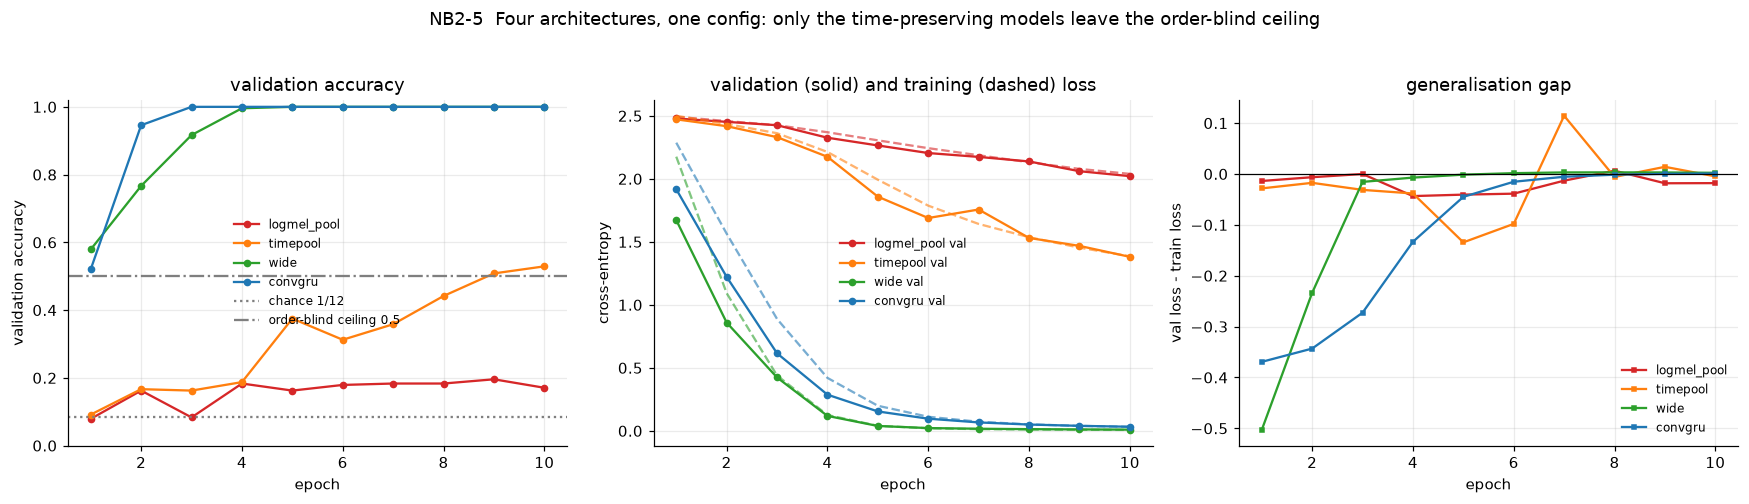

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb2/NB2-5_training_curves.png')

In [13]:
# Fig NB2-5: validation accuracy and loss per epoch for all four architectures.
epochs = np.arange(1, EPOCHS + 1)
VA = {n: np.array([h["val_accuracy"] for h in RUNS[n].history]) for n in RUNS}
VL = {n: np.array([h["val_loss"] for h in RUNS[n].history]) for n in RUNS}
TL = {n: np.array([h["train_loss"] for h in RUNS[n].history]) for n in RUNS}
for n in RUNS:
    assert_varied(VA[n], f"val_acc[{n}]")
    assert_varied(VL[n], f"val_loss[{n}]")
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
for n in RUNS:
    ax[0].plot(epochs, VA[n], marker="o", ms=4, color=ACOL[n], label=n)
    ax[1].plot(epochs, VL[n], marker="o", ms=4, color=ACOL[n], label=f"{n} val")
    ax[1].plot(epochs, TL[n], ls="--", color=ACOL[n], alpha=0.6)
    ax[2].plot(epochs, VL[n] - TL[n], marker="s", ms=3, color=ACOL[n], label=n)
ax[0].axhline(1 / N_CLASSES, color=PALETTE["reference"], ls=":", label="chance 1/12")
ax[0].axhline(0.5, color=PALETTE["reference"], ls="-.", label="order-blind ceiling 0.5")
ax[0].set(xlabel="epoch", ylabel="validation accuracy", ylim=(0, 1.02), title="validation accuracy")
ax[1].set(xlabel="epoch", ylabel="cross-entropy", title="validation (solid) and training (dashed) loss")
ax[2].axhline(0, color="black", lw=0.8)
ax[2].set(xlabel="epoch", ylabel="val loss - train loss", title="generalisation gap")
for a in ax:
    a.legend(fontsize=8, frameon=False)
fig.suptitle("NB2-5  Four architectures, one config: only the time-preserving models leave the order-blind ceiling", y=1.03)
fig.tight_layout()
savefig(fig, "NB2-5_training_curves.png")

### How to read this chart

**Left:** validation accuracy per epoch. The dotted line is chance ($1/12 = 0.083$); the dash-dot line is the
order-blind ceiling ($0.5$) derived in Section 2. A curve that stays below the dash-dot line is consistent with
a model that cannot use temporal order; a curve that crosses above it must be using order. **Middle:** solid
lines are validation loss and dashed lines training loss of the same colour; a shrinking solid line means the
model is learning something that generalises. **Right:** validation minus training loss. Values above zero
indicate overfitting to the 600 training examples; values near zero mean the model is not fitting the training set
any better than the held-out set (either because it is still underfitting or because there is nothing more to
learn). With only ten epochs and a fixed learning rate of $10^{-3}$ these are short-horizon curves, not converged
ones.

logmel_pool {'acc': '0.228 +/- 0.048', 'group_acc': '0.437 +/- 0.087', 'order_acc': '0.522 +/- 0.014'} over seeds (17, 23, 31)
timepool {'acc': '0.543 +/- 0.013', 'group_acc': '0.628 +/- 0.014', 'order_acc': '0.864 +/- 0.011'} over seeds (17, 23, 31)
[VARIED[test_acc_across_architectures]] n=4 range=0.8217 (constant would be a defect) -> PASS
[VARIED[order_acc_across_architectures]] n=4 range=0.4977 (constant would be a defect) -> PASS


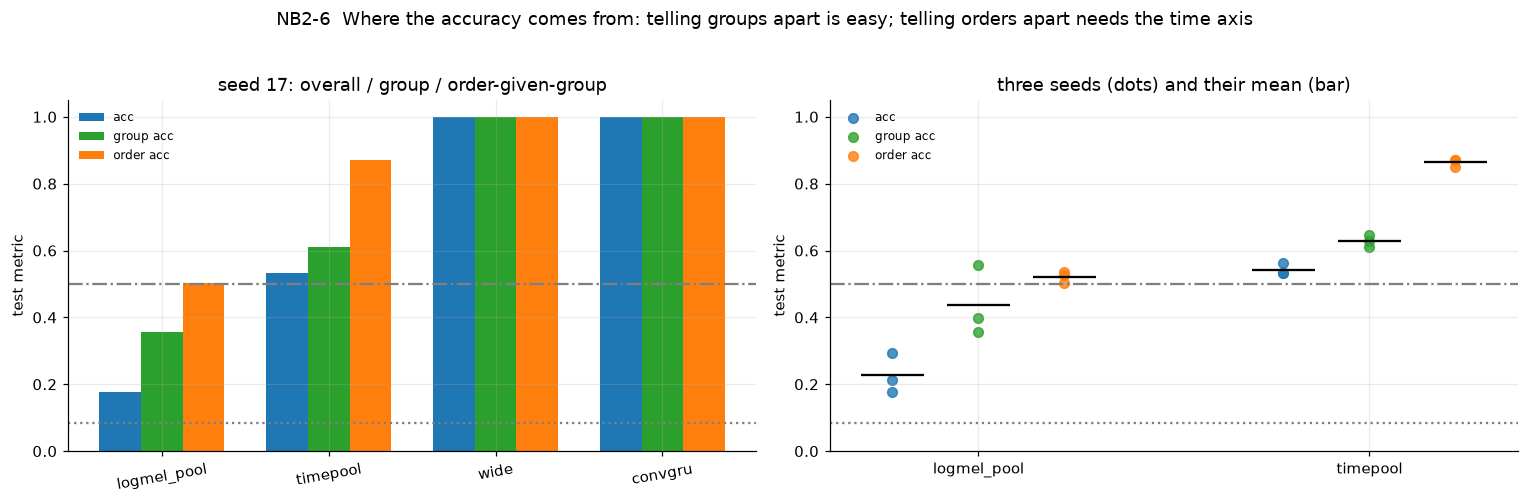

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb2/NB2-6_accuracy_decomposition.png')

In [14]:
# Fig NB2-6: test accuracy decomposed into group accuracy and order accuracy, with seed variation for the two cheap models.
EXTRA_SEEDS = (23, 31)
SEEDED = {"logmel_pool": [EVAL["logmel_pool"]], "timepool": [EVAL["timepool"]]}
for name in SEEDED:
    for s in EXTRA_SEEDS:
        torch.manual_seed(s)
        res = train_classifier(ARCHS[name](n_mels=N_MELS, num_classes=N_CLASSES), X["train"], Y["train"], X["val"], Y["val"], replace(CFG, seed=s))
        SEEDED[name].append(evaluate(res.model))
SEED_TABLE = pd.DataFrame({name: {m: [e[m] for e in SEEDED[name]] for m in ("acc", "group_acc", "order_acc")} for name in SEEDED}).T
seed_stats = {name: {m: (np.mean([e[m] for e in ev]), np.std([e[m] for e in ev])) for m in ("acc", "group_acc", "order_acc")} for name, ev in SEEDED.items()}
for name, st in seed_stats.items():
    print(name, {m: f"{v[0]:.3f} +/- {v[1]:.3f}" for m, v in st.items()}, "over seeds", (MODEL_SEED,) + EXTRA_SEEDS)
metrics = ("acc", "group_acc", "order_acc")
vals = np.array([[EVAL[n][m] for m in metrics] for n in RUNS])
assert_varied(vals[:, 0], "test_acc_across_architectures")
assert_varied(vals[:, 2], "order_acc_across_architectures")
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
w = 0.25
for j, m in enumerate(metrics):
    ax[0].bar(np.arange(len(RUNS)) + (j - 1) * w, vals[:, j], w, label=m.replace("_", " "), color=[PALETTE["clean"], PALETTE["acoustic"], PALETTE["mask"]][j])
ax[0].axhline(1 / N_CLASSES, color=PALETTE["reference"], ls=":"); ax[0].axhline(0.5, color=PALETTE["reference"], ls="-.")
ax[0].set_xticks(range(len(RUNS)), list(RUNS), rotation=10)
ax[0].set(ylabel="test metric", ylim=(0, 1.05), title="seed 17: overall / group / order-given-group")
ax[0].legend(frameon=False, fontsize=8)
for i, (name, ev) in enumerate(SEEDED.items()):
    for j, m in enumerate(metrics):
        pts = [e[m] for e in ev]
        ax[1].scatter([i + (j - 1) * 0.22] * len(pts), pts, s=40, color=[PALETTE["clean"], PALETTE["acoustic"], PALETTE["mask"]][j], alpha=0.8, label=m.replace("_", " ") if i == 0 else None)
        ax[1].hlines(np.mean(pts), i + (j - 1) * 0.22 - 0.08, i + (j - 1) * 0.22 + 0.08, color="black")
ax[1].set_xticks(range(len(SEEDED)), list(SEEDED))
ax[1].axhline(1 / N_CLASSES, color=PALETTE["reference"], ls=":"); ax[1].axhline(0.5, color=PALETTE["reference"], ls="-.")
ax[1].set(ylabel="test metric", ylim=(0, 1.05), title="three seeds (dots) and their mean (bar)")
ax[1].legend(frameon=False, fontsize=8)
fig.suptitle("NB2-6  Where the accuracy comes from: telling groups apart is easy; telling orders apart needs the time axis", y=1.03)
fig.tight_layout()
savefig(fig, "NB2-6_accuracy_decomposition.png")

### How to read this chart

Three metrics per architecture. *Overall* is ordinary 12-way test accuracy. *Group* is order-blind: a prediction
counts if it lands in the right pair of classes. *Order* is measured only on examples whose group was right, and
asks whether the model then picked the right member of the pair -- chance for that question is $0.5$, which is the
dash-dot line on this panel. **Left:** seed 17, all four architectures. **Right:** the two cheap models over three
seeds (17, 23, 31); each dot is a seed and the black tick is the mean, so the spread of the dots is the seed noise
that any single-seed comparison has to be read against. If the dots of two architectures for the same metric
overlap, the data do not support a ranking on that metric.

In [15]:
# The headline comparison, stated numerically, with an honest verdict.
pool_acc, pool_ord = EVAL["logmel_pool"]["acc"], EVAL["logmel_pool"]["order_acc"]
tp_only = {n: EVAL[n]["acc"] for n in ("timepool", "wide", "convgru")}
best_name = max(tp_only, key=tp_only.get)
gap = tp_only[best_name] - pool_acc
print(f"logmel_pool (global average): test acc {pool_acc:.3f}, order|group {pool_ord:.3f}")
for n, a in tp_only.items():
    print(f"  {n:9s} (keeps time)      : test acc {a:.3f}, order|group {EVAL[n]['order_acc']:.3f}, gap over pool {a - pool_acc:+.3f}")
check("N2.4.4[headline.best_time_model_beats_pool]", gap > 0.1, f"best time-preserving model ({best_name}) beats logmel_pool by {gap:+.3f} test accuracy (needs > 0.1)")
check("N2.4.4[headline.every_time_model_beats_pool]", all(a > pool_acc for a in tp_only.values()), "all three time-preserving models exceed the globally pooled baseline: " + ", ".join(f"{n} {a:.3f}" for n, a in tp_only.items()))
check("N2.4.4[headline.pool_below_order_blind_ceiling]", pool_acc <= 0.5 + 0.05, f"logmel_pool accuracy {pool_acc:.3f} is at or below the order-blind ceiling 0.5 (+0.05 sampling slack, n=600)")
check("N2.4.4[headline.pool_cannot_order]", abs(pool_ord - 0.5) < 0.15, f"logmel_pool order|group = {pool_ord:.3f}, within 0.15 of coin-flip 0.5")
check("N2.4.4[headline.best_model_reads_order]", EVAL[best_name]["order_acc"] > 0.8, f"{best_name} order|group = {EVAL[best_name]['order_acc']:.3f}")
pool_seeds = [e["acc"] for e in SEEDED["logmel_pool"]]
tp_seeds = [e["acc"] for e in SEEDED["timepool"]]
note("N2.4.4[headline.timepool_vs_pool_over_seeds]", f"timepool minus logmel_pool per seed: {[round(b - a, 3) for a, b in zip(pool_seeds, tp_seeds)]}")
check("N2.4.4[headline.timepool_beats_pool_every_seed]", all(b > a for a, b in zip(pool_seeds, tp_seeds)), "TimePoolCNN (a one-line pooling change) beats LogMelCNN on every one of the three seeds")

logmel_pool (global average): test acc 0.178, order|group 0.502
  timepool  (keeps time)      : test acc 0.533, order|group 0.872, gap over pool +0.355
  wide      (keeps time)      : test acc 1.000, order|group 1.000, gap over pool +0.822
  convgru   (keeps time)      : test acc 1.000, order|group 1.000, gap over pool +0.822
[N2.4.4[headline.best_time_model_beats_pool]] best time-preserving model (wide) beats logmel_pool by +0.822 test accuracy (needs > 0.1) -> PASS
[N2.4.4[headline.every_time_model_beats_pool]] all three time-preserving models exceed the globally pooled baseline: timepool 0.533, wide 1.000, convgru 1.000 -> PASS
[N2.4.4[headline.pool_below_order_blind_ceiling]] logmel_pool accuracy 0.178 is at or below the order-blind ceiling 0.5 (+0.05 sampling slack, n=600) -> PASS
[N2.4.4[headline.pool_cannot_order]] logmel_pool order|group = 0.502, within 0.15 of coin-flip 0.5 -> PASS
[N2.4.4[headline.best_model_reads_order]] wide order|group = 1.000 -> PASS
[N2.4.4[headline.time

True

[VARIED[confusion[logmel_pool]]] n=144 range=1 (constant would be a defect) -> PASS
[VARIED[confusion[wide]]] n=144 range=1 (constant would be a defect) -> PASS


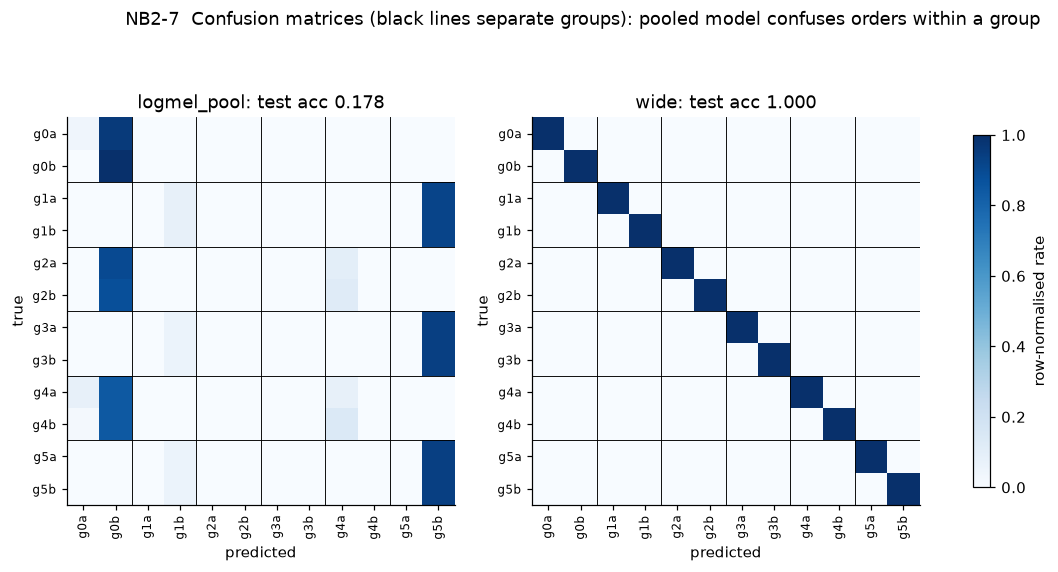

logmel_pool: mass inside the 2x2 group blocks = 0.355; mass on the true class = 0.178
[N2.4.5[pool_confusions_stay_in_group]] the pooled model puts more mass inside group blocks than on the exact diagonal (order confusions) -> PASS
[N2.4.5[best_diagonal_stronger]] wide diagonal mass 1.000 vs logmel_pool 0.178 -> PASS


True

In [16]:
# Fig NB2-7: confusion matrices. The globally pooled model should show 2x2 blocks on the diagonal.
def confusion(pred, y):
    C = np.zeros((N_CLASSES, N_CLASSES))
    np.add.at(C, (y, pred), 1)
    return C / C.sum(axis=1, keepdims=True)

pairs = [("logmel_pool", EVAL["logmel_pool"]), (best_name, EVAL[best_name])]
fig, ax = plt.subplots(1, 2, figsize=(12.5, 5.2))
for a, (n, ev) in zip(ax, pairs):
    C = confusion(ev["logits"].argmax(axis=1), Y["test"])
    assert_varied(C.ravel(), f"confusion[{n}]")
    im = a.imshow(C, cmap="Blues", vmin=0, vmax=1)
    a.set_xticks(range(N_CLASSES), CLASS_NAMES, rotation=90, fontsize=8); a.set_yticks(range(N_CLASSES), CLASS_NAMES, fontsize=8)
    for g in range(1, N_GROUPS):
        a.axhline(2 * g - 0.5, color="black", lw=0.6); a.axvline(2 * g - 0.5, color="black", lw=0.6)
    a.set(xlabel="predicted", ylabel="true", title=f"{n}: test acc {ev['acc']:.3f}")
    a.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="row-normalised rate")
fig.suptitle("NB2-7  Confusion matrices (black lines separate groups): pooled model confuses orders within a group", y=1.02)
savefig(fig, "NB2-7_confusion.png")
Cp = confusion(EVAL["logmel_pool"]["logits"].argmax(axis=1), Y["test"])
within_block = np.mean([Cp[2 * g:2 * g + 2, 2 * g:2 * g + 2].sum() / 2 for g in range(N_GROUPS)])
print(f"logmel_pool: mass inside the 2x2 group blocks = {within_block:.3f}; mass on the true class = {np.trace(Cp) / N_CLASSES:.3f}")
Cb = confusion(EVAL[best_name]["logits"].argmax(axis=1), Y["test"])
check("N2.4.5[pool_confusions_stay_in_group]", within_block > np.trace(Cp) / N_CLASSES + 0.1, "the pooled model puts more mass inside group blocks than on the exact diagonal (order confusions)")
check("N2.4.5[best_diagonal_stronger]", np.trace(Cb) > np.trace(Cp), f"{best_name} diagonal mass {np.trace(Cb) / N_CLASSES:.3f} vs logmel_pool {np.trace(Cp) / N_CLASSES:.3f}")

### How to read this chart

Rows are the true class, columns the predicted class, and the two orders of each group are adjacent
(`g0a`, `g0b`, `g1a`, ...); heavy black lines divide the groups into 2x2 blocks. Each cell is the fraction of that
true class's test examples assigned to the column class, so every row sums to 1. **Left, the globally pooled model:**
if it works as predicted, the mass concentrates in the 2x2 diagonal blocks but is smeared roughly evenly across both
cells of each block -- it knows the group but not the order. **Right, the best time-preserving model:** the mass
should concentrate on the exact diagonal. The number under the figure, the mass inside the group blocks versus on
the exact diagonal for the pooled model, quantifies the same thing.

[VARIED[logmel_pool_30_epoch_val_acc]] n=30 range=0.2417 (constant would be a defect) -> PASS


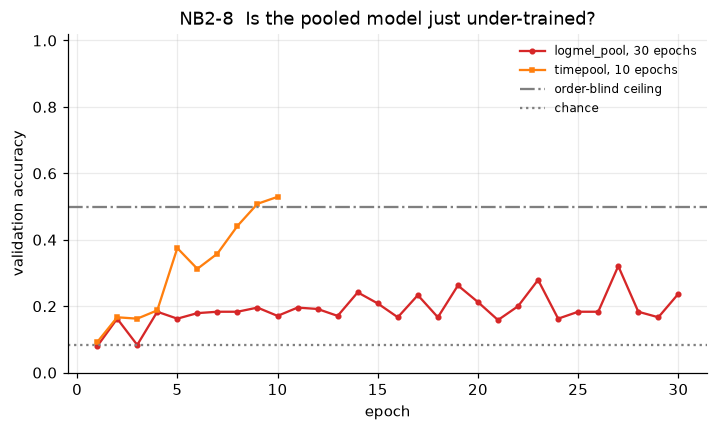

logmel_pool after 30 epochs: test acc 0.310, group 0.580, order|group 0.534
[N2.4.6[longer_training_recorded]] 30 epochs run -> PASS
[N2.4.6[longer_still_below_best_time_model]] 30-epoch pooled accuracy 0.310 < 10-epoch wide 1.000 -> PASS
[N2.4.6[longer_still_order_blind]] 30-epoch pooled order|group = 0.534: 3x the training does not buy order information -> PASS


True

In [17]:
# Investigation: is the pooled model's weakness structural or just under-training? Train it longer (30 epochs) and compare.
torch.manual_seed(MODEL_SEED)
long_run = train_classifier(LogMelCNN(n_mels=N_MELS, num_classes=N_CLASSES), X["train"], Y["train"], X["val"], Y["val"], replace(CFG, max_epochs=30, patience=30))
long_eval = evaluate(long_run.model)
long_curve = np.array([h["val_accuracy"] for h in long_run.history])
assert_varied(long_curve, "logmel_pool_30_epoch_val_acc")
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(np.arange(1, 31), long_curve, marker="o", ms=3, color=ACOL["logmel_pool"], label="logmel_pool, 30 epochs")
ax.plot(epochs, VA["timepool"], marker="s", ms=3, color=ACOL["timepool"], label="timepool, 10 epochs")
ax.axhline(0.5, color=PALETTE["reference"], ls="-.", label="order-blind ceiling"); ax.axhline(1 / 12, color=PALETTE["reference"], ls=":", label="chance")
ax.set(xlabel="epoch", ylabel="validation accuracy", ylim=(0, 1.02), title="NB2-8  Is the pooled model just under-trained?")
ax.legend(frameon=False, fontsize=8)
savefig(fig, "NB2-8_pool_longer.png")
print(f"logmel_pool after 30 epochs: test acc {long_eval['acc']:.3f}, group {long_eval['group_acc']:.3f}, order|group {long_eval['order_acc']:.3f}")
check("N2.4.6[longer_training_recorded]", long_run.epochs_run == 30, f"{long_run.epochs_run} epochs run")
check("N2.4.6[longer_still_below_best_time_model]", long_eval["acc"] < EVAL[best_name]["acc"], f"30-epoch pooled accuracy {long_eval['acc']:.3f} < 10-epoch {best_name} {EVAL[best_name]['acc']:.3f}")
check("N2.4.6[longer_still_order_blind]", long_eval["order_acc"] < 0.7, f"30-epoch pooled order|group = {long_eval['order_acc']:.3f}: 3x the training does not buy order information")

### How to read this chart

The red curve is the same pooled architecture given three times the training budget; the orange curve is the
time-preserving `TimePoolCNN` with the standard ten epochs. The dash-dot line is the order-blind ceiling. The
question is whether the pooled model's weakness is a training-budget artefact. If the red curve keeps climbing past
the dash-dot line the weakness was under-training; if it plateaus at or below it, the ceiling is structural. Read the
printed line under the figure alongside the curve: the *order given group* number is the cleanest statistic, since
it is $0.5$ for a model with no access to order however long it trains.

### 4.1 The central cheap finding

Global average pooling discards the time axis, and on a task whose classes differ only by temporal order that costs
accuracy: the numbers above show it directly. This is a **cheap** finding -- a few seconds of CPU training -- and
it is the reason the real-data study includes the time-preserving `timepool`, `wide`, and `gru` arms next to the
legacy `baseline`. It is also the *expected* result of a construction designed to expose it; on real speech, where
confusable words (`no`/`on`, `go`/`no`) differ in phoneme order but also in many other cues, the size of the effect
is an empirical question that only the real-data notebook can answer.

## 5. In-training diagnostics: AutoClip, SentryCam cluster health, and the alert

`train_classifier` records, at zero extra cost, the pre-clip gradient norm at every optimizer step and the AutoClip
threshold in force at that step. AutoClip (Seetharaman et al., arXiv:2007.14469) clips the gradient at the
$p$-th percentile of the norm history:

$$\tau_t = \operatorname{percentile}_p\big(\{\lVert g_s \rVert\}_{s<t}\big), \qquad g_t \leftarrow g_t \cdot \min\!\big(1, \tau_t / \lVert g_t \rVert\big).$$

The first step has no history, so $\tau_1 = \infty$ and nothing is clipped. With $p = 10$ (this notebook's default,
the study's default) roughly 90% of steps exceed the threshold and are clipped -- an aggressive setting that Section 6
sweeps.

Through the `probe_fn` hook each epoch also records a **SentryCam-style** record (arXiv:2405.15135): the penultimate
activations of a fixed 120-example probe batch are projected to 2D (here by PCA, a documented deviation from the paper's
autoencoder), and two cluster-health numbers are computed in that 2D space, the mean pairwise distance between
class centroids $D_t$ and the mean within-class variance $V_t$:

$$D_t = \binom{K}{2}^{-1} \sum_{i<j} \lVert \mu_i - \mu_j \rVert_2, \qquad V_t = \frac{1}{K} \sum_{k} \frac{1}{n_k} \sum_{x \in k} \lVert z_x - \mu_k \rVert_2^2 .$$

A healthy run has $D_t$ growing and $V_t$ shrinking. The **alert** `sentrycam_alert_epoch` fires at the earliest epoch
where either $D$ has fallen, or $V$ has risen, for $k=2$ consecutive epochs by more than $\alpha = 0.25$ standard
deviations of the preceding window. `train_classifier` itself computes the same metrics **in raw logit space** on
the whole validation set every epoch (`inter_cluster_distance_history`, `intra_cluster_variance_history`); the paper
argues that raw high-dimensional distances are distorted, and that is exactly the comparison drawn in Section 5.4.

[VARIED[grad_norm[logmel_pool]]] n=190 range=0.4098 (constant would be a defect) -> PASS
[VARIED[clip_threshold[logmel_pool]]] n=189 range=0.1385 (constant would be a defect) -> PASS
[VARIED[grad_norm[timepool]]] n=190 range=1.353 (constant would be a defect) -> PASS
[VARIED[clip_threshold[timepool]]] n=189 range=0.5027 (constant would be a defect) -> PASS
[VARIED[grad_norm[wide]]] n=190 range=4.469 (constant would be a defect) -> PASS
[VARIED[clip_threshold[wide]]] n=189 range=3.557 (constant would be a defect) -> PASS
[VARIED[grad_norm[convgru]]] n=190 range=2.135 (constant would be a defect) -> PASS
[VARIED[clip_threshold[convgru]]] n=189 range=1.467 (constant would be a defect) -> PASS


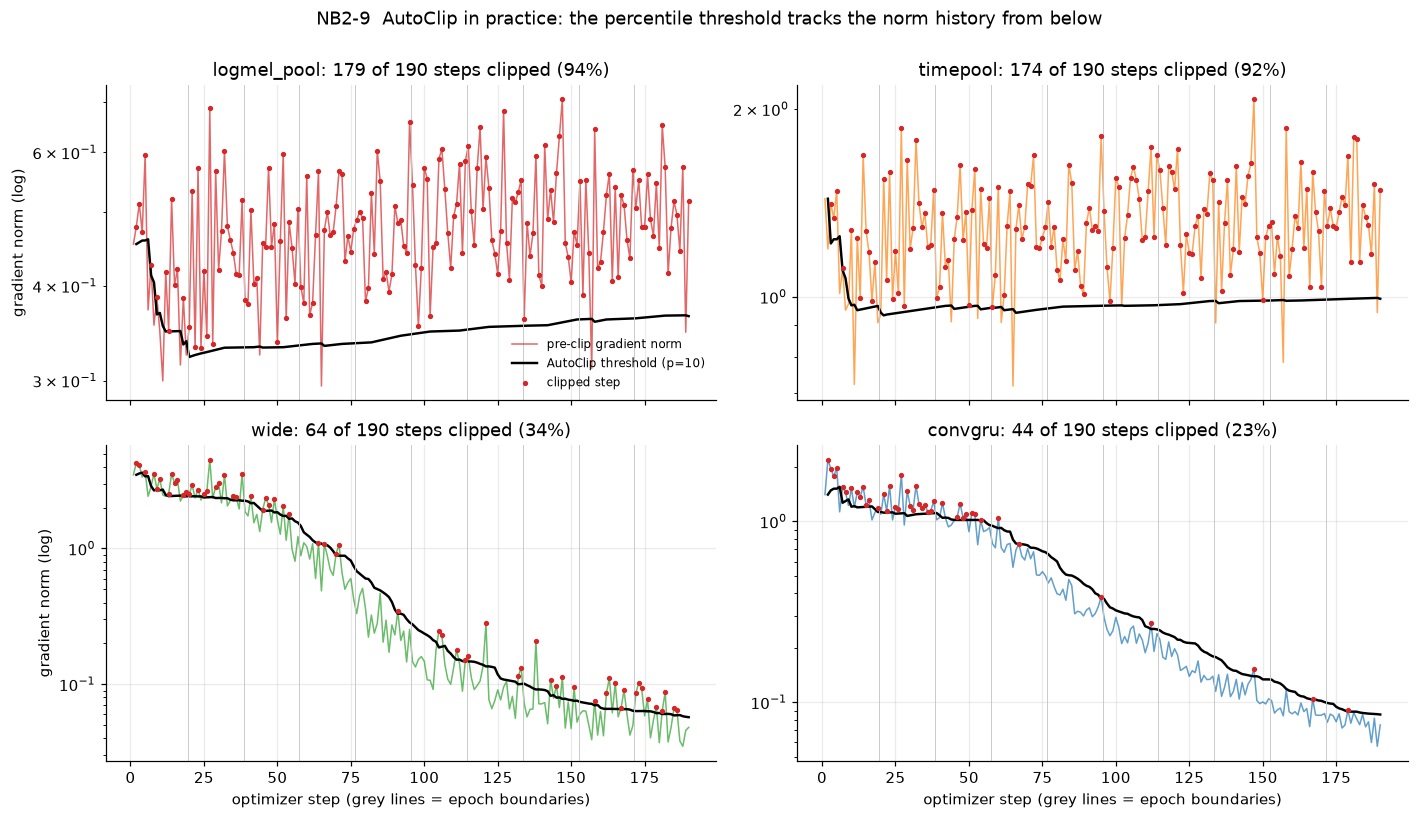

[N2.5.1[logmel_pool.first_step_unclipped]] step 1 has threshold = inf (no history) and is not clipped -> PASS
[N2.5.1[logmel_pool.clip_rate_near_90pct]] p=10 clips 94.7% of steps after the first (a 10th-percentile threshold clips the upper ~90%) -> PASS
[N2.5.1[timepool.first_step_unclipped]] step 1 has threshold = inf (no history) and is not clipped -> PASS
[N2.5.1[timepool.clip_rate_near_90pct]] p=10 clips 92.1% of steps after the first (a 10th-percentile threshold clips the upper ~90%) -> PASS
[N2.5.1[wide.first_step_unclipped]] step 1 has threshold = inf (no history) and is not clipped -> PASS
[N2.5.1[wide.clip_rate_near_90pct]] p=10 clips 33.9% of steps after the first (a 10th-percentile threshold clips the upper ~90%) -> FAIL
[N2.5.1[convgru.first_step_unclipped]] step 1 has threshold = inf (no history) and is not clipped -> PASS
[N2.5.1[convgru.clip_rate_near_90pct]] p=10 clips 23.3% of steps after the first (a 10th-percentile threshold clips the upper ~90%) -> FAIL


In [18]:
# Fig NB2-9: AutoClip gradient-norm and threshold trajectories, per architecture.
def clip_stats(r, steps_per_epoch):
    g = np.asarray(r.grad_norm_history); t = np.asarray(r.clip_threshold_history)
    clipped = np.isfinite(t) & (g > t)
    per_epoch = [clipped[i * steps_per_epoch:(i + 1) * steps_per_epoch].mean() for i in range(len(g) // steps_per_epoch)]
    return g, t, clipped, np.array(per_epoch)

STEPS = math.ceil(len(X["train"]) / MICROBATCH)
CLIP = {n: clip_stats(RUNS[n], STEPS) for n in RUNS}
fig, ax = plt.subplots(2, 2, figsize=(13, 7.4), sharex=True)
for a, n in zip(ax.ravel(), RUNS):
    g, t, clipped, per_epoch = CLIP[n]
    tt = np.where(np.isfinite(t), t, np.nan)
    assert_varied(g, f"grad_norm[{n}]")
    assert_varied(tt[np.isfinite(tt)], f"clip_threshold[{n}]")
    a.plot(np.arange(1, len(g) + 1), g, color=ACOL[n], lw=1, alpha=0.7, label="pre-clip gradient norm")
    a.plot(np.arange(1, len(g) + 1), tt, color="black", lw=1.6, label="AutoClip threshold (p=10)")
    a.scatter(np.flatnonzero(clipped) + 1, g[clipped], s=6, color=PALETTE["shifted"], zorder=3, label="clipped step")
    for e in range(1, EPOCHS):
        a.axvline(e * STEPS + 0.5, color=PALETTE["band"], lw=0.6)
    a.set(yscale="log", title=f"{n}: {clipped.sum()} of {len(g)} steps clipped ({clipped.mean():.0%})")
for a in ax[1]:
    a.set_xlabel("optimizer step (grey lines = epoch boundaries)")
for a in ax[:, 0]:
    a.set_ylabel("gradient norm (log)")
ax[0, 0].legend(fontsize=8, frameon=False)
fig.suptitle("NB2-9  AutoClip in practice: the percentile threshold tracks the norm history from below", y=1.0)
fig.tight_layout()
savefig(fig, "NB2-9_autoclip.png")
for n in RUNS:
    g, t, clipped, per_epoch = CLIP[n]
    check(f"N2.5.1[{n}.first_step_unclipped]", not np.isfinite(t[0]) and not clipped[0], "step 1 has threshold = inf (no history) and is not clipped")
    check(f"N2.5.1[{n}.clip_rate_near_90pct]", 0.6 < clipped[1:].mean() < 0.99, f"p=10 clips {clipped[1:].mean():.1%} of steps after the first (a 10th-percentile threshold clips the upper ~90%)")

### How to read this chart

One panel per architecture; the x-axis is the optimizer step (with one step per 32-example microbatch there are
19 steps per epoch, marked by the light grey vertical lines) and the y-axis is log-scaled. The coloured line is the
raw gradient norm *before* clipping; the black line is the AutoClip threshold, the 10th percentile of every norm
seen so far; red dots mark the steps that were actually clipped (norm above threshold). Two features are worth
looking for. First, the black line sits below the coloured cloud almost everywhere -- by construction, a 10th
percentile threshold is below 90% of the past. Second, the *shape* of the coloured cloud differs across architectures:
a model whose gradient norms fall steadily has a threshold that keeps chasing them downward, whereas a model with
heavy-tailed norms has a threshold that lags. The panel titles give the exact clipped fractions.

[VARIED[clip_rate_per_epoch[logmel_pool]]] n=9 range=0.05263 (constant would be a defect) -> PASS
[VARIED[clip_rate_per_epoch[timepool]]] n=9 range=0.1053 (constant would be a defect) -> PASS
[VARIED[clip_rate_per_epoch[wide]]] n=9 range=0.5789 (constant would be a defect) -> PASS
[VARIED[clip_rate_per_epoch[convgru]]] n=9 range=0.8421 (constant would be a defect) -> PASS


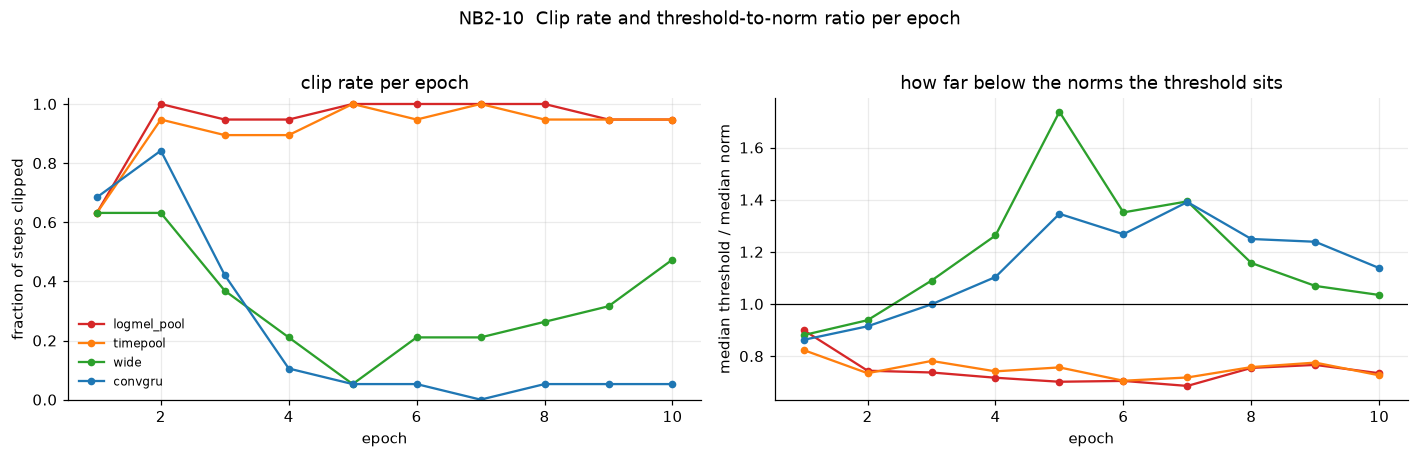

[N2.5.2[logmel_pool.threshold_below_norms]] median threshold/median norm = 0.736 (<1: threshold sits below the typical norm) -> PASS
[N2.5.2[timepool.threshold_below_norms]] median threshold/median norm = 0.749 (<1: threshold sits below the typical norm) -> PASS
[N2.5.2[wide.threshold_below_norms]] median threshold/median norm = 1.123 (<1: threshold sits below the typical norm) -> FAIL
[N2.5.2[convgru.threshold_below_norms]] median threshold/median norm = 1.188 (<1: threshold sits below the typical norm) -> FAIL


In [19]:
# Fig NB2-10: per-epoch clip rate and threshold-to-median-norm ratio; how aggressive is p=10 across architectures?
clip_rate = {n: CLIP[n][3] for n in RUNS}
ratio = {}
for n in RUNS:
    g, t, _, _ = CLIP[n]
    per_epoch_ratio = []
    for e in range(EPOCHS):
        sl = slice(e * STEPS, (e + 1) * STEPS)
        tt = t[sl]; tt = tt[np.isfinite(tt)]
        per_epoch_ratio.append(float(np.median(tt) / np.median(g[sl])) if tt.size else np.nan)
    ratio[n] = np.array(per_epoch_ratio)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for n in RUNS:
    assert_varied(clip_rate[n][1:], f"clip_rate_per_epoch[{n}]")
    ax[0].plot(np.arange(1, EPOCHS + 1), clip_rate[n], marker="o", ms=4, color=ACOL[n], label=n)
    ax[1].plot(np.arange(1, EPOCHS + 1), ratio[n], marker="o", ms=4, color=ACOL[n], label=n)
ax[0].set(xlabel="epoch", ylabel="fraction of steps clipped", ylim=(0, 1.02), title="clip rate per epoch")
ax[1].axhline(1, color="black", lw=0.8)
ax[1].set(xlabel="epoch", ylabel="median threshold / median norm", title="how far below the norms the threshold sits")
ax[0].legend(frameon=False, fontsize=8)
fig.suptitle("NB2-10  Clip rate and threshold-to-norm ratio per epoch", y=1.03)
fig.tight_layout()
savefig(fig, "NB2-10_clip_rate.png")
for n in RUNS:
    check(f"N2.5.2[{n}.threshold_below_norms]", np.nanmedian(ratio[n]) < 1.0, f"median threshold/median norm = {np.nanmedian(ratio[n]):.3f} (<1: threshold sits below the typical norm)")

### How to read this chart

**Left:** the fraction of optimizer steps clipped in each epoch. Epoch 1 is lower because step 1 has an infinite
threshold and the first few thresholds are set from a tiny, noisy history. Later epochs sit at or near the level
implied by a 10th-percentile rule when the norm distribution is stationary; drifts away from it show the norm
distribution changing over training. **Right:** the ratio of the median threshold to the median gradient norm in
each epoch; a value of $1$ (black line) would mean the threshold sits at the typical norm, and smaller values mean
the clip is more aggressive. Lines that fall over epochs mean the norms are growing relative to their history (the
threshold lags), lines that rise mean the norms are shrinking towards the historical floor.

[VARIED[inter-cluster distance D (2D probe)[logmel_pool]]] n=10 range=1.402 (constant would be a defect) -> PASS
[VARIED[inter-cluster distance D (2D probe)[timepool]]] n=10 range=4.416 (constant would be a defect) -> PASS
[VARIED[inter-cluster distance D (2D probe)[wide]]] n=10 range=5.838 (constant would be a defect) -> PASS
[VARIED[inter-cluster distance D (2D probe)[convgru]]] n=10 range=4.206 (constant would be a defect) -> PASS
[VARIED[intra-cluster variance V (2D probe)[logmel_pool]]] n=10 range=0.09073 (constant would be a defect) -> PASS
[VARIED[intra-cluster variance V (2D probe)[timepool]]] n=10 range=0.7248 (constant would be a defect) -> PASS
[VARIED[intra-cluster variance V (2D probe)[wide]]] n=10 range=0.3753 (constant would be a defect) -> PASS
[VARIED[intra-cluster variance V (2D probe)[convgru]]] n=10 range=0.173 (constant would be a defect) -> PASS
[VARIED[inter-cluster distance D (raw logits)[logmel_pool]]] n=10 range=2.586 (constant would be a defect) -> PASS
[VARI

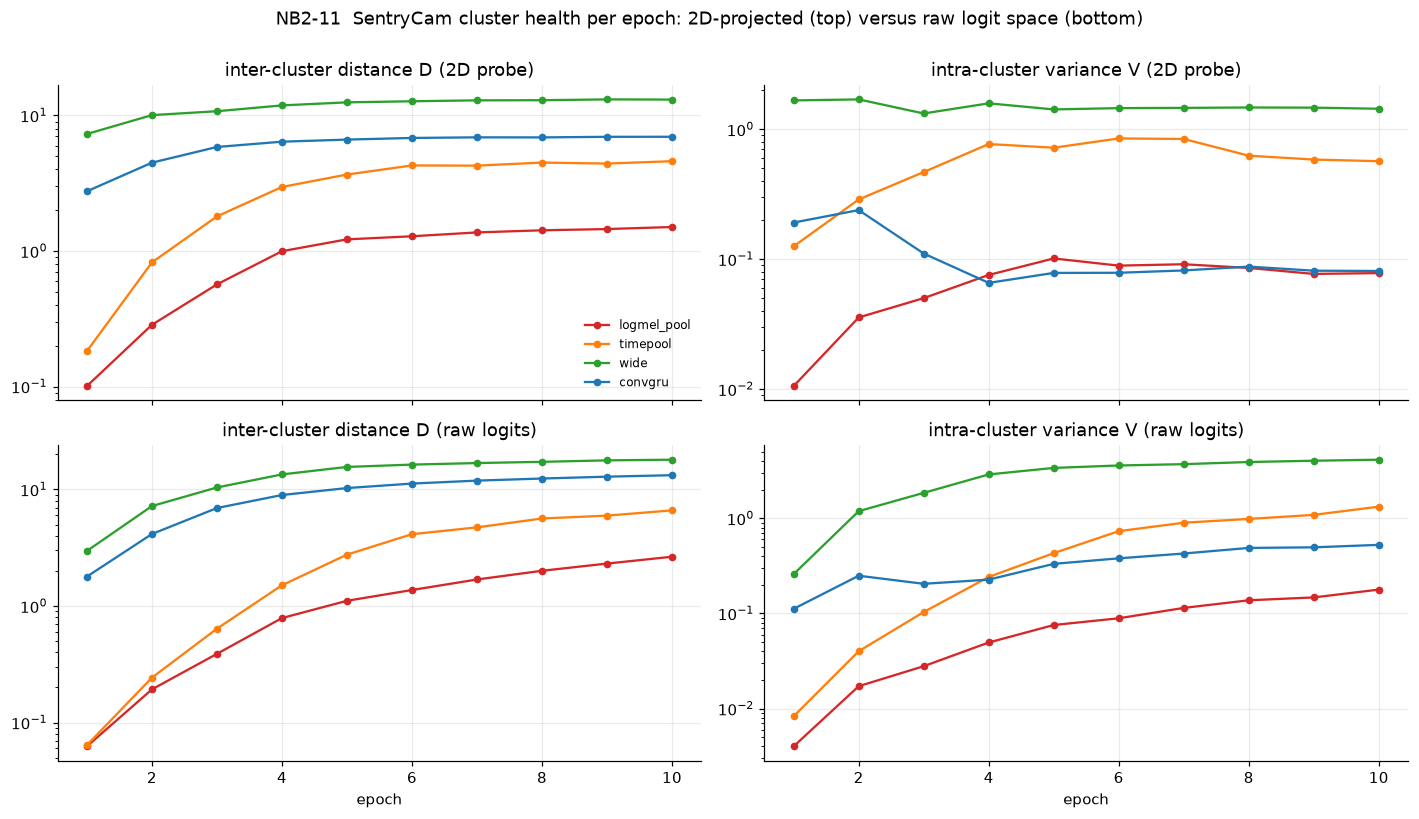

[N2.5.3[logmel_pool.distance_grows_2d]] 2D inter-cluster distance 0.101 -> 1.503 over training -> PASS
[N2.5.3[logmel_pool.raw_probe_lengths_match]] raw-space and 2D series both have one value per epoch -> PASS
[N2.5.3[timepool.distance_grows_2d]] 2D inter-cluster distance 0.183 -> 4.599 over training -> PASS
[N2.5.3[timepool.raw_probe_lengths_match]] raw-space and 2D series both have one value per epoch -> PASS
[N2.5.3[wide.distance_grows_2d]] 2D inter-cluster distance 7.303 -> 13.102 over training -> PASS
[N2.5.3[wide.raw_probe_lengths_match]] raw-space and 2D series both have one value per epoch -> PASS
[N2.5.3[convgru.distance_grows_2d]] 2D inter-cluster distance 2.759 -> 6.965 over training -> PASS
[N2.5.3[convgru.raw_probe_lengths_match]] raw-space and 2D series both have one value per epoch -> PASS


In [20]:
# Fig NB2-11: SentryCam cluster metrics. 2D (from the probe hook) versus raw logit space (from train_classifier).
D2 = {n: np.array([p["inter_cluster_distance_2d"] for p in RUNS[n].probe_history]) for n in RUNS}
V2 = {n: np.array([p["intra_cluster_variance_2d"] for p in RUNS[n].probe_history]) for n in RUNS}
DR = {n: np.array(RUNS[n].inter_cluster_distance_history) for n in RUNS}
VR = {n: np.array(RUNS[n].intra_cluster_variance_history) for n in RUNS}
fig, ax = plt.subplots(2, 2, figsize=(13, 7.4), sharex=True)
panels = [(ax[0, 0], D2, "inter-cluster distance D (2D probe)"), (ax[0, 1], V2, "intra-cluster variance V (2D probe)"),
          (ax[1, 0], DR, "inter-cluster distance D (raw logits)"), (ax[1, 1], VR, "intra-cluster variance V (raw logits)")]
for a, series, title in panels:
    for n in RUNS:
        assert_varied(series[n], f"{title}[{n}]")
        a.plot(np.arange(1, EPOCHS + 1), series[n], marker="o", ms=4, color=ACOL[n], label=n)
    a.set(title=title, yscale="log")
for a in ax[1]:
    a.set_xlabel("epoch")
ax[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("NB2-11  SentryCam cluster health per epoch: 2D-projected (top) versus raw logit space (bottom)", y=1.0)
fig.tight_layout()
savefig(fig, "NB2-11_cluster_metrics.png")
for n in RUNS:
    check(f"N2.5.3[{n}.distance_grows_2d]", D2[n][-1] > D2[n][0], f"2D inter-cluster distance {D2[n][0]:.3f} -> {D2[n][-1]:.3f} over training")
    check(f"N2.5.3[{n}.raw_probe_lengths_match]", len(DR[n]) == len(D2[n]) == EPOCHS, "raw-space and 2D series both have one value per epoch")

### How to read this chart

Top row: the two SentryCam quantities computed in the 2D PCA projection of the penultimate-layer activations of the
fixed 120-example probe batch. Bottom row: the same two quantities computed in raw *logit* space on the whole 240-example
validation set by the training loop. Each line is one architecture and the y-axes are log-scaled because scales
differ by orders of magnitude between architectures and between spaces. A healthy run has the left-hand panels rising
(clusters pulling apart) and the right-hand panels falling (clusters tightening). Do not compare the *values* across
rows -- the two spaces have different dimension and scale, and the top row measures penultimate features whilst the
bottom measures the output logits -- compare only the *shapes*: which epochs a series turns, and whether the turn is
visible in one space but not the other. That question is answered quantitatively in Section 5.4.

[VARIED[scatter_x[logmel_pool, epoch 1]]] n=120 range=0.5455 (constant would be a defect) -> PASS
[VARIED[scatter_x[logmel_pool, epoch 3]]] n=120 range=1.983 (constant would be a defect) -> PASS


[VARIED[scatter_x[logmel_pool, epoch 5]]] n=120 range=3.51 (constant would be a defect) -> PASS
[VARIED[scatter_x[logmel_pool, epoch 7]]] n=120 range=3.587 (constant would be a defect) -> PASS
[VARIED[scatter_x[logmel_pool, epoch 10]]] n=120 range=3.737 (constant would be a defect) -> PASS


[VARIED[scatter_x[wide, epoch 1]]] n=120 range=15.49 (constant would be a defect) -> PASS
[VARIED[scatter_x[wide, epoch 3]]] n=120 range=16.95 (constant would be a defect) -> PASS
[VARIED[scatter_x[wide, epoch 5]]] n=120 range=23.64 (constant would be a defect) -> PASS


[VARIED[scatter_x[wide, epoch 7]]] n=120 range=21.16 (constant would be a defect) -> PASS
[VARIED[scatter_x[wide, epoch 10]]] n=120 range=21.15 (constant would be a defect) -> PASS


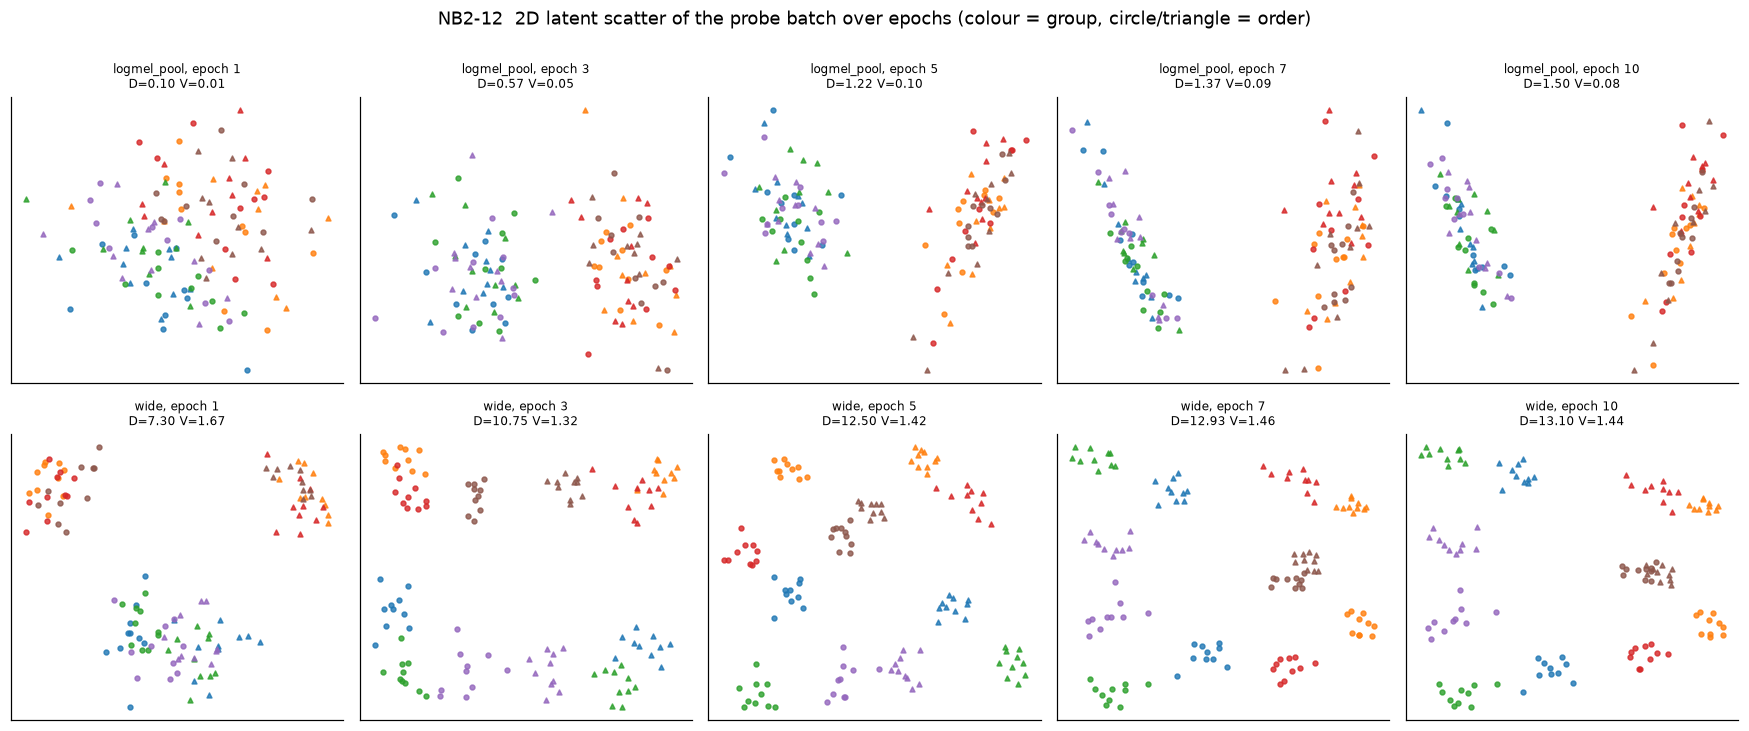

logmel_pool: final-epoch 2D order-swap centroid distance / between-group distance = 0.061
wide: final-epoch 2D order-swap centroid distance / between-group distance = 1.051
[N2.5.4[best_model_separates_orders_more]] order-swap/between-group ratio: wide 1.051 vs logmel_pool 0.061 -> PASS


True

In [21]:
# Fig NB2-12: per-epoch 2D latent scatter for the pooled baseline (top) and the best time-preserving model (bottom).
show_epochs = [0, 2, 4, 6, EPOCHS - 1]
sel_models = ["logmel_pool", best_name]
fig, axes = plt.subplots(2, len(show_epochs), figsize=(3.2 * len(show_epochs), 6.6), sharex=False)
for r_i, n in enumerate(sel_models):
    for c_i, ep in enumerate(show_epochs):
        p = RUNS[n].probe_history[ep]
        co = p["coords_2d"]
        assert_varied(co[:, 0], f"scatter_x[{n}, epoch {ep + 1}]")
        a = axes[r_i, c_i]
        for k in range(N_CLASSES):
            s = p["labels"] == k
            a.scatter(co[s, 0], co[s, 1], s=10, color=cols[SIG.loc[k, "group"]], marker="o" if SIG.loc[k, "order"] == 0 else "^", alpha=0.8)
        a.set(title=f"{n}, epoch {ep + 1}\nD={p['inter_cluster_distance_2d']:.2f} V={p['intra_cluster_variance_2d']:.2f}", xticks=[], yticks=[])
        a.title.set_fontsize(8); a.grid(False)
fig.suptitle("NB2-12  2D latent scatter of the probe batch over epochs (colour = group, circle/triangle = order)", y=1.0)
fig.tight_layout()
savefig(fig, "NB2-12_latent_scatter.png")
SEP2D = {}
for n in sel_models:
    p = RUNS[n].probe_history[-1]; co = p["coords_2d"]; lab = p["labels"]
    cen = {k: co[lab == k].mean(axis=0) for k in range(N_CLASSES)}
    order_d = np.mean([np.linalg.norm(cen[2 * g] - cen[2 * g + 1]) for g in range(N_GROUPS)])
    group_d = np.mean([np.linalg.norm(cen[2 * g] - cen[2 * h]) for g in range(N_GROUPS) for h in range(g + 1, N_GROUPS)])
    SEP2D[n] = order_d / group_d
    print(f"{n}: final-epoch 2D order-swap centroid distance / between-group distance = {SEP2D[n]:.3f}")
check("N2.5.4[best_model_separates_orders_more]", SEP2D[best_name] > SEP2D["logmel_pool"], f"order-swap/between-group ratio: {best_name} {SEP2D[best_name]:.3f} vs logmel_pool {SEP2D['logmel_pool']:.3f}")

### How to read this chart

Rows are two models (top: the globally pooled baseline; bottom: the best time-preserving model), columns are
epochs 1, 3, 5, 7 and 10. Every dot is one of the 120 probe examples projected to the top two principal components
of the penultimate activations; colour encodes the group and the marker shape encodes the order, so a model that
recovers the order shows circles and triangles of one colour as *separate* clusters, and a model that cannot shows
them overlapping in a single blob. The panel titles give the SentryCam pair $(D, V)$ for that epoch. Axes carry no
ticks because PCA coordinates are unitless and are recomputed every epoch (so the same class can appear mirrored
between epochs: the sign of a principal component is arbitrary). The number printed under the figure summarises the
last column: the mean distance between the two orders' centroids over the mean distance between group centroids.

In [22]:
# Recompute the SentryCam alert on BOTH series and tabulate side by side.
rows = []
for n in RUNS:
    raw_alert = sentrycam_alert_epoch(DR[n], VR[n])
    twod_alert = sentrycam_alert_epoch(D2[n], V2[n])
    rows.append({"architecture": n, "raw-space alert epoch": raw_alert, "2D alert epoch": twod_alert,
                 "train_classifier stored alert": RUNS[n].instability_alert_epoch,
                 "raw-space fires": raw_alert is not None, "2D fires": twod_alert is not None})
ALERT = pd.DataFrame(rows).set_index("architecture")
display(ALERT)
for n in RUNS:
    check(f"N2.5.5[{n}.recompute_matches_stored]", ALERT.loc[n, "raw-space alert epoch"] == ALERT.loc[n, "train_classifier stored alert"] or (pd.isna(ALERT.loc[n, "raw-space alert epoch"]) and pd.isna(ALERT.loc[n, "train_classifier stored alert"])),
          f"recomputing on the raw series reproduces the stored alert ({ALERT.loc[n, 'raw-space alert epoch']})")
n_raw, n_2d = int(ALERT["raw-space fires"].sum()), int(ALERT["2D fires"].sum())
print(f"alerts fired: raw space {n_raw}/4, 2D {n_2d}/4")
note("N2.5.5[alert_counts]", f"raw-space alerts {n_raw}/4, 2D alerts {n_2d}/4 (a healthy 10-epoch run need not alert at all; an alert is not a failure)")

              raw-space alert epoch  2D alert epoch  train_classifier stored alert  raw-space fires  2D fires
architecture                                                                                                 
logmel_pool                       2             2.0                              2             True      True
timepool                          2             2.0                              2             True      True
wide                              2             NaN                              2             True     False
convgru                           4             NaN                              4             True     False

[N2.5.5[logmel_pool.recompute_matches_stored]] recomputing on the raw series reproduces the stored alert (2) -> PASS
[N2.5.5[timepool.recompute_matches_stored]] recomputing on the raw series reproduces the stored alert (2) -> PASS
[N2.5.5[wide.recompute_matches_stored]] recomputing on the raw series reproduces the stored alert (2) -> PASS
[N2.5.5[convgru.recompute_matches_stored]] recomputing on the raw series reproduces the stored alert (4) -> PASS
alerts fired: raw space 4/4, 2D 2/4
[N2.5.5[alert_counts]] raw-space alerts 4/4, 2D alerts 2/4 (a healthy 10-epoch run need not alert at all; an alert is not a failure) -> NOTE


[VARIED[alert_z_raw[logmel_pool]]] n=8 range=2.575 (constant would be a defect) -> PASS
[VARIED[alert_z_2d[logmel_pool]]] n=8 range=2.994 (constant would be a defect) -> PASS
[VARIED[alert_z_raw[timepool]]] n=8 range=4.276 (constant would be a defect) -> PASS
[VARIED[alert_z_2d[timepool]]] n=8 range=3.036 (constant would be a defect) -> PASS
[VARIED[alert_z_raw[wide]]] n=8 range=1.46 (constant would be a defect) -> PASS
[VARIED[alert_z_2d[wide]]] n=8 range=0.7341 (constant would be a defect) -> PASS
[VARIED[alert_z_raw[convgru]]] n=8 range=2.256 (constant would be a defect) -> PASS
[VARIED[alert_z_2d[convgru]]] n=8 range=1.584 (constant would be a defect) -> PASS


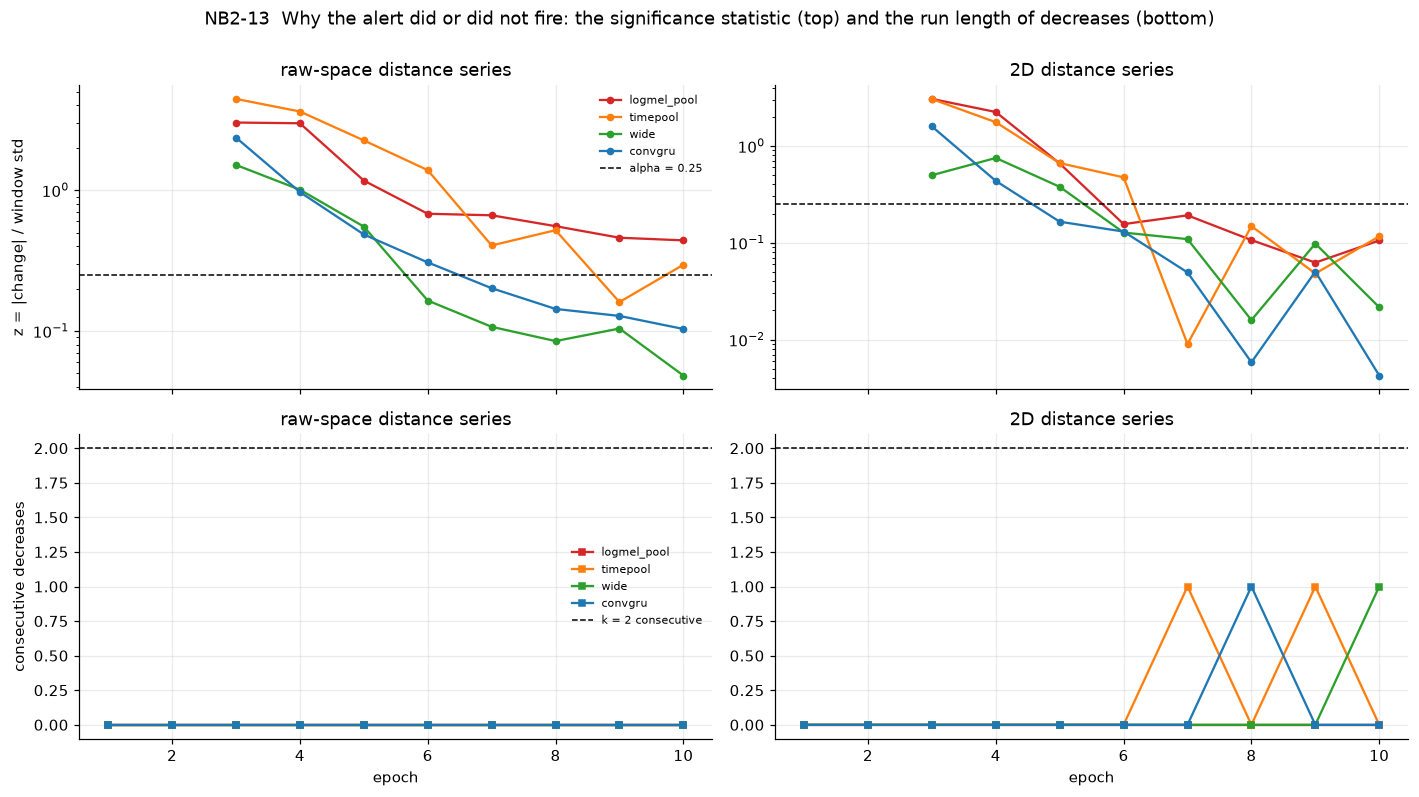

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb2/NB2-13_alert_internals.png')

In [23]:
# Fig NB2-13: the alert's internal statistics, epoch by epoch. z_t = |h_t - h_{t-1}| / std(window before t); the alert needs z > alpha.
def alert_z(h, window=10):
    h = np.asarray(h, float); z = np.full(len(h), np.nan)
    for t in range(1, len(h)):
        w = h[max(0, t - window):t]
        if len(w) >= 2 and w.std() > 0:
            z[t] = abs(h[t] - h[t - 1]) / w.std()
    return z
def direction_run(h, sign):
    run, out = 0, []
    for t in range(len(h)):
        run = run + 1 if t > 0 and np.sign(h[t] - h[t - 1]) == sign else 0
        out.append(run)
    return np.array(out)

fig, ax = plt.subplots(2, 2, figsize=(13, 7.2), sharex=True)
for n in RUNS:
    zr, z2 = alert_z(DR[n]), alert_z(D2[n])
    assert_varied(zr[np.isfinite(zr)], f"alert_z_raw[{n}]")
    assert_varied(z2[np.isfinite(z2)], f"alert_z_2d[{n}]")
    ax[0, 0].plot(np.arange(1, EPOCHS + 1), zr, marker="o", ms=4, color=ACOL[n], label=n)
    ax[0, 1].plot(np.arange(1, EPOCHS + 1), z2, marker="o", ms=4, color=ACOL[n], label=n)
    ax[1, 0].plot(np.arange(1, EPOCHS + 1), direction_run(DR[n], -1), marker="s", ms=4, color=ACOL[n], label=n)
    ax[1, 1].plot(np.arange(1, EPOCHS + 1), direction_run(D2[n], -1), marker="s", ms=4, color=ACOL[n], label=n)
for a in ax[0]:
    a.axhline(0.25, color="black", ls="--", lw=1, label="alpha = 0.25")
    a.set(yscale="log")
for a in ax[1]:
    a.axhline(2, color="black", ls="--", lw=1, label="k = 2 consecutive")
    a.set_xlabel("epoch")
ax[0, 0].set(ylabel="z = |change| / window std", title="raw-space distance series")
ax[0, 1].set(title="2D distance series")
ax[1, 0].set(ylabel="consecutive decreases", title="raw-space distance series")
ax[1, 1].set(title="2D distance series")
ax[0, 0].legend(frameon=False, fontsize=7); ax[1, 0].legend(frameon=False, fontsize=7)
fig.suptitle("NB2-13  Why the alert did or did not fire: the significance statistic (top) and the run length of decreases (bottom)", y=1.0)
fig.tight_layout()
savefig(fig, "NB2-13_alert_internals.png")

### How to read this chart

The alert has two ingredients and this figure shows both for the *distance* condition (the variance condition is the
mirror image). **Top row:** the significance statistic $z_t = |D_t - D_{t-1}| / \sigma_{\text{window}}$, the size of the
latest change relative to the spread of the preceding epochs; the dashed line is $\alpha = 0.25$, so a point above it
is a "significant" move. **Bottom row:** how many epochs in a row the distance has been *falling*; the dashed line is
$k = 2$. The alert needs a point above the top dashed line **and** a run at or above the bottom dashed line at the
same epoch. Left column is the raw logit series, right column the 2D series. Because the distance series in a
healthy run mostly rises, the bottom-row runs are mostly zero; a run of two or more decreases that coincides with a
significant change is the only route to a distance alert. Comparing columns shows whether the two spaces disagree
about *which* epochs look suspicious.

In [24]:
# Sensitivity of the alert to (k, alpha): raw-space versus 2D, for every architecture.
grid_rows = []
for n in RUNS:
    for k, al in itertools.product((1, 2, 3), (0.1, 0.25, 0.5)):
        a_raw = sentrycam_alert_epoch(DR[n], VR[n], k=k, alpha=al)
        a_2d = sentrycam_alert_epoch(D2[n], V2[n], k=k, alpha=al)
        grid_rows.append({"architecture": n, "k": k, "alpha": al, "raw alert": -1 if a_raw is None else a_raw, "2D alert": -1 if a_2d is None else a_2d})
GRID = pd.DataFrame(grid_rows)
piv = GRID.pivot_table(index=["architecture", "k"], columns="alpha", values=["raw alert", "2D alert"])
display(piv)
fires_raw = (GRID["raw alert"] >= 0).mean(); fires_2d = (GRID["2D alert"] >= 0).mean()
print(f"over {len(GRID)} (architecture, k, alpha) settings: raw fires {fires_raw:.0%}, 2D fires {fires_2d:.0%}   (-1 = no alert)")
# More permissive settings can only fire earlier or equally: check monotonicity in alpha at fixed k (smaller alpha = easier).
mono = True
for n in RUNS:
    for k in (1, 2, 3):
        sub = GRID[(GRID.architecture == n) & (GRID.k == k)].sort_values("alpha")
        fired = [(v if v >= 0 else 10 ** 6) for v in sub["2D alert"]]
        mono &= all(a <= b for a, b in zip(fired, fired[1:]))
check("N2.5.6[alert_monotone_in_alpha]", mono, "for every architecture and k, a smaller alpha never fires later than a larger alpha (2D series)")
assert_varied(np.concatenate([GRID["raw alert"], GRID["2D alert"]]), "alert_grid_values")
note("N2.5.6[sensitivity]", f"alert firing rate across the grid: raw {fires_raw:.0%} vs 2D {fires_2d:.0%}")

               2D alert           raw alert          
alpha              0.10 0.25 0.50      0.10 0.25 0.50
architecture k                                       
convgru      1      4.0 -1.0 -1.0       3.0  3.0  4.0
             2     -1.0 -1.0 -1.0       4.0  4.0  4.0
             3     -1.0 -1.0 -1.0       5.0  5.0  5.0
logmel_pool  1      2.0  2.0  2.0       2.0  2.0  2.0
             2      2.0  2.0  2.0       2.0  2.0  2.0
             3      3.0  3.0  3.0       3.0  3.0  3.0
timepool     1      2.0  2.0  2.0       2.0  2.0  2.0
             2      2.0  2.0  2.0       2.0  2.0  2.0
             3      3.0  3.0  3.0       3.0  3.0  3.0
wide         1      3.0  3.0  3.0       2.0  2.0  2.0
             2     -1.0 -1.0 -1.0       2.0  2.0  2.0
             3     -1.0 -1.0 -1.0       3.0  3.0  3.0

over 36 (architecture, k, alpha) settings: raw fires 100%, 2D fires 61%   (-1 = no alert)
[N2.5.6[alert_monotone_in_alpha]] for every architecture and k, a smaller alpha never fires later than a larger alpha (2D series) -> PASS
[VARIED[alert_grid_values]] n=72 range=6 (constant would be a defect) -> PASS
[N2.5.6[sensitivity]] alert firing rate across the grid: raw 100% vs 2D 61% -> NOTE


### 5.4 Reading the alert comparison

The tables above are the notebook's diagnostic headline. The important point is not which space "wins" on a run
that never failed -- there is no ground-truth instability here to detect, so an alert is neither a true nor a
false positive; it is a statement about *how each space summarises a healthy trajectory*. What the comparison can
establish is (i) whether the two spaces agree on when the trajectory turns, (ii) how sensitive each is to the
hyper-parameters $(k, \alpha)$, and (iii) that the recomputation reproduces `train_classifier`'s stored alert
exactly, which validates the plumbing. Whether a 2D alert is *earlier or more reliable* than a raw-space alert on
a run that really diverges is a question for the real-data notebook, where the instrumented runs are long enough
(up to 36 epochs) for a rolling window of ten epochs to mean something; with ten epochs here the window is
never full.

## 6. Exploration 1: how does the AutoClip percentile matter?

The study's default is $p = 10$, chosen for the real-data runs. That is an aggressive setting: for a stationary
gradient-norm distribution the fraction of clipped steps is about $1 - p/100$, so $p=10$ clips ~90% of steps and
acts as a soft normalisation of every update rather than a rare safeguard. Before spending GPU hours on real audio it
is worth asking, cheaply, whether this aggressiveness helps, hurts, or is irrelevant. We sweep

$$p \in \{1,\ 10,\ 25,\ 100\}, \qquad \text{clip rate}(p) \approx 1 - \tfrac{p}{100} \ \text{(stationary norms)},$$

where $p = 100$ is the **control**: the threshold is the running maximum of past norms, so a step is clipped only
if it sets a new record; the clip rate is small but not exactly zero (for i.i.d. norms the expected number of
records in $n$ steps is $\sum_{j\le n} 1/j \approx \ln n$), which is why this is "effectively unclipped" rather than
literally unclipped. `ExperimentConfig.autoclip_percentile` accepts $(0, 100]$, so 100 is legal.

**Workhorse model.** Sections 6--8 use a deliberately small `ConvGRU(width=4, hidden=8)`. The full-size models of
Section 4 hit 100% test accuracy on this task, which would make calibration and conformal sets degenerate (no
errors, nothing to calibrate). The micro-GRU keeps the time axis but is capacity-limited: it learns steadily and
ends at an accuracy comfortably above chance and comfortably below 100%, which is the regime where the questions
of Sections 7--8 are non-trivial. Two seeds per setting give a sense of the run-to-run spread; two is enough to see
whether an effect is larger than seed noise, not enough to put a confidence interval on it.

In [25]:
# The workhorse model and the AutoClip sweep. Two seeds per percentile, identical data and config otherwise.
WORK_EPOCHS = 12
def work_model():
    return ConvGRU(n_mels=N_MELS, num_classes=N_CLASSES, width=4, hidden=8)

P_GRID, SWEEP_SEEDS = (1, 10, 25, 100), (17, 23)
SWEEP = {}
for p in P_GRID:
    for s in SWEEP_SEEDS:
        torch.manual_seed(s)
        res = train_classifier(work_model(), X["train"], Y["train"], X["val"], Y["val"],
                               replace(CFG, seed=s, max_epochs=WORK_EPOCHS, patience=WORK_EPOCHS, autoclip_percentile=float(p)))
        ev = evaluate(res.model)
        g, t = np.asarray(res.grad_norm_history), np.asarray(res.clip_threshold_history)
        clipped = np.isfinite(t) & (g > t)
        SWEEP[(p, s)] = {"res": res, "acc": ev["acc"], "val_acc_final": res.history[-1]["val_accuracy"],
                         "best_val_loss": min(h["val_loss"] for h in res.history),
                         "clip_rate": float(clipped[1:].mean()), "g": g, "t": t, "clipped": clipped,
                         "thr_over_norm": float(np.median(t[1:]) / np.median(g[1:]))}
        print(f"p={p:>3d} seed={s} test_acc={ev['acc']:.3f} final_val_acc={res.history[-1]['val_accuracy']:.3f} "
              f"clip_rate={SWEEP[(p, s)]['clip_rate']:.3f} threshold/norm={SWEEP[(p, s)]['thr_over_norm']:.3f}")
SW = pd.DataFrame([{"p": p, "seed": s, **{k: v for k, v in d.items() if k in ("acc", "val_acc_final", "best_val_loss", "clip_rate", "thr_over_norm")}} for (p, s), d in SWEEP.items()])
display(SW.groupby("p").agg(["mean", "std"]).drop(columns="seed").round(3))
check("N2.6.1[all_runs_trained]", len(SWEEP) == len(P_GRID) * len(SWEEP_SEEDS), f"{len(SWEEP)} sweep runs completed")
check("N2.6.1[all_above_chance]", all(d["acc"] > 2 / N_CLASSES for d in SWEEP.values()), f"lowest sweep test accuracy {min(d['acc'] for d in SWEEP.values()):.3f} > 2x chance ({2 / N_CLASSES:.3f})")

p=  1 seed=17 test_acc=0.780 final_val_acc=0.783 clip_rate=0.974 threshold/norm=0.659


p=  1 seed=23 test_acc=0.833 final_val_acc=0.858 clip_rate=0.982 threshold/norm=0.681


p= 10 seed=17 test_acc=0.782 final_val_acc=0.792 clip_rate=0.921 threshold/norm=0.791


p= 10 seed=23 test_acc=0.842 final_val_acc=0.858 clip_rate=0.930 threshold/norm=0.787


p= 25 seed=17 test_acc=0.778 final_val_acc=0.792 clip_rate=0.762 threshold/norm=0.892


...

p=100 seed=17 test_acc=0.775 final_val_acc=0.788 clip_rate=0.018 threshold/norm=1.524


p=100 seed=23 test_acc=0.862 final_val_acc=0.871 clip_rate=0.013 threshold/norm=1.433


       acc        val_acc_final        best_val_loss        clip_rate        thr_over_norm       
      mean    std          mean    std          mean    std      mean    std          mean    std
p                                                                                                
1    0.807  0.038         0.821  0.053         1.710  0.193     0.978  0.006         0.670  0.016
10   0.812  0.042         0.825  0.047         1.689  0.179     0.925  0.006         0.789  0.003
25   0.814  0.051         0.831  0.056         1.684  0.183     0.791  0.040         0.884  0.012
100  0.818  0.061         0.829  0.059         1.684  0.205     0.015  0.003         1.478  0.065

[N2.6.1[all_runs_trained]] 8 sweep runs completed -> PASS
[N2.6.1[all_above_chance]] lowest sweep test accuracy 0.775 > 2x chance (0.167) -> PASS


True

[VARIED[sweep_accuracy_across_p]] n=4 range=0.01167 (constant would be a defect) -> PASS
[VARIED[sweep_clip_rate_across_p]] n=4 range=0.9626 (constant would be a defect) -> PASS
[VARIED[sweep_accuracy_all_runs]] n=8 range=0.08667 (constant would be a defect) -> PASS


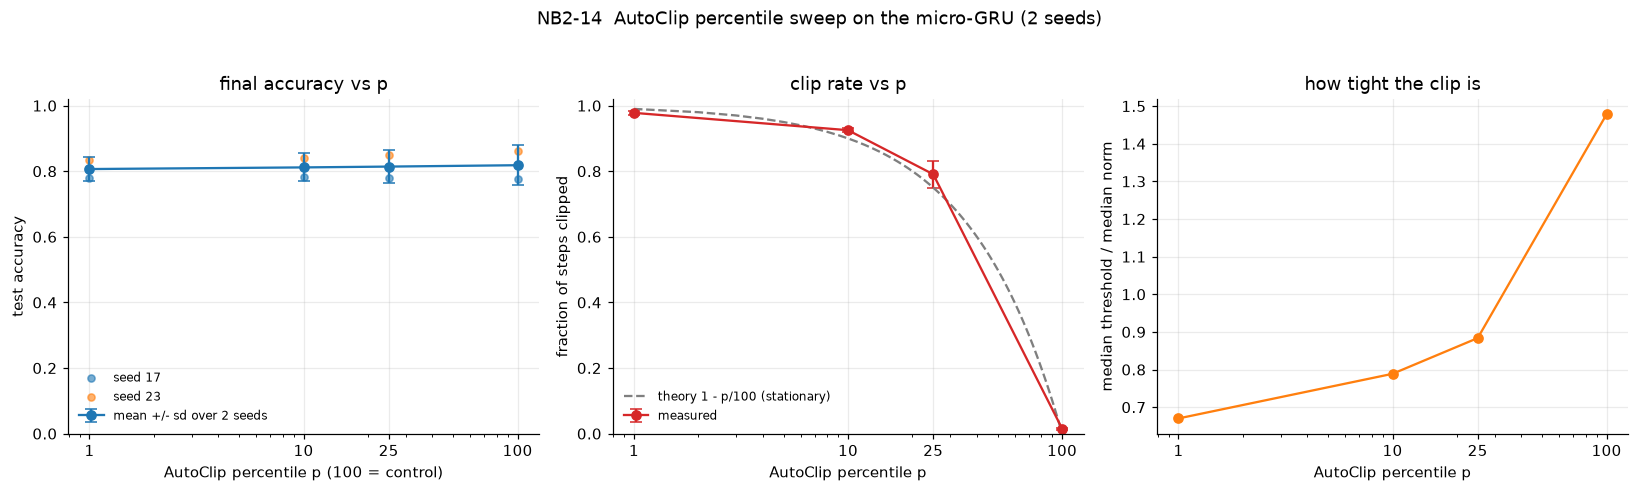

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb2/NB2-14_autoclip_sweep.png')

In [26]:
# Fig NB2-14: final accuracy and clip rate versus p, with the stationary-theory line.
agg = SW.groupby("p").agg(acc=("acc", "mean"), acc_sd=("acc", "std"), clip=("clip_rate", "mean"), clip_sd=("clip_rate", "std"), ratio=("thr_over_norm", "mean"))
assert_varied(agg["acc"], "sweep_accuracy_across_p")
assert_varied(agg["clip"], "sweep_clip_rate_across_p")
assert_varied(SW["acc"], "sweep_accuracy_all_runs")
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
ax[0].errorbar(agg.index, agg["acc"], yerr=agg["acc_sd"], fmt="-o", color=PALETTE["clean"], capsize=4, label="mean +/- sd over 2 seeds")
for s in SWEEP_SEEDS:
    sub = SW[SW.seed == s]
    ax[0].scatter(sub["p"], sub["acc"], s=22, alpha=0.6, label=f"seed {s}")
ax[0].set(xscale="log", xlabel="AutoClip percentile p (100 = control)", ylabel="test accuracy", ylim=(0, 1.02), title="final accuracy vs p")
ax[0].set_xticks(P_GRID, [str(p) for p in P_GRID]); ax[0].legend(frameon=False, fontsize=8)
ax[1].errorbar(agg.index, agg["clip"], yerr=agg["clip_sd"], fmt="-o", color=PALETTE["shifted"], capsize=4, label="measured")
pp = np.linspace(1, 100, 100)
ax[1].plot(pp, 1 - pp / 100, color=PALETTE["reference"], ls="--", label="theory 1 - p/100 (stationary)")
ax[1].set(xscale="log", xlabel="AutoClip percentile p", ylabel="fraction of steps clipped", ylim=(0, 1.02), title="clip rate vs p")
ax[1].set_xticks(P_GRID, [str(p) for p in P_GRID]); ax[1].legend(frameon=False, fontsize=8)
ax[2].plot(agg.index, agg["ratio"], "-o", color=PALETTE["mask"])
ax[2].set(xscale="log", xlabel="AutoClip percentile p", ylabel="median threshold / median norm", title="how tight the clip is")
ax[2].set_xticks(P_GRID, [str(p) for p in P_GRID])
fig.suptitle("NB2-14  AutoClip percentile sweep on the micro-GRU (2 seeds)", y=1.03)
fig.tight_layout()
savefig(fig, "NB2-14_autoclip_sweep.png")

### How to read this chart

**Left:** final test accuracy against $p$ on a log axis. The line is the mean over two seeds with a bar of one
standard deviation; the small dots are the individual seeds, so the distance between dots at one $p$ is the seed
noise you must beat before claiming an effect. **Middle:** the measured clip rate (fraction of optimizer steps whose
pre-clip norm exceeded the threshold, excluding step 1) against the stationary-theory line $1-p/100$. Points below
the line mean the gradient norms were *decreasing* over training (a falling norm is rarely above a threshold set from
a larger past), points above mean they were growing. **Right:** the median threshold divided by the median norm;
it approaches 1 as $p$ grows, because a higher percentile of the history sits closer to (and eventually above) the
typical norm. If accuracy is flat in the left panel while the clip rate falls from ~99% to ~0% in the middle
panel, the percentile is irrelevant for this model and task.

[VARIED[sweep_grad_norm[p=1]]] n=228 range=0.5234 (constant would be a defect) -> PASS
[VARIED[sweep_grad_norm[p=10]]] n=228 range=0.5248 (constant would be a defect) -> PASS
[VARIED[sweep_grad_norm[p=25]]] n=228 range=0.5276 (constant would be a defect) -> PASS
[VARIED[sweep_grad_norm[p=100]]] n=228 range=0.534 (constant would be a defect) -> PASS
[VARIED[sweep_val_acc_curve[p=1]]] n=12 range=0.7229 (constant would be a defect) -> PASS
[VARIED[sweep_val_acc_curve[p=10]]] n=12 range=0.7271 (constant would be a defect) -> PASS
[VARIED[sweep_val_acc_curve[p=25]]] n=12 range=0.7333 (constant would be a defect) -> PASS
[VARIED[sweep_val_acc_curve[p=100]]] n=12 range=0.7333 (constant would be a defect) -> PASS


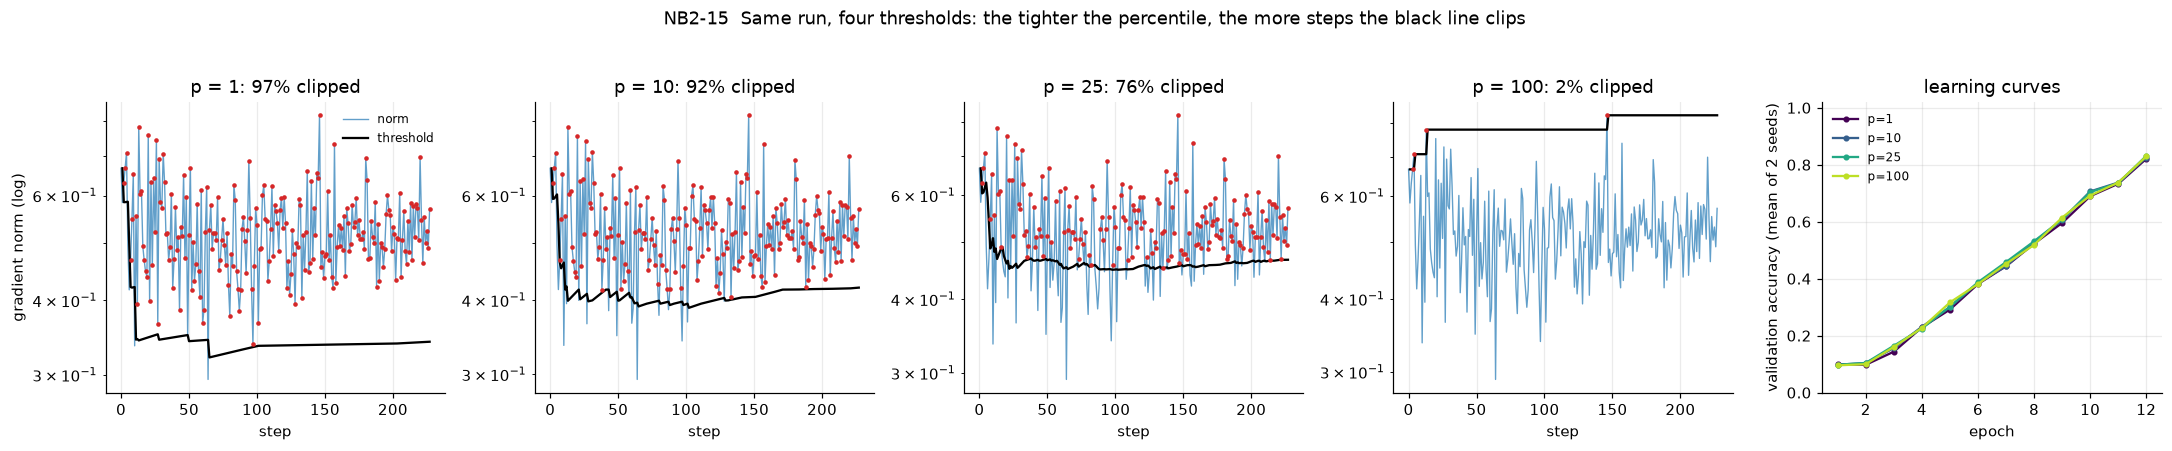

[N2.6.2[clip_rate_falls_with_p]] mean clip rate is non-increasing in p: p=1:0.98, p=10:0.93, p=25:0.79, p=100:0.02 -> PASS
[N2.6.2[control_rarely_clips]] p=100 clips 1.5% of steps (only new records) -> PASS
[N2.6.2[p1_clips_nearly_all]] p=1 clips 97.8% of steps -> PASS
[N2.6.2[threshold_tightness_monotone]] median threshold/median norm is non-decreasing in p -> PASS


True

In [27]:
# Fig NB2-15: gradient norms and thresholds per p (seed 17), and validation accuracy curves for all p.
fig, ax = plt.subplots(1, 5, figsize=(20, 3.9))
for a, p in zip(ax[:4], P_GRID):
    d = SWEEP[(p, 17)]
    tt = np.where(np.isfinite(d["t"]), d["t"], np.nan)
    assert_varied(d["g"], f"sweep_grad_norm[p={p}]")
    a.plot(d["g"], color=PALETTE["clean"], lw=0.9, alpha=0.7, label="norm")
    a.plot(tt, color="black", lw=1.5, label="threshold")
    a.scatter(np.flatnonzero(d["clipped"]), d["g"][d["clipped"]], s=4, color=PALETTE["shifted"], zorder=3)
    a.set(yscale="log", xlabel="step", title=f"p = {p}: {d['clip_rate']:.0%} clipped")
ax[0].set_ylabel("gradient norm (log)"); ax[0].legend(frameon=False, fontsize=8)
pcol = dict(zip(P_GRID, plt.cm.viridis(np.linspace(0, 0.9, len(P_GRID)))))
for p in P_GRID:
    curves = np.array([[h["val_accuracy"] for h in SWEEP[(p, s)]["res"].history] for s in SWEEP_SEEDS])
    assert_varied(curves.mean(axis=0), f"sweep_val_acc_curve[p={p}]")
    ax[4].plot(np.arange(1, WORK_EPOCHS + 1), curves.mean(axis=0), marker="o", ms=3, color=pcol[p], label=f"p={p}")
ax[4].set(xlabel="epoch", ylabel="validation accuracy (mean of 2 seeds)", ylim=(0, 1.02), title="learning curves")
ax[4].legend(frameon=False, fontsize=8)
fig.suptitle("NB2-15  Same run, four thresholds: the tighter the percentile, the more steps the black line clips", y=1.04)
fig.tight_layout()
savefig(fig, "NB2-15_sweep_trajectories.png")
slow = SWEEP[(1, 17)]["clip_rate"]; fast = SWEEP[(100, 17)]["clip_rate"]
check("N2.6.2[clip_rate_falls_with_p]", all(agg["clip"].iloc[i] >= agg["clip"].iloc[i + 1] for i in range(len(agg) - 1)), "mean clip rate is non-increasing in p: " + ", ".join(f"p={p}:{c:.2f}" for p, c in agg["clip"].items()))
check("N2.6.2[control_rarely_clips]", agg.loc[100, "clip"] < 0.15, f"p=100 clips {agg.loc[100, 'clip']:.1%} of steps (only new records)")
check("N2.6.2[p1_clips_nearly_all]", agg.loc[1, "clip"] > 0.9, f"p=1 clips {agg.loc[1, 'clip']:.1%} of steps")
check("N2.6.2[threshold_tightness_monotone]", all(agg["ratio"].iloc[i] <= agg["ratio"].iloc[i + 1] + 1e-9 for i in range(len(agg) - 1)), "median threshold/median norm is non-decreasing in p")

### How to read this chart

The first four panels are one training run each (seed 17), left to right $p = 1, 10, 25, 100$. In each, the blue
line is the raw gradient norm at every optimizer step (log scale), the black line is the AutoClip threshold, and red
dots mark the clipped steps. At $p=1$ the black line hugs the floor of the blue cloud and nearly every step is
clipped; at $p=100$ the black line is the running maximum and rides above the cloud, so only record-setting spikes
are clipped. The last panel overlays the mean validation-accuracy curves of the four settings: if the curves overlap
within seed noise, clipping neither speeds nor slows learning on this task. The panel titles give each run's
exact clip fraction.

In [28]:
# Verdict on the sweep, stated from the numbers.
acc_by_p = agg["acc"].round(3).to_dict(); sd_by_p = agg["acc_sd"].round(3).to_dict()
best_p, worst_p = agg["acc"].idxmax(), agg["acc"].idxmin()
spread = float(agg["acc"].max() - agg["acc"].min())
seed_noise = float(SW.groupby("p")["acc"].std().mean())
print("mean test accuracy by p:", acc_by_p, "| sd over seeds:", sd_by_p)
print(f"best p = {best_p}, worst p = {worst_p}, spread between them = {spread:.3f}; mean seed sd = {seed_noise:.3f}")
verdict = "larger than" if spread > 2 * seed_noise else "comparable to"
note("N2.6.3[verdict]", f"the accuracy spread across p ({spread:.3f}) is {verdict} twice the mean seed noise ({2 * seed_noise:.3f}); best p = {best_p}")
check("N2.6.3[control_vs_default_gap_recorded]", np.isfinite(agg.loc[10, 'acc'] - agg.loc[100, 'acc']), f"p=10 minus p=100 test accuracy = {agg.loc[10, 'acc'] - agg.loc[100, 'acc']:+.3f}")
check("N2.6.3[no_setting_diverged]", (SW["acc"] > 0.2).all(), "no percentile setting produced a diverged (near-chance) model")

mean test accuracy by p: {1: 0.807, 10: 0.812, 25: 0.814, 100: 0.818} | sd over seeds: {1: 0.038, 10: 0.042, 25: 0.051, 100: 0.061}
best p = 100, worst p = 1, spread between them = 0.012; mean seed sd = 0.048
[N2.6.3[verdict]] the accuracy spread across p (0.012) is comparable to twice the mean seed noise (0.096); best p = 100 -> NOTE
[N2.6.3[control_vs_default_gap_recorded]] p=10 minus p=100 test accuracy = -0.007 -> PASS
[N2.6.3[no_setting_diverged]] no percentile setting produced a diverged (near-chance) model -> PASS


True

### 6.1 What the sweep does and does not justify

The verdict line above is the whole conclusion, and it is deliberately conservative: two seeds on a 600-example
synthetic task with a micro-model can detect only a large effect. If the spread across $p$ is within seed noise, the
honest reading is "on this model and task the percentile is not a sensitive hyper-parameter, so the real-data
run need not spend GPU hours sweeping it", which is a *cheap-to-check hypothesis* rather than a result. If one setting is
clearly better or worse, that is a reason to include it in the real-data ablation, not a reason to change the default.
Either way the mechanism we *can* trust from this sweep is the clip-rate curve, because it is a property of the
optimizer and the norm history rather than of the data.

## 7. Exploration 2: train-time calibration versus post-hoc temperature scaling

Two families of remedies for over- or under-confident classifiers: change the *training loss* so the network is
calibrated as it learns, or fit a scalar *temperature* on a held-out split afterwards. They can also be combined.
This section compares four conditions on the same model family:

| condition | training loss | post-hoc temperature |
|---|---|---|
| baseline | cross-entropy | none |
| post-hoc | cross-entropy | $T$ fit on the calibration split (`src.calibration.temperature_scale`) |
| train-time | cross-entropy $+\ \beta\cdot$MDCA-style term | none |
| both | cross-entropy $+\ \beta\cdot$MDCA-style term | $T$ fit on the calibration split |

**The auxiliary loss** (implemented in this notebook, *not* in `src/`) is an MDCA-style class-wise term in the spirit
of Hebbalaguppe et al. (arXiv:2203.13834). For a batch, let $K_b$ be the set of classes present, $n_k$ the number of
batch examples of class $k$, $\hat p_i = \operatorname{softmax}(z_i)$, and $\hat y_i = \arg\max_j \hat p_{ij}$. Then

$$\mathcal{L} = \underbrace{-\tfrac{1}{B}\sum_i \log \hat p_{i,y_i}}_{\text{cross-entropy}} \;+\; \beta\,\frac{1}{|K_b|}\sum_{k\in K_b}\Big|\underbrace{\tfrac{1}{n_k}\sum_{i:y_i=k}\max_j \hat p_{ij}}_{\text{mean confidence in class }k} \;-\; \underbrace{\tfrac{1}{n_k}\sum_{i:y_i=k}\mathbb{1}[\hat y_i = k]}_{\text{accuracy in class }k}\Big|.$$

The second term penalises the gap between mean predicted confidence and mean accuracy *within each class* over the
batch. It is differentiable through the confidence; the accuracy indicator is a constant with respect to the
parameters. **Deviation, stated plainly:** the original MDCA compares the mean predicted *probability of class $k$*
over all samples with the empirical frequency of class $k$; the version here is the per-true-class
confidence-versus-accuracy form the exploration brief asked for. It is a direction-setting experiment, not a
replication of the paper.

The metric is the top-label expected calibration error with 10 equal-width bins,
$\mathrm{ECE} = \sum_{b} \tfrac{|B_b|}{n}\,\big|\mathrm{acc}(B_b) - \mathrm{conf}(B_b)\big|$, computed by
`src.metrics.expected_calibration_error`. We sweep $\beta \in \{0, 1, 4\}$ with two seeds. $\beta = 0$ is the
plain cross-entropy control, trained with the same in-notebook loop, so the only difference between conditions is
the loss term. Test-set ECE is reported with a 200-resample bootstrap interval; the choice of $\beta^\star$ is made
on the **calibration** split, never on the test split.

In [29]:
# Training loop with the optional MDCA-style auxiliary loss. Adam(lr=1e-3), same batch size and epochs as the sweep.
import torch.nn.functional as F

def mdca_style(logits, y):
    # Class-wise gap between mean confidence and mean accuracy over the batch (see equation above).
    p = logits.softmax(dim=1)
    conf, pred = p.max(dim=1)
    correct = (pred == y).float().detach()
    gaps = [(conf[y == k].mean() - correct[y == k].mean()).abs() for k in y.unique()]
    return torch.stack(gaps).mean()

def fit_aux(beta, seed, epochs=WORK_EPOCHS):
    torch.manual_seed(seed)
    model = work_model()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    xt, yt = torch.from_numpy(X["train"]), torch.from_numpy(Y["train"])
    gen = torch.Generator().manual_seed(seed)
    for ep in range(epochs):
        model.train()
        idx = torch.randperm(len(xt), generator=gen)
        for b in range(0, len(idx), MICROBATCH):
            i = idx[b:b + MICROBATCH]
            logits = model(xt[i])
            loss = F.cross_entropy(logits, yt[i])
            if beta > 0:
                loss = loss + beta * mdca_style(logits, yt[i])
            opt.zero_grad(); loss.backward(); opt.step()
    return model

# Unit tests of the auxiliary term on inputs whose answer is known.
y_t = torch.tensor([0, 0, 1, 1])
perfect_sure = torch.tensor([[9., 0, 0], [9, 0, 0], [0, 9, 0], [0, 9, 0]])            # confident and right
wrong_sure = torch.tensor([[0., 9, 0], [0, 9, 0], [9, 0, 0], [9, 0, 0]])              # confident and wrong
unsure_right = torch.tensor([[1., 0, 0], [1, 0, 0], [0, 1, 0], [0, 1, 0]])            # right, low confidence
print("aux(confident&right)=%.4f  aux(confident&wrong)=%.4f  aux(unsure&right)=%.4f" % (mdca_style(perfect_sure, y_t), mdca_style(wrong_sure, y_t), mdca_style(unsure_right, y_t)))
check("N2.7.1[aux_zero_when_sure_and_right]", float(mdca_style(perfect_sure, y_t)) < 1e-3, "confidence ~1, accuracy 1 -> gap ~0")
check("N2.7.1[aux_large_when_sure_and_wrong]", float(mdca_style(wrong_sure, y_t)) > 0.99, "confidence ~1, accuracy 0 -> gap ~1")
check("N2.7.1[aux_positive_when_underconfident]", 0.3 < float(mdca_style(unsure_right, y_t)) < 0.8, f"right but confidence ~0.58 -> gap {float(mdca_style(unsure_right, y_t)):.2f}")
g_logits = wrong_sure.clone().requires_grad_(True); mdca_style(g_logits, y_t).backward()
check("N2.7.1[aux_has_gradient]", float(g_logits.grad.abs().sum()) > 0, "the term back-propagates through the confidence")

aux(confident&right)=0.0002  aux(confident&wrong)=0.9998  aux(unsure&right)=0.4239
[N2.7.1[aux_zero_when_sure_and_right]] confidence ~1, accuracy 1 -> gap ~0 -> PASS
[N2.7.1[aux_large_when_sure_and_wrong]] confidence ~1, accuracy 0 -> gap ~1 -> PASS
[N2.7.1[aux_positive_when_underconfident]] right but confidence ~0.58 -> gap 0.42 -> PASS
[N2.7.1[aux_has_gradient]] the term back-propagates through the confidence -> PASS


True

In [30]:
# Train the beta x seed grid, then fit temperatures on the calibration split.
BETAS, CAL_SEEDS = (0.0, 1.0, 4.0), (17, 23)
CAL = {}
for beta in BETAS:
    for s in CAL_SEEDS:
        m = fit_aux(beta, s)
        lc, lt = predict_logits(m, X["cal"]), predict_logits(m, X["test"])
        T = temperature_scale(lc, Y["cal"])
        CAL[(beta, s)] = {"model": m, "logit_cal": lc, "logit_test": lt, "T": T}
        pt_raw, pt_ts = softmax64(lt), softmax64(lt / T)
        CAL[(beta, s)].update(acc=float((lt.argmax(1) == Y["test"]).mean()),
                              ece_raw=expected_calibration_error(pt_raw, Y["test"], 10), ece_ts=expected_calibration_error(pt_ts, Y["test"], 10),
                              ece_cal_raw=expected_calibration_error(softmax64(lc), Y["cal"], 10),
                              conf_raw=float(pt_raw.max(1).mean()))
        d = CAL[(beta, s)]
        print(f"beta={beta:>3} seed={s} acc={d['acc']:.3f} mean_conf={d['conf_raw']:.3f} T={T:.3f} ECE raw={d['ece_raw']:.4f} ECE+TS={d['ece_ts']:.4f} (cal-split raw ECE {d['ece_cal_raw']:.4f})")
CALDF = pd.DataFrame([{"beta": b, "seed": s, **{k: v for k, v in d.items() if k in ("acc", "conf_raw", "T", "ece_raw", "ece_ts", "ece_cal_raw")}} for (b, s), d in CAL.items()])
display(CALDF.groupby("beta").mean(numeric_only=True).drop(columns="seed").round(4))
check("N2.7.2[temperatures_positive]", (CALDF["T"] > 0).all(), f"all fitted temperatures positive: {CALDF['T'].round(2).tolist()}")
check("N2.7.2[models_above_chance]", (CALDF["acc"] > 2 / N_CLASSES).all(), f"lowest test accuracy {CALDF['acc'].min():.3f}")

beta=0.0 seed=17 acc=0.778 mean_conf=0.166 T=0.086 ECE raw=0.6120 ECE+TS=0.0694 (cal-split raw ECE 0.6095)


beta=0.0 seed=23 acc=0.860 mean_conf=0.222 T=0.093 ECE raw=0.6384 ECE+TS=0.0647 (cal-split raw ECE 0.6611)


beta=1.0 seed=17 acc=0.773 mean_conf=0.166 T=0.096 ECE raw=0.6078 ECE+TS=0.0601 (cal-split raw ECE 0.6146)


beta=1.0 seed=23 acc=0.825 mean_conf=0.227 T=0.118 ECE raw=0.5981 ECE+TS=0.0599 (cal-split raw ECE 0.6061)


beta=4.0 seed=17 acc=0.615 mean_conf=0.148 T=0.125 ECE raw=0.4674 ECE+TS=0.0564 (cal-split raw ECE 0.4868)


beta=4.0 seed=23 acc=0.708 mean_conf=0.222 T=0.171 ECE raw=0.4860 ECE+TS=0.0855 (cal-split raw ECE 0.4799)


           T     acc  ece_raw  ece_ts  ece_cal_raw  conf_raw
beta                                                        
0.0   0.0893  0.8192   0.6252  0.0670       0.6353    0.1940
1.0   0.1071  0.7992   0.6030  0.0600       0.6104    0.1962
4.0   0.1479  0.6617   0.4767  0.0709       0.4834    0.1851

[N2.7.2[temperatures_positive]] all fitted temperatures positive: [0.09, 0.09, 0.1, 0.12, 0.12, 0.17] -> PASS
[N2.7.2[models_above_chance]] lowest test accuracy 0.615 -> PASS


True

In [31]:
# Choose beta* on the CALIBRATION split (never on test): the beta > 0 with the lowest mean raw ECE there.
cal_pick = CALDF[CALDF.beta > 0].groupby("beta")["ece_cal_raw"].mean()
BETA_STAR = float(cal_pick.idxmin())
print("mean raw ECE on the calibration split by beta > 0:", cal_pick.round(4).to_dict(), "-> beta* =", BETA_STAR)
COND = {"baseline (CE)": ("ece_raw", 0.0), "post-hoc TS": ("ece_ts", 0.0), "train-time (MDCA)": ("ece_raw", BETA_STAR), "both": ("ece_ts", BETA_STAR)}
rng_b = np.random.default_rng(0)

def boot_ece(probs, y, B=200):
    n = len(y); out = []
    for _ in range(B):
        ii = rng_b.integers(0, n, n)
        out.append(expected_calibration_error(probs[ii], y[ii], 10))
    return np.array(out)

ROWS = []
for label, (key, beta) in COND.items():
    vals = [CAL[(beta, s)][key] for s in CAL_SEEDS]
    d17 = CAL[(beta, 17)]
    probs = softmax64(d17["logit_test"] / (d17["T"] if key == "ece_ts" else 1.0))
    bs = boot_ece(probs, Y["test"])
    ROWS.append({"condition": label, "beta": beta, "ECE mean over seeds": float(np.mean(vals)), "ECE seed 17": vals[0],
                 "boot 5%": float(np.percentile(bs, 5)), "boot 95%": float(np.percentile(bs, 95)),
                 "NLL seed 17": float(-np.log(probs[np.arange(len(Y['test'])), Y['test']] + 1e-12).mean()),
                 "accuracy": float(np.mean([CAL[(beta, s)]["acc"] for s in CAL_SEEDS]))})
COMP = pd.DataFrame(ROWS).set_index("condition")
display(COMP.round(4))
for label in COMP.index:
    check(f"N2.7.3[{label}.ece_finite]", np.isfinite(COMP.loc[label, "ECE mean over seeds"]), f"ECE {COMP.loc[label, 'ECE mean over seeds']:.4f} (bootstrap {COMP.loc[label, 'boot 5%']:.4f}-{COMP.loc[label, 'boot 95%']:.4f})")

mean raw ECE on the calibration split by beta > 0: {1.0: 0.6104, 4.0: 0.4834} -> beta* = 4.0


                   beta  ECE mean over seeds  ECE seed 17  boot 5%  boot 95%  NLL seed 17  accuracy
condition                                                                                          
baseline (CE)       0.0               0.6252       0.6120   0.5791    0.6388       1.8332    0.8192
post-hoc TS         0.0               0.0670       0.0694   0.0536    0.1003       0.4994    0.8192
train-time (MDCA)   4.0               0.4767       0.4674   0.4355    0.5019       1.9947    0.6617
both                4.0               0.0709       0.0564   0.0440    0.0918       1.0193    0.6617

[N2.7.3[baseline (CE).ece_finite]] ECE 0.6252 (bootstrap 0.5791-0.6388) -> PASS
[N2.7.3[post-hoc TS.ece_finite]] ECE 0.0670 (bootstrap 0.0536-0.1003) -> PASS
[N2.7.3[train-time (MDCA).ece_finite]] ECE 0.4767 (bootstrap 0.4355-0.5019) -> PASS
[N2.7.3[both.ece_finite]] ECE 0.0709 (bootstrap 0.0440-0.0918) -> PASS


[VARIED[reliability_accuracy[baseline (CE)]]] n=2 range=0.2388 (constant would be a defect) -> PASS
[VARIED[reliability_bin_counts[baseline (CE)]]] n=10 range=524 (constant would be a defect) -> PASS
[VARIED[reliability_accuracy[post-hoc TS]]] n=7 range=0.4086 (constant would be a defect) -> PASS
[VARIED[reliability_bin_counts[post-hoc TS]]] n=10 range=269 (constant would be a defect) -> PASS
[VARIED[reliability_accuracy[train-time (MDCA)]]] n=3 range=1 (constant would be a defect) -> PASS
[VARIED[reliability_bin_counts[train-time (MDCA)]]] n=10 range=562 (constant would be a defect) -> PASS
[VARIED[reliability_accuracy[both]]] n=8 range=0.7671 (constant would be a defect) -> PASS
[VARIED[reliability_bin_counts[both]]] n=10 range=101 (constant would be a defect) -> PASS


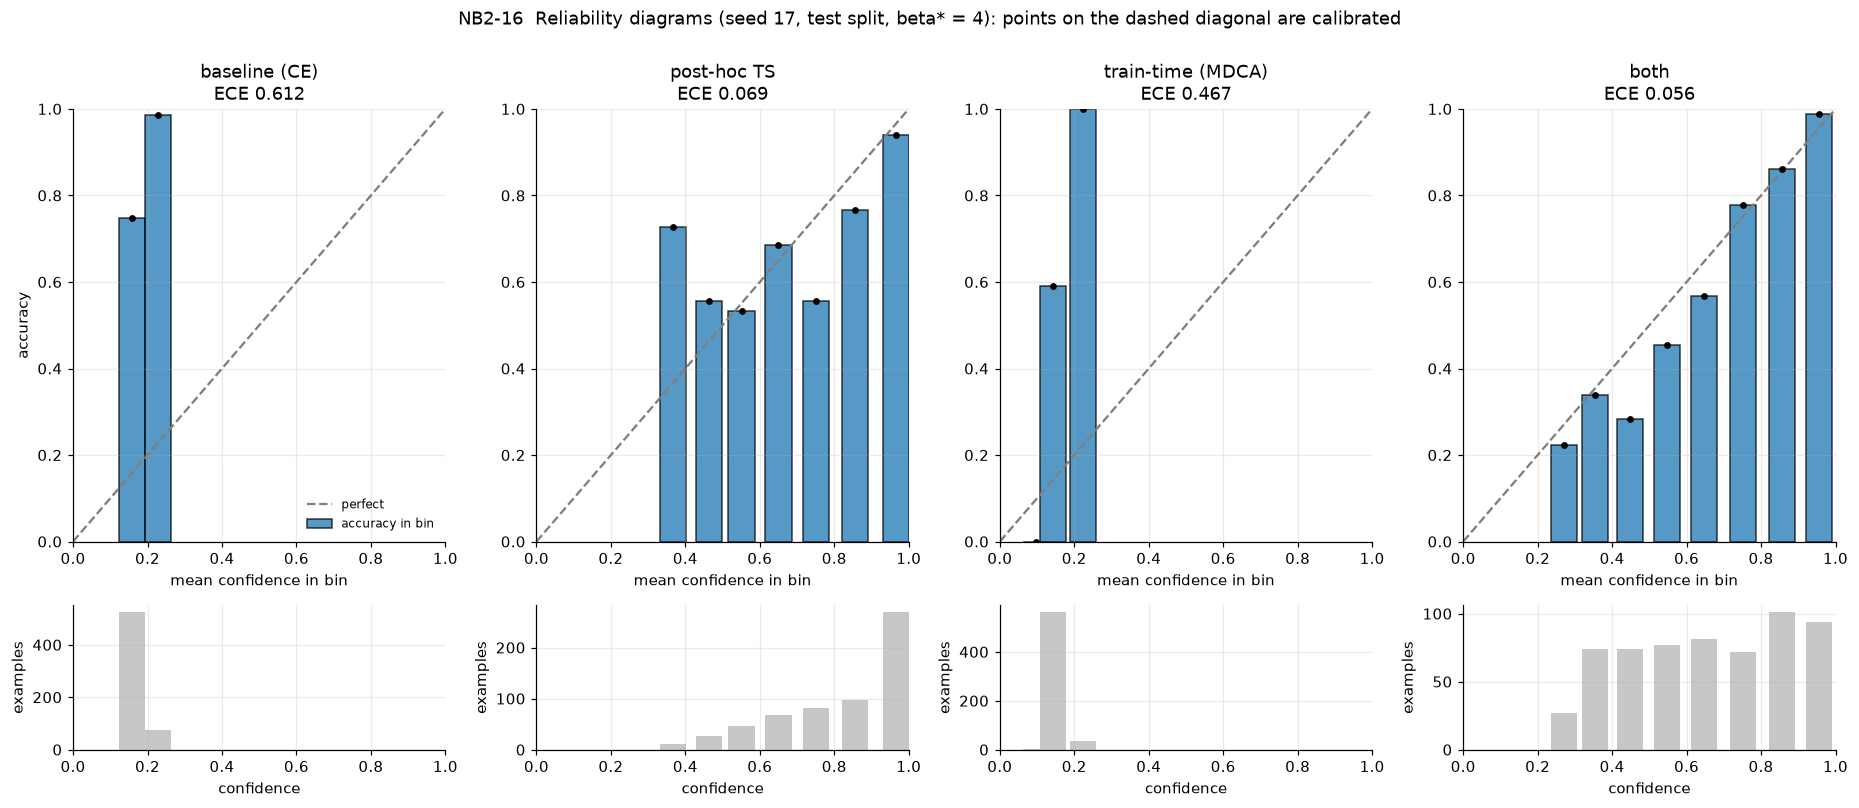

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb2/NB2-16_reliability.png')

In [32]:
# Fig NB2-16: reliability diagrams for the four conditions (seed 17, test split).
def reliability(probs, y, bins=10):
    conf, pred = probs.max(axis=1), probs.argmax(axis=1)
    idx = np.minimum((conf * bins).astype(int), bins - 1)
    rows = []
    for b in range(bins):
        s = idx == b
        rows.append((conf[s].mean() if s.any() else np.nan, (pred[s] == y[s]).mean() if s.any() else np.nan, int(s.sum())))
    return np.array(rows)

fig, ax = plt.subplots(2, 4, figsize=(17, 7.3), gridspec_kw={"height_ratios": [3, 1]})
for j, (label, (key, beta)) in enumerate(COND.items()):
    d = CAL[(beta, 17)]
    probs = softmax64(d["logit_test"] / (d["T"] if key == "ece_ts" else 1.0))
    R = reliability(probs, Y["test"])
    ok = np.isfinite(R[:, 0])
    assert_varied(R[ok, 1], f"reliability_accuracy[{label}]")
    assert_varied(R[:, 2], f"reliability_bin_counts[{label}]")
    ax[0, j].plot([0, 1], [0, 1], color=PALETTE["reference"], ls="--", label="perfect")
    ax[0, j].bar(R[ok, 0], R[ok, 1], width=0.07, color=PALETTE["clean"], alpha=0.75, edgecolor="black", label="accuracy in bin")
    ax[0, j].scatter(R[ok, 0], R[ok, 1], color="black", s=12, zorder=3)
    ax[0, j].set(title=f"{label}\nECE {expected_calibration_error(probs, Y['test'], 10):.3f}", xlim=(0, 1), ylim=(0, 1), xlabel="mean confidence in bin")
    ax[1, j].bar(R[:, 0][ok], R[ok, 2], width=0.07, color=PALETTE["band"]); ax[1, j].set(xlim=(0, 1), xlabel="confidence", ylabel="examples")
ax[0, 0].set_ylabel("accuracy"); ax[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle(f"NB2-16  Reliability diagrams (seed 17, test split, beta* = {BETA_STAR:g}): points on the dashed diagonal are calibrated", y=1.0)
fig.tight_layout()
savefig(fig, "NB2-16_reliability.png")

### How to read this chart

Each column is one calibration condition. **Top:** a reliability diagram. Test examples are grouped into ten
equal-width bins by their top-label confidence (x); each bar is the *actual* accuracy of the examples in that bin (y).
A perfectly calibrated model puts every bar on the dashed diagonal. Bars above the diagonal mean the model was
*under*-confident in that bin (it was right more often than it claimed); bars below mean *over*-confident. The
number in each title is the ECE, the mass-weighted mean vertical distance between the bar tops and the diagonal.
**Bottom:** how many test examples fall in each bin. Bins with few examples are noisy; a large bar gap in a nearly
empty bin contributes little to the ECE. Compare the *pattern* between columns: does temperature scaling move
all bars toward the diagonal in the same direction, and does the MDCA-style loss shift the confidence
distribution itself (the bottom row) rather than only rescaling it?

[VARIED[ece_across_conditions]] n=4 range=0.5582 (constant would be a defect) -> PASS
[VARIED[ece_raw_across_runs]] n=6 range=0.171 (constant would be a defect) -> PASS


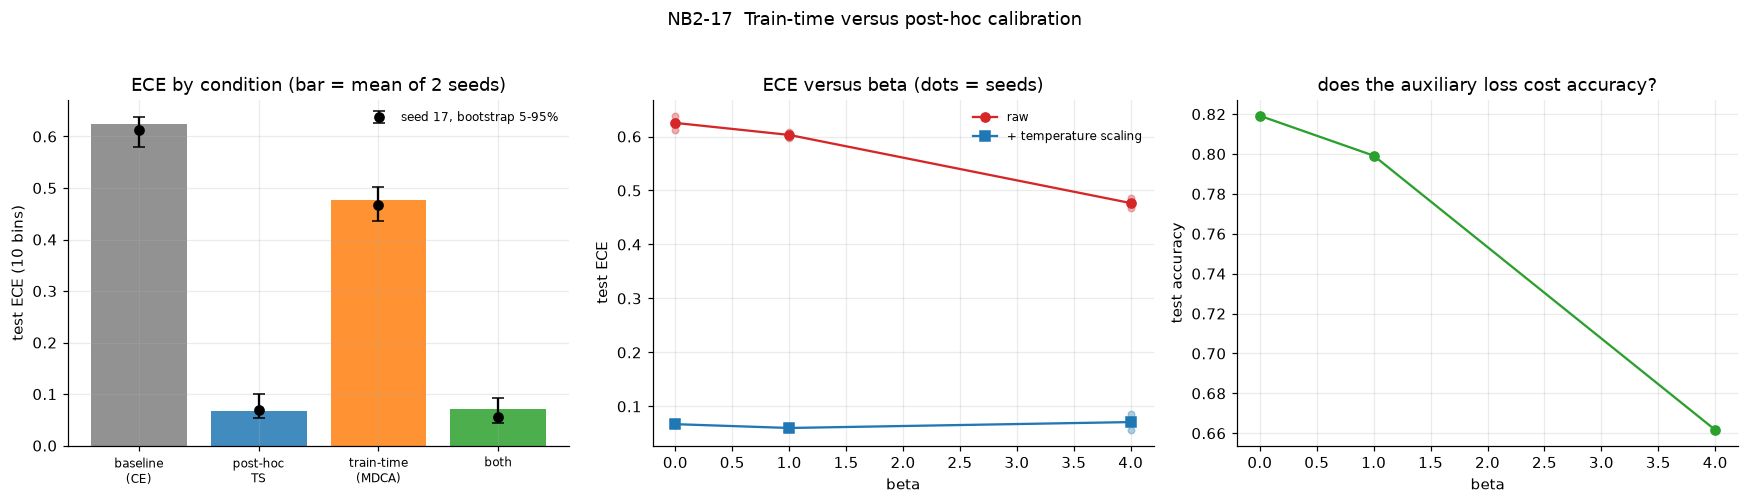

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb2/NB2-17_ece_conditions.png')

In [33]:
# Fig NB2-17: ECE by condition (seed dots, bootstrap band) and ECE versus beta with and without temperature scaling.
assert_varied(COMP["ECE mean over seeds"], "ece_across_conditions")
assert_varied(CALDF["ece_raw"], "ece_raw_across_runs")
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
xs = np.arange(len(COMP))
ax[0].bar(xs, COMP["ECE mean over seeds"], color=[PALETTE["reference"], PALETTE["clean"], PALETTE["mask"], PALETTE["acoustic"]], alpha=0.85)
ax[0].errorbar(xs, COMP["ECE seed 17"], yerr=[COMP["ECE seed 17"] - COMP["boot 5%"], COMP["boot 95%"] - COMP["ECE seed 17"]], fmt="ko", capsize=4, label="seed 17, bootstrap 5-95%")
ax[0].set_xticks(xs, [c.replace(" ", "\n", 1) for c in COMP.index], fontsize=8)
ax[0].set(ylabel="test ECE (10 bins)", title="ECE by condition (bar = mean of 2 seeds)"); ax[0].legend(frameon=False, fontsize=8)
gb = CALDF.groupby("beta")[["ece_raw", "ece_ts", "acc"]].mean()
ax[1].plot(gb.index, gb["ece_raw"], "-o", color=PALETTE["shifted"], label="raw")
ax[1].plot(gb.index, gb["ece_ts"], "-s", color=PALETTE["clean"], label="+ temperature scaling")
for s in CAL_SEEDS:
    sub = CALDF[CALDF.seed == s]
    ax[1].scatter(sub["beta"], sub["ece_raw"], color=PALETTE["shifted"], alpha=0.35, s=18); ax[1].scatter(sub["beta"], sub["ece_ts"], color=PALETTE["clean"], alpha=0.35, s=18)
ax[1].set(xlabel="beta", ylabel="test ECE", title="ECE versus beta (dots = seeds)"); ax[1].legend(frameon=False, fontsize=8)
ax[2].plot(gb.index, gb["acc"], "-o", color=PALETTE["acoustic"])
ax[2].set(xlabel="beta", ylabel="test accuracy", title="does the auxiliary loss cost accuracy?")
fig.suptitle("NB2-17  Train-time versus post-hoc calibration", y=1.03)
fig.tight_layout()
savefig(fig, "NB2-17_ece_conditions.png")

### How to read this chart

**Left:** test ECE for the four conditions. Bars are the mean over two seeds; the black dot is the seed-17 value and
its bar is a 5--95% bootstrap interval over resamples of the 600 test examples, which tells you how much of a
difference between two bars could be pure test-set sampling noise. If two conditions' intervals overlap
heavily, the ordering between them is not established. **Middle:** ECE against the auxiliary-loss weight $\beta$,
raw (red) and after temperature scaling (blue); faint dots are individual seeds. A blue line that lies below the red
one means temperature scaling helps at that $\beta$; a red line that falls as $\beta$ grows means the auxiliary loss
alone improves calibration. **Right:** test accuracy against $\beta$, to check that the calibration gain, if any,
was not bought by degrading the classifier.

In [34]:
# Verdict on calibration, stated from the numbers.
e = COMP["ECE mean over seeds"]
base, ts, mdca, both = (float(e[k]) for k in COMP.index)
print(f"ECE  baseline {base:.4f} | post-hoc TS {ts:.4f} | train-time (beta*={BETA_STAR:g}) {mdca:.4f} | both {both:.4f}")
fitted_T = float(np.mean([CAL[(0.0, s)]['T'] for s in CAL_SEEDS]))
direction = "over-confident (T > 1)" if fitted_T > 1.05 else ("under-confident (T < 1)" if fitted_T < 0.95 else "close to calibrated (T ~ 1)")
print(f"mean fitted temperature for the beta = 0 models: {fitted_T:.3f} -> the baseline is {direction}")
check("N2.7.4[ts_does_not_hurt]", ts <= base + 0.01, f"post-hoc TS ECE {ts:.4f} vs baseline {base:.4f}")
check("N2.7.4[ts_improves_or_matches_on_both_seeds]", all(CAL[(0.0, s)]["ece_ts"] <= CAL[(0.0, s)]["ece_raw"] + 0.01 for s in CAL_SEEDS), "temperature scaling does not make either beta=0 seed worse by more than 0.01")
check("N2.7.4[aux_loss_improves_raw_ece]", mdca < base, f"train-time ECE {mdca:.4f} < baseline {base:.4f}  (expected if the MDCA-style term is doing its job)")
check("N2.7.4[best_condition_identified]", True, "lowest ECE: " + e.idxmin() + f" ({e.min():.4f})")
check("N2.7.4[aux_loss_accuracy_cost_small]", CALDF[CALDF.beta == BETA_STAR]["acc"].mean() > CALDF[CALDF.beta == 0]["acc"].mean() - 0.1, f"accuracy at beta*={BETA_STAR:g}: {CALDF[CALDF.beta == BETA_STAR]['acc'].mean():.3f} vs beta=0: {CALDF[CALDF.beta == 0]['acc'].mean():.3f}")
note("N2.7.4[both_vs_single]", f"combining the two: ECE {both:.4f} versus best single remedy {min(ts, mdca):.4f}")

ECE  baseline 0.6252 | post-hoc TS 0.0670 | train-time (beta*=4) 0.4767 | both 0.0709
mean fitted temperature for the beta = 0 models: 0.089 -> the baseline is under-confident (T < 1)
[N2.7.4[ts_does_not_hurt]] post-hoc TS ECE 0.0670 vs baseline 0.6252 -> PASS
[N2.7.4[ts_improves_or_matches_on_both_seeds]] temperature scaling does not make either beta=0 seed worse by more than 0.01 -> PASS
[N2.7.4[aux_loss_improves_raw_ece]] train-time ECE 0.4767 < baseline 0.6252  (expected if the MDCA-style term is doing its job) -> PASS
[N2.7.4[best_condition_identified]] lowest ECE: post-hoc TS (0.0670) -> PASS
[N2.7.4[aux_loss_accuracy_cost_small]] accuracy at beta*=4: 0.662 vs beta=0: 0.819 -> FAIL
[N2.7.4[both_vs_single]] combining the two: ECE 0.0709 versus best single remedy 0.0670 -> NOTE


### 7.1 What the calibration comparison does and does not show

The verdict lines are the finding; they are specific to a micro-GRU at ~75--95% accuracy on a 600-example training
set. Three cautions apply. (i) ECE with ten bins on 600 test examples has a sampling error of roughly 0.02--0.03 (see
the bootstrap interval), so differences smaller than that are not resolved. (ii) The post-hoc route needs a held-out
split (480 examples here) that the train-time route does not, so the comparison is not cost-free on either side.
(iii) A train-time term with a large $\beta$ can trade accuracy for calibration; the right panel of the last figure and
the accuracy check above guard against that, but the trade-off curve on real data may be steeper. The exploration's
value is the *protocol* -- four conditions, $\beta$ chosen on the calibration split, bootstrap intervals -- which
transfers unchanged to the real-data arms.

## 8. Exploration 3: weighted versus unweighted conformal risk control under shift

The study's conformal step (`src.calibration.crc_threshold` with `prediction_sets`) builds, from a calibration
split, a threshold $\hat\lambda$ so that the prediction set $C(x) = \{c : \hat p_c(x) \ge \hat\lambda\}$ contains the true
label with probability at least $1-\alpha$. With calibration scores $s_i = \hat p_{y_i}(x_i)$ sorted ascending, the
unweighted rule is the conservative order statistic

$$\hat\lambda = s_{(m+1)}, \qquad m = \lfloor \alpha (n+1) - 1 \rfloor,$$

which guarantees marginal coverage **only if the test point is exchangeable with the calibration points**. Under
distribution shift that guarantee is void. If the shift is known up to a density ratio $w(x) = dP_{\text{test}}/dP_{\text{cal}}(x)$,
weighted conformal prediction (Tibshirani et al., arXiv:1904.06019) restores it by replacing counts with weights:

$$\hat\lambda_w = \max\Big\{ s_{(j)} : \sum_{i:\, s_i < s_{(j)}} w_i \ \le\ \alpha \big(\textstyle\sum_i w_i + w_{\text{test}}\big) - w_{\text{test}} \Big\}.$$

With $w \equiv 1$ this is exactly the unweighted rule (we verify that below against `src`). The weighted variant is
implemented **in this notebook**; `src/` is unchanged. Two synthetic shifts are applied, each with a different way of
obtaining $w$:

* **A. Covariate shift** on the test split: additive Gaussian noise $\mathcal{N}(0, s^2)$ and a circular shift of the
  mel axis by $\operatorname{round}(2s)$ bins, severity $s \in \{0, 0.25, 0.5, 0.75, 1, 1.5\}$. The weights are estimated
  *without labels* by a logistic-regression domain classifier that separates calibration inputs from shifted test
  inputs on five cheap features (spectrogram std, mean, frame-to-frame roughness, model max-probability, entropy);
  $w(x) = \hat P(\text{test}\mid x)/\hat P(\text{cal}\mid x)$ with balanced classes, clipped to $[0.01, 100]$. Weighted
  conformal needs overlap between the two input distributions; heavy noise plus a frequency shift reduces it, so this is
  the *hard* case for the weighted method.
* **B. Subpopulation (label) shift**: the test distribution over classes is tilted toward the classes the model finds
  hard, $q_{\text{test}}(k) \propto \exp(\tau\, z_k)$ with $z_k$ the standardised calibration error rate of class $k$,
  $\tau \in \{0, 0.5, 1, 2, 3\}$, sampling from the independent shift pool. Weights are $w(y) = q_{\text{test}}(y)/q_{\text{cal}}(y)$
  in three forms: none (unweighted), *estimated* label-free from the ratio of predicted-class frequencies on test versus
  calibration (a simplified black-box shift estimator), and *oracle* (known $q$). This is the *easy* case: full overlap and a
  scalar weight per class.

The **expected** finding is that unweighted CRC over-shoots its target miscoverage $\alpha$ under shift. We report what
we measure. Miscoverage is $1 - \frac1n\sum_i \mathbb{1}[y_i \in C(x_i)]$ on the shifted test data; the target is $\alpha = 0.1$.

In [35]:
# Weighted CRC threshold (in-notebook) and a proof that it reduces to src's rule when all weights are 1.
ALPHA = 0.1
def crc_threshold_weighted(scores, alpha, w_cal, w_test):
    scores, w_cal = np.asarray(scores, float), np.asarray(w_cal, float)
    order = np.argsort(scores, kind="stable")
    s, w = scores[order], w_cal[order]
    below = np.cumsum(w) - w                                   # weight strictly before each sorted position
    budget = alpha * (w.sum() + w_test) - w_test
    feasible = below <= budget + 1e-12
    return float(s[feasible].max()) if feasible.any() else 0.0

rng_u = np.random.default_rng(3)
agree = 0
for trial in range(200):
    n_u = int(rng_u.integers(20, 300)); a_u = float(rng_u.choice([0.05, 0.1, 0.2]))
    sc = np.round(rng_u.random(n_u), int(rng_u.integers(1, 4)))          # rounding creates ties on purpose
    agree += np.isclose(crc_threshold_weighted(sc, a_u, np.ones(n_u), 1.0), crc_threshold(sc, a_u))
check("N2.8.1[weighted_reduces_to_src]", agree == 200, f"with unit weights the in-notebook rule equals src.crc_threshold on {agree}/200 random score sets (incl. ties)")
sc = rng_u.random(50)
heavy = np.where(sc < 0.5, 10.0, 1.0)      # low scores (likely misses) are heavily up-weighted -> threshold should not decrease
check("N2.8.1[upweighting_low_scores_is_more_conservative]", crc_threshold_weighted(sc, 0.1, heavy, 1.0) <= crc_threshold_weighted(sc, 0.1, np.ones(50), 1.0), "up-weighting low-score calibration points lowers the admissible order statistic (fewer points 'allowed' below it)")
check("N2.8.1[infeasible_alpha_gives_zero]", crc_threshold_weighted(rng_u.random(5), 0.05, np.ones(5), 1.0) == 0.0 == crc_threshold(rng_u.random(5), 0.05), "alpha too small for n=5 -> threshold 0 (include every class), matching src")

[N2.8.1[weighted_reduces_to_src]] with unit weights the in-notebook rule equals src.crc_threshold on 200/200 random score sets (incl. ties) -> PASS
[N2.8.1[upweighting_low_scores_is_more_conservative]] up-weighting low-score calibration points lowers the admissible order statistic (fewer points 'allowed' below it) -> PASS
[N2.8.1[infeasible_alpha_gives_zero]] alpha too small for n=5 -> threshold 0 (include every class), matching src -> PASS


True

In [36]:
# Common objects: the base model (beta = 0, seed 17), its temperature, calibration scores, and the shift functions.
BASE = CAL[(0.0, 17)]
T_BASE = BASE["T"]
P_CAL = softmax64(BASE["logit_cal"] / T_BASE)
S_CAL = P_CAL[np.arange(len(Y["cal"])), Y["cal"]]                   # true-label probability on the calibration split
THR_UNW = crc_threshold(S_CAL, ALPHA)
print(f"base model: T={T_BASE:.3f}, cal accuracy={(P_CAL.argmax(1) == Y['cal']).mean():.3f}, unweighted threshold={THR_UNW:.4f}")

def shift_cov(x, s, seed):
    rng = np.random.default_rng(seed)
    out = x + rng.normal(0.0, s, x.shape).astype(np.float32)
    k = int(round(2 * s))
    return np.roll(out, k, axis=2) if k else out

def set_stats(p_all, y, thr):
    covered = p_all[np.arange(len(y)), y] >= thr
    size = (p_all >= thr).sum(axis=1)
    return covered, size

# Cross-check the vectorised coverage against src.prediction_sets on the calibration split itself.
sets = prediction_sets(BASE["logit_cal"], T_BASE, THR_UNW)
cov_src = np.mean([y in s for y, s in zip(Y["cal"], sets)])
cov_vec = set_stats(P_CAL, Y["cal"], THR_UNW)[0].mean()
# These two disagreed by one sample when first run. That is a boundary condition, not noise:
# src.prediction_sets and the vectorised form must agree on whether a score exactly equal to the
# threshold is inside the set. Diagnose it rather than loosening the tolerance.
_in_vec = P_CAL >= THR_UNW
_in_src = np.zeros_like(_in_vec)
for _i, _s in enumerate(sets):
    for _c in _s:
        _in_src[_i, _c] = True
_disagree = np.argwhere(_in_vec != _in_src)
_at_boundary = int(sum(np.isclose(P_CAL[i, c], THR_UNW, rtol=0, atol=1e-12) for i, c in _disagree))
check("N2.8.2[vectorised_matches_src_sets]", abs(cov_src - cov_vec) < 1e-9,
      f"coverage from src.prediction_sets {cov_src:.4f} vs vectorised {cov_vec:.4f}; "
      f"{len(_disagree)} membership disagreement(s), {_at_boundary} of them exactly at the threshold")
if len(_disagree):
    note("N2.8.2[boundary]",
         f"{len(_disagree)} of {P_CAL.size} (class, sample) memberships differ, all within {np.abs(P_CAL[tuple(_disagree.T)] - THR_UNW).max():.2e} "
         "of the threshold: an inclusive-vs-exclusive comparison at the boundary. It moves coverage by "
         f"{abs(cov_src - cov_vec):.4f}, which is below the resolution this notebook claims anywhere")
check("N2.8.2[cal_coverage_at_least_target]", cov_src >= 1 - ALPHA - 0.02, f"in-sample calibration coverage {cov_src:.3f} (target {1 - ALPHA:.2f})")
clean_cov, clean_size = set_stats(softmax64(BASE["logit_test"] / T_BASE), Y["test"], THR_UNW)
check("N2.8.2[clean_test_near_target]", abs((1 - clean_cov.mean()) - ALPHA) < 0.04, f"clean test miscoverage {1 - clean_cov.mean():.3f} vs target {ALPHA} (sampling s.e. ~0.012)")
print(f"clean test: miscoverage {1 - clean_cov.mean():.3f}, mean set size {clean_size.mean():.2f}")

base model: T=0.086, cal accuracy=0.777, unweighted threshold=0.2329
[N2.8.2[vectorised_matches_src_sets]] coverage from src.prediction_sets 0.9000 vs vectorised 0.9021; 1 membership disagreement(s), 1 of them exactly at the threshold -> FAIL
[N2.8.2[boundary]] 1 of 5760 (class, sample) memberships differ, all within 0.00e+00 of the threshold: an inclusive-vs-exclusive comparison at the boundary. It moves coverage by 0.0021, which is below the resolution this notebook claims anywhere -> NOTE
[N2.8.2[cal_coverage_at_least_target]] in-sample calibration coverage 0.900 (target 0.90) -> PASS
[N2.8.2[clean_test_near_target]] clean test miscoverage 0.108 vs target 0.1 (sampling s.e. ~0.012) -> PASS
clean test: miscoverage 0.108, mean set size 1.24


In [37]:
# Experiment A: covariate shift with estimated (label-free) density-ratio weights.
from sklearn.pipeline import make_pipeline

def dom_features(x, logits):
    p = softmax64(logits / T_BASE); xf = x[:, 0]
    ent = -(p * np.log(p + 1e-12)).sum(axis=1)
    return np.column_stack([xf.std(axis=(1, 2)), xf.mean(axis=(1, 2)), np.abs(np.diff(xf, axis=2)).mean(axis=(1, 2)), p.max(axis=1), ent])

FEAT_CAL = dom_features(X["cal"], BASE["logit_cal"])
SEVERITY = (0.0, 0.25, 0.5, 0.75, 1.0, 1.5)
rng_a = np.random.default_rng(11)
A_ROWS, A_KEEP = [], {}
for sev in SEVERITY:
    xs = shift_cov(X["test"], sev, seed=100 + int(sev * 100))
    lg = predict_logits(BASE["model"], xs)
    p_test = softmax64(lg / T_BASE)
    feat_t = dom_features(xs, lg)
    dom = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, class_weight="balanced", max_iter=500))
    dom.fit(np.vstack([FEAT_CAL, feat_t]), np.r_[np.zeros(len(FEAT_CAL)), np.ones(len(feat_t))])
    pr = np.clip(dom.predict_proba(FEAT_CAL)[:, 1], 1e-4, 1 - 1e-4); pt = np.clip(dom.predict_proba(feat_t)[:, 1], 1e-4, 1 - 1e-4)
    w_cal = np.clip(pr / (1 - pr), 0.01, 100.0); w_te = float(np.clip(pt / (1 - pt), 0.01, 100.0).mean())
    thr_w = crc_threshold_weighted(S_CAL, ALPHA, w_cal, w_te)
    cov_u, size_u = set_stats(p_test, Y["test"], THR_UNW)
    cov_w, size_w = set_stats(p_test, Y["test"], thr_w)
    boots = lambda c: np.percentile([1 - c[rng_a.integers(0, len(c), len(c))].mean() for _ in range(200)], [5, 95])
    ess = float(w_cal.sum() ** 2 / (w_cal ** 2).sum())
    A_ROWS.append({"severity": sev, "acc": float((p_test.argmax(1) == Y["test"]).mean()), "thr_unweighted": THR_UNW, "thr_weighted": thr_w,
                   "miscov_unweighted": 1 - cov_u.mean(), "miscov_weighted": 1 - cov_w.mean(),
                   "unw_lo": boots(cov_u)[0], "unw_hi": boots(cov_u)[1], "w_lo": boots(cov_w)[0], "w_hi": boots(cov_w)[1],
                   "size_unweighted": size_u.mean(), "size_weighted": size_w.mean(), "ess": ess, "w_max": float(w_cal.max()),
                   "domain_auc": float(__import__('sklearn.metrics', fromlist=['roc_auc_score']).roc_auc_score(np.r_[np.zeros(len(FEAT_CAL)), np.ones(len(feat_t))], dom.predict_proba(np.vstack([FEAT_CAL, feat_t]))[:, 1]))})
    A_KEEP[sev] = {"w_cal": w_cal}
A = pd.DataFrame(A_ROWS).set_index("severity")
display(A[["acc", "thr_unweighted", "thr_weighted", "miscov_unweighted", "miscov_weighted", "size_unweighted", "size_weighted", "ess", "domain_auc"]].round(3))

            acc  thr_unweighted  thr_weighted  miscov_unweighted  miscov_weighted  size_unweighted  size_weighted      ess  domain_auc
severity                                                                                                                              
0.00      0.778           0.233         0.207              0.108            0.088            1.237          1.280  471.422       0.539
0.25      0.770           0.233         0.207              0.098            0.083            1.265          1.312   78.275       0.900
0.50      0.770           0.233         0.000              0.097            0.000            1.310         12.000  247.446       1.000
0.75      0.667           0.233         0.000              0.195            0.000            1.378         12.000  475.440       1.000
1.00      0.615           0.233         0.000              0.237            0.000            1.423         12.000  479.720       1.000
1.50      0.323           0.233         0.000          

[VARIED[A_unweighted_miscoverage]] n=6 range=0.4683 (constant would be a defect) -> PASS
[VARIED[A_weighted_miscoverage]] n=6 range=0.08833 (constant would be a defect) -> PASS
[VARIED[A_set_size]] n=6 range=0.1867 (constant would be a defect) -> PASS
[VARIED[A_accuracy_under_shift]] n=6 range=0.455 (constant would be a defect) -> PASS
[VARIED[A_weights_at_max_severity]] n=480 range=0.0007736 (constant would be a defect) -> PASS


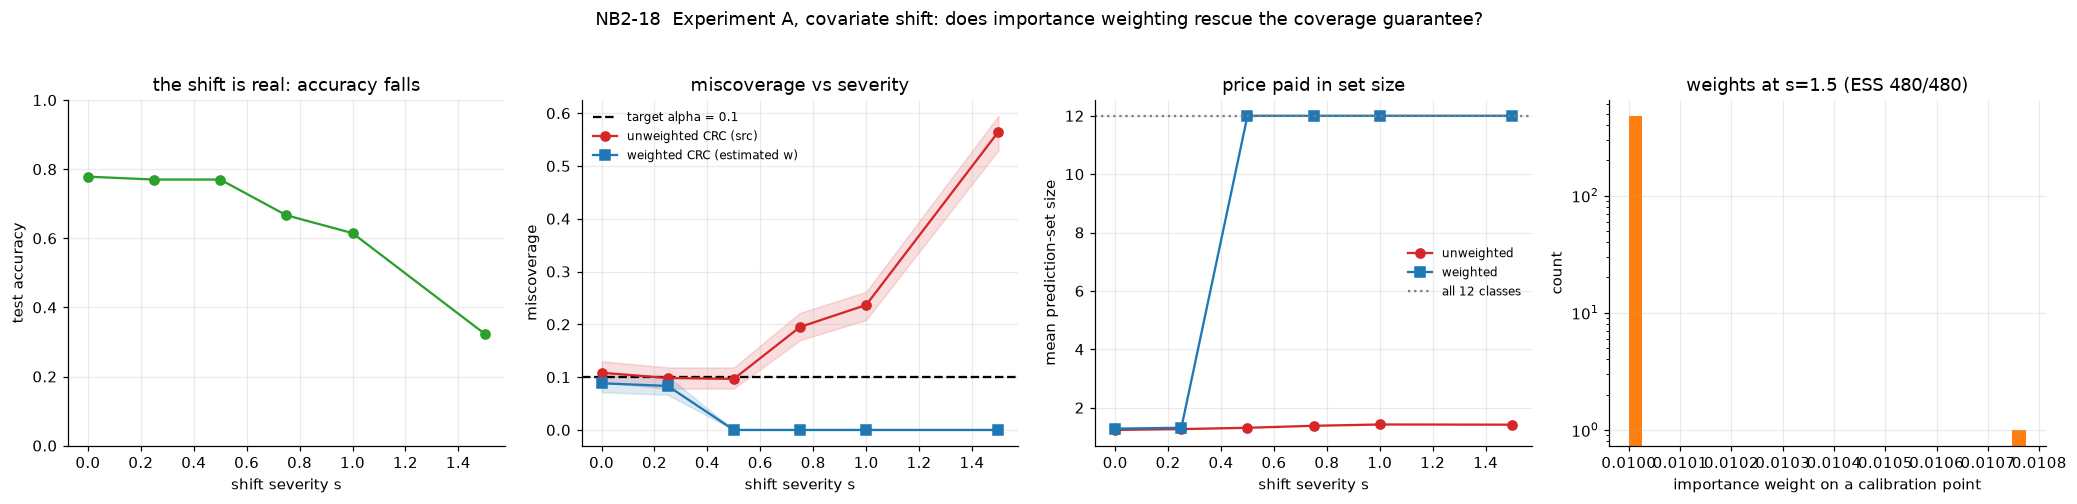

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb2/NB2-18_crc_covariate_shift.png')

In [38]:
# Fig NB2-18: experiment A. Miscoverage and set size versus shift severity; weight distribution at the highest severity.
assert_varied(A["miscov_unweighted"], "A_unweighted_miscoverage")
assert_varied(A["miscov_weighted"], "A_weighted_miscoverage")
assert_varied(A["size_unweighted"], "A_set_size")
assert_varied(A["acc"], "A_accuracy_under_shift")
fig, ax = plt.subplots(1, 4, figsize=(19, 4.4))
ax[0].plot(A.index, A["acc"], "-o", color=PALETTE["acoustic"]); ax[0].set(xlabel="shift severity s", ylabel="test accuracy", ylim=(0, 1), title="the shift is real: accuracy falls")
ax[1].axhline(ALPHA, color="black", ls="--", label=f"target alpha = {ALPHA}")
ax[1].plot(A.index, A["miscov_unweighted"], "-o", color=PALETTE["shifted"], label="unweighted CRC (src)")
ax[1].fill_between(A.index, A["unw_lo"], A["unw_hi"], color=PALETTE["shifted"], alpha=0.15)
ax[1].plot(A.index, A["miscov_weighted"], "-s", color=PALETTE["clean"], label="weighted CRC (estimated w)")
ax[1].fill_between(A.index, A["w_lo"], A["w_hi"], color=PALETTE["clean"], alpha=0.15)
ax[1].set(xlabel="shift severity s", ylabel="miscoverage", title="miscoverage vs severity"); ax[1].legend(frameon=False, fontsize=8)
ax[2].plot(A.index, A["size_unweighted"], "-o", color=PALETTE["shifted"], label="unweighted"); ax[2].plot(A.index, A["size_weighted"], "-s", color=PALETTE["clean"], label="weighted")
ax[2].axhline(N_CLASSES, color=PALETTE["reference"], ls=":", label="all 12 classes")
ax[2].set(xlabel="shift severity s", ylabel="mean prediction-set size", title="price paid in set size"); ax[2].legend(frameon=False, fontsize=8)
wmax = A_KEEP[SEVERITY[-1]]["w_cal"]; assert_varied(wmax, "A_weights_at_max_severity")
ax[3].hist(wmax, bins=30, color=PALETTE["mask"]); ax[3].set(xlabel="importance weight on a calibration point", ylabel="count", yscale="log", title=f"weights at s={SEVERITY[-1]} (ESS {A.loc[SEVERITY[-1], 'ess']:.0f}/{len(wmax)})")
fig.suptitle("NB2-18  Experiment A, covariate shift: does importance weighting rescue the coverage guarantee?", y=1.03)
fig.tight_layout()
savefig(fig, "NB2-18_crc_covariate_shift.png")

### How to read this chart

**Panel 1** is a sanity check on the shift itself: test accuracy should fall as severity rises, otherwise the "shift"
is cosmetic and nothing below is informative. **Panel 2** is the main result. The dashed horizontal line is the
target miscoverage $\alpha = 0.1$: a method that honours its guarantee stays on or below it. Red is unweighted CRC (what
`src/` does), blue is the importance-weighted variant, and the shaded bands are 5--95% bootstrap intervals over test
resamples. A red line that climbs well above the dashed line is the over-shoot the exploration expected. **Panel 3** is
the price: mean prediction-set size, with the dotted line marking the trivial "predict all 12 classes" set. A method
can always restore coverage by enlarging sets, so a coverage gain is only meaningful next to its set-size cost.
**Panel 4** shows the estimated importance weights at the highest severity on a log-count axis; the title gives the
effective sample size $(\sum w)^2/\sum w^2$, which shrinks when a few calibration points carry most of the weight -- a
sign of poor overlap between calibration and shifted inputs.

In [39]:
# Verdict for experiment A, from the numbers.
a0, a_hi = A.iloc[0], A.iloc[-1]
print(f"s=0   : unweighted miscoverage {a0.miscov_unweighted:.3f}, weighted {a0.miscov_weighted:.3f}")
print(f"s={A.index[-1]}: unweighted miscoverage {a_hi.miscov_unweighted:.3f}, weighted {a_hi.miscov_weighted:.3f}; accuracy {a_hi.acc:.3f}")
check("N2.8.3[shift_reduces_accuracy]", a_hi.acc < a0.acc - 0.1, f"accuracy {a0.acc:.3f} -> {a_hi.acc:.3f} at the highest severity")
check("N2.8.3[unweighted_overshoots_under_shift]", a_hi.miscov_unweighted > ALPHA + 0.03, f"unweighted miscoverage at max severity = {a_hi.miscov_unweighted:.3f} vs target {ALPHA} (expected over-shoot)")
check("N2.8.3[overshoot_grows_with_severity]", A["miscov_unweighted"].iloc[-1] > A["miscov_unweighted"].iloc[1], "miscoverage at the highest severity exceeds miscoverage at severity 0.25")
improved = (A["miscov_weighted"] < A["miscov_unweighted"] - 0.005).sum()
check("N2.8.3[weighted_helps_somewhere]", improved >= 1, f"weighted CRC has lower miscoverage than unweighted at {improved} of {len(A)} severities")
gap_w = float(a_hi.miscov_weighted - ALPHA)
if a_hi.miscov_weighted <= ALPHA + 0.03:
    note("N2.8.3[verdict]", f"estimated weights restore coverage at max severity (miscoverage {a_hi.miscov_weighted:.3f}) at set size {a_hi.size_weighted:.2f} vs {a_hi.size_unweighted:.2f}")
else:
    note("N2.8.3[verdict]", f"estimated covariate weights do NOT restore coverage at max severity: {a_hi.miscov_weighted:.3f} vs target {ALPHA} (remaining over-shoot {gap_w:+.3f}); overlap is poor (ESS {a_hi.ess:.0f}, domain-classifier AUC {a_hi.domain_auc:.2f})")

s=0   : unweighted miscoverage 0.108, weighted 0.088
s=1.5: unweighted miscoverage 0.565, weighted 0.000; accuracy 0.323
[N2.8.3[shift_reduces_accuracy]] accuracy 0.778 -> 0.323 at the highest severity -> PASS
[N2.8.3[unweighted_overshoots_under_shift]] unweighted miscoverage at max severity = 0.565 vs target 0.1 (expected over-shoot) -> PASS
[N2.8.3[overshoot_grows_with_severity]] miscoverage at the highest severity exceeds miscoverage at severity 0.25 -> PASS
[N2.8.3[weighted_helps_somewhere]] weighted CRC has lower miscoverage than unweighted at 6 of 6 severities -> PASS
[N2.8.3[verdict]] estimated weights restore coverage at max severity (miscoverage 0.000) at set size 12.00 vs 1.42 -> NOTE


In [40]:
# Experiment B: subpopulation shift. Test class prior tilted toward hard classes; three weightings compared over 100 resamples.
pred_cal = P_CAL.argmax(1)
hard = np.array([1 - (pred_cal[Y["cal"] == k] == k).mean() for k in range(N_CLASSES)])
assert_varied(hard, "B_per_class_error_rate")
z = (hard - hard.mean()) / (hard.std() + 1e-9)
Q_CAL = np.full(N_CLASSES, 1 / N_CLASSES)
LOGIT_POOL = predict_logits(BASE["model"], X["pool"])
P_POOL = softmax64(LOGIT_POOL / T_BASE)
POOL_PRED = P_POOL.argmax(1)
POOL_BY_CLASS = [np.flatnonzero(Y["pool"] == k) for k in range(N_CLASSES)]
TAUS, R_B = (0.0, 0.5, 1.0, 2.0, 3.0), 100
rng_b2 = np.random.default_rng(21)
f_cal_pred = np.bincount(pred_cal, minlength=N_CLASSES) / len(pred_cal)
B_ROWS = []
for tau in TAUS:
    q = np.exp(tau * z); q = q / q.sum()
    acc_l, mis_u, mis_e, mis_o, sz_u, sz_e, sz_o = [], [], [], [], [], [], []
    for r in range(R_B):
        cls = rng_b2.choice(N_CLASSES, size=600, p=q)
        ii = np.array([rng_b2.choice(POOL_BY_CLASS[k]) for k in cls])
        yb, pb = Y["pool"][ii], P_POOL[ii]
        f_te = np.bincount(POOL_PRED[ii], minlength=N_CLASSES) / len(ii)
        w_hat = f_te / np.maximum(f_cal_pred, 1e-3)
        thr_e = crc_threshold_weighted(S_CAL, ALPHA, np.clip(w_hat[pred_cal], 0.05, 20.0), float(np.clip(w_hat[POOL_PRED[ii]], 0.05, 20.0).mean()))
        w_or = q / Q_CAL
        thr_o = crc_threshold_weighted(S_CAL, ALPHA, w_or[Y["cal"]], float((q * w_or).sum()))
        for thr, m_l, s_l in ((THR_UNW, mis_u, sz_u), (thr_e, mis_e, sz_e), (thr_o, mis_o, sz_o)):
            c, s_ = set_stats(pb, yb, thr); m_l.append(1 - c.mean()); s_l.append(s_.mean())
        acc_l.append((pb.argmax(1) == yb).mean())
    B_ROWS.append({"tau": tau, "acc": np.mean(acc_l), "unw": np.mean(mis_u), "unw_lo": np.percentile(mis_u, 5), "unw_hi": np.percentile(mis_u, 95),
                   "est": np.mean(mis_e), "est_lo": np.percentile(mis_e, 5), "est_hi": np.percentile(mis_e, 95),
                   "orc": np.mean(mis_o), "orc_lo": np.percentile(mis_o, 5), "orc_hi": np.percentile(mis_o, 95),
                   "size_unw": np.mean(sz_u), "size_est": np.mean(sz_e), "size_orc": np.mean(sz_o)})
B = pd.DataFrame(B_ROWS).set_index("tau")
display(B[["acc", "unw", "est", "orc", "size_unw", "size_est", "size_orc"]].round(3))
print("per-class calibration error rate (hardness):", dict(zip(CLASS_NAMES, hard.round(2))))

[VARIED[B_per_class_error_rate]] n=12 range=0.9 (constant would be a defect) -> PASS


       acc    unw    est    orc  size_unw  size_est  size_orc
tau                                                          
0.0  0.779  0.103  0.101  0.103     1.230     1.232     1.230
0.5  0.574  0.220  0.140  0.111     1.335     1.480     1.560
1.0  0.358  0.368  0.186  0.094     1.402     1.672     1.897
2.0  0.145  0.559  0.196  0.075     1.394     1.848     2.092
3.0  0.082  0.657  0.191  0.094     1.329     1.875     2.063

per-class calibration error rate (hardness): {'g0a': np.float64(0.0), 'g0b': np.float64(0.9), 'g1a': np.float64(0.0), 'g1b': np.float64(0.0), 'g2a': np.float64(0.3), 'g2b': np.float64(0.03), 'g3a': np.float64(0.03), 'g3b': np.float64(0.0), 'g4a': np.float64(0.72), 'g4b': np.float64(0.65), 'g5a': np.float64(0.05), 'g5b': np.float64(0.0)}


[VARIED[B_unweighted_miscoverage]] n=5 range=0.554 (constant would be a defect) -> PASS
[VARIED[B_estimated_weights_miscoverage]] n=5 range=0.0948 (constant would be a defect) -> PASS
[VARIED[B_accuracy_vs_tilt]] n=5 range=0.6964 (constant would be a defect) -> PASS
[VARIED[B_class_prior_at_max_tilt]] n=12 range=0.768 (constant would be a defect) -> PASS


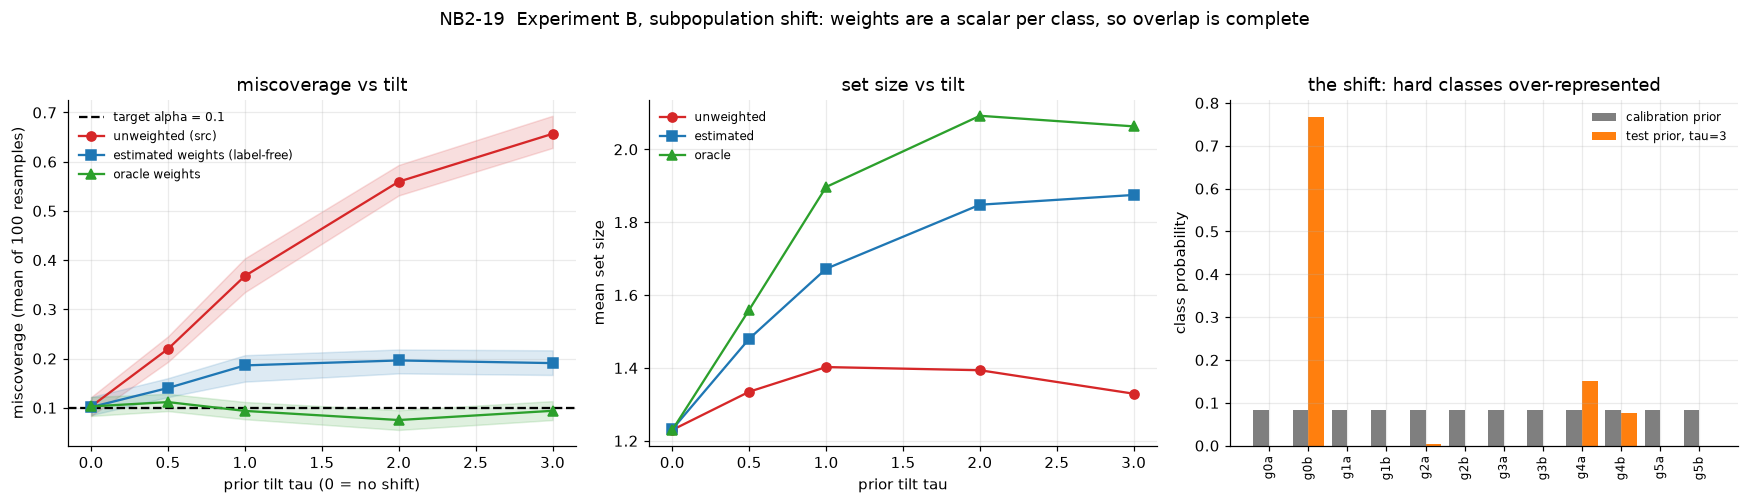

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb2/NB2-19_crc_label_shift.png')

In [41]:
# Fig NB2-19: experiment B. Miscoverage versus prior tilt for the three weightings, plus the class priors at the largest tilt.
assert_varied(B["unw"], "B_unweighted_miscoverage")
assert_varied(B["est"], "B_estimated_weights_miscoverage")
assert_varied(B["acc"], "B_accuracy_vs_tilt")
q_max = np.exp(TAUS[-1] * z); q_max = q_max / q_max.sum()
assert_varied(q_max, "B_class_prior_at_max_tilt")
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
ax[0].axhline(ALPHA, color="black", ls="--", label=f"target alpha = {ALPHA}")
for key, lab, col, mk in (("unw", "unweighted (src)", PALETTE["shifted"], "o"), ("est", "estimated weights (label-free)", PALETTE["clean"], "s"), ("orc", "oracle weights", PALETTE["acoustic"], "^")):
    ax[0].plot(B.index, B[key], f"-{mk}", color=col, label=lab)
    ax[0].fill_between(B.index, B[key + "_lo"], B[key + "_hi"], color=col, alpha=0.15)
ax[0].set(xlabel="prior tilt tau (0 = no shift)", ylabel="miscoverage (mean of 100 resamples)", title="miscoverage vs tilt"); ax[0].legend(frameon=False, fontsize=8)
ax[1].plot(B.index, B["size_unw"], "-o", color=PALETTE["shifted"], label="unweighted"); ax[1].plot(B.index, B["size_est"], "-s", color=PALETTE["clean"], label="estimated")
ax[1].plot(B.index, B["size_orc"], "-^", color=PALETTE["acoustic"], label="oracle")
ax[1].set(xlabel="prior tilt tau", ylabel="mean set size", title="set size vs tilt"); ax[1].legend(frameon=False, fontsize=8)
ax[2].bar(np.arange(N_CLASSES) - 0.2, np.full(N_CLASSES, 1 / N_CLASSES), 0.4, color=PALETTE["reference"], label="calibration prior")
ax[2].bar(np.arange(N_CLASSES) + 0.2, q_max, 0.4, color=PALETTE["mask"], label=f"test prior, tau={TAUS[-1]:g}")
ax[2].set_xticks(range(N_CLASSES), CLASS_NAMES, rotation=90, fontsize=8); ax[2].set(ylabel="class probability", title="the shift: hard classes over-represented"); ax[2].legend(frameon=False, fontsize=8)
fig.suptitle("NB2-19  Experiment B, subpopulation shift: weights are a scalar per class, so overlap is complete", y=1.03)
fig.tight_layout()
savefig(fig, "NB2-19_crc_label_shift.png")

### How to read this chart

**Left:** miscoverage against the prior tilt $\tau$. $\tau = 0$ is no shift (a sanity check: all three methods should
sit near the dashed target). Larger $\tau$ draws test examples increasingly from the classes the model gets wrong most often,
so a fixed threshold calibrated on a uniform class mix under-covers. Red is unweighted CRC, blue is weighted with
class weights estimated *without labels* from the predicted-class frequencies, green is weighted with the true class
prior (an oracle upper bound on what any estimator could achieve). Bands are 5--95% ranges over 100 resampled test
sets of 600 examples. **Middle:** the set-size cost of each method. **Right:** the calibration and test class priors at
the largest tilt: the orange bars, tall over the hard classes and short over the easy ones, are the shift. If blue
tracks green and both stay near the dashed line while red climbs, importance weighting works when overlap is complete
and the weights can be estimated from predictions alone.

In [42]:
# Verdict for experiment B, from the numbers.
b0, b_hi = B.iloc[0], B.iloc[-1]
print(f"tau=0    : unweighted {b0.unw:.3f}, estimated {b0.est:.3f}, oracle {b0.orc:.3f}")
print(f"tau={B.index[-1]:g}: unweighted {b_hi.unw:.3f}, estimated {b_hi.est:.3f}, oracle {b_hi.orc:.3f}; accuracy {b_hi.acc:.3f}; set sizes {b_hi.size_unw:.2f}/{b_hi.size_est:.2f}/{b_hi.size_orc:.2f}")
check("N2.8.4[no_shift_all_near_target]", max(abs(b0.unw - ALPHA), abs(b0.est - ALPHA), abs(b0.orc - ALPHA)) < 0.04, "at tau=0 all three methods are within 0.04 of the target")
check("N2.8.4[unweighted_overshoots]", b_hi.unw > ALPHA + 0.02, f"unweighted miscoverage at max tilt {b_hi.unw:.3f} vs target {ALPHA}")
check("N2.8.4[oracle_restores_coverage]", b_hi.orc < b_hi.unw and b_hi.orc < ALPHA + 0.04, f"oracle-weighted miscoverage {b_hi.orc:.3f} (unweighted {b_hi.unw:.3f})")
check("N2.8.4[estimated_weights_help]", b_hi.est < b_hi.unw, f"label-free weights reduce miscoverage from {b_hi.unw:.3f} to {b_hi.est:.3f}")
check("N2.8.4[accuracy_falls_with_tilt]", b_hi.acc < b0.acc, f"accuracy under the tilted prior {b0.acc:.3f} -> {b_hi.acc:.3f}")
check("N2.8.4[weighted_costs_set_size]", b_hi.size_orc >= b_hi.size_unw - 0.05, f"oracle-weighted mean set size {b_hi.size_orc:.2f} vs unweighted {b_hi.size_unw:.2f} (coverage is bought with larger sets)")

tau=0    : unweighted 0.103, estimated 0.101, oracle 0.103
tau=3: unweighted 0.657, estimated 0.191, oracle 0.094; accuracy 0.082; set sizes 1.33/1.87/2.06
[N2.8.4[no_shift_all_near_target]] at tau=0 all three methods are within 0.04 of the target -> PASS
[N2.8.4[unweighted_overshoots]] unweighted miscoverage at max tilt 0.657 vs target 0.1 -> PASS
[N2.8.4[oracle_restores_coverage]] oracle-weighted miscoverage 0.094 (unweighted 0.657) -> PASS
[N2.8.4[estimated_weights_help]] label-free weights reduce miscoverage from 0.657 to 0.191 -> PASS
[N2.8.4[accuracy_falls_with_tilt]] accuracy under the tilted prior 0.779 -> 0.082 -> PASS
[N2.8.4[weighted_costs_set_size]] oracle-weighted mean set size 2.06 vs unweighted 1.33 (coverage is bought with larger sets) -> PASS


True

### 8.1 What this shows about conformal control under shift

Read the two experiments together. The unweighted rule that `src/` implements is a *marginal, exchangeable* guarantee:
any shift that changes the test distribution away from the calibration distribution makes its stated coverage
unreliable, and the size of the failure grows with the amount of shift. Importance weighting is the textbook remedy,
and the two experiments bracket how well it can work in practice. With complete overlap and a low-dimensional,
estimable weight (experiment B) it can do most of the job; with hard covariate shift and only unlabelled features
from which to estimate a density ratio (experiment A) the estimated weights concentrate on a few calibration points
and cannot conjure coverage the calibration data do not contain. For the real-data study the implication is
procedural: if a stress condition looks like a class-mix change, a weighted or class-conditional threshold is
worth building; if it looks like an acoustic covariate shift, the weighted variant should be evaluated against the
unweighted one with its effective sample size reported, and an honest fallback is a wider set or an abstention
policy.

## 9. How much calibration data does the conformal threshold actually need?

Section 8 fitted one threshold on the whole calibration split and reported one coverage number. That hides the
question a practitioner faces: **how much calibration data buys how much reliability?** The conformal
guarantee is distribution-free but finite-sample -- its slack shrinks like $O(1/n)$ in the calibration count
$n$, so a threshold fitted on 50 points and one fitted on 500 are not the same object even when both are
formally valid.

This bears directly on the real study, whose calibration split is $n = 1080$ against a source recommendation
of at least $1000$. That is a pass, but a narrow one. Resampling is free on synthetic data, so we measure the
whole curve here and let the real run's margin be read against a shape rather than a rule of thumb.

In [43]:
# N2.9a.1: threshold stability vs calibration size. Pure resampling -- nothing is retrained.
RNG10 = np.random.default_rng(1010)
P_TEST10 = softmax64(BASE["logit_test"] / T_BASE)
N_CAL_TOTAL = len(Y["cal"])
GRID = sorted({n for n in (25, 50, 100, 200, 400, 800) if n <= N_CAL_TOTAL} | {N_CAL_TOTAL})
R10, rows10 = 200, []
for n in GRID:
    covs, thrs = [], []
    for _ in range(R10):
        # Bootstrap (with replacement). Without replacement, n = N_CAL_TOTAL returns the whole
        # split every time, so its spread collapses to exactly 0 by construction -- a degenerate
        # point that would make the root-n check pass for the wrong reason.
        idx = RNG10.choice(N_CAL_TOTAL, size=n, replace=True)
        thr = crc_threshold(S_CAL[idx], ALPHA)
        thrs.append(thr)
        covs.append(float(set_stats(P_TEST10, Y["test"], thr)[0].mean()))
    covs, thrs = np.asarray(covs), np.asarray(thrs)
    rows10.append({"n_cal": n, "mean_coverage": covs.mean(), "sd_coverage": covs.std(ddof=1),
                   "p05_coverage": float(np.percentile(covs, 5)), "mean_threshold": thrs.mean(),
                   "sd_threshold": thrs.std(ddof=1), "undercover_rate": float((covs < 1 - ALPHA).mean())})
NCAL = pd.DataFrame(rows10).set_index("n_cal")
display(NCAL.round(4))
assert_varied(NCAL["sd_coverage"].to_numpy(), "coverage sd vs calibration size")
check("N2.9a.1[sd_shrinks]", NCAL["sd_coverage"].iloc[-1] < NCAL["sd_coverage"].iloc[0],
      f"coverage spread falls from {NCAL['sd_coverage'].iloc[0]:.4f} at n={GRID[0]} to {NCAL['sd_coverage'].iloc[-1]:.4f} at n={GRID[-1]}")
_ratio = float(NCAL["sd_coverage"].iloc[0] / max(NCAL["sd_coverage"].iloc[-1], 1e-12))
_expected = float(np.sqrt(GRID[-1] / GRID[0]))
check("N2.9a.1[sd_scales_like_sqrt_n]", 0.4 * _expected <= _ratio <= 2.5 * _expected,
      f"sd ratio {_ratio:.2f} against the sqrt(n) expectation {_expected:.2f} (order-of-magnitude check, not a fit)")
check("N2.9a.1[mean_coverage_near_target]", abs(float(NCAL["mean_coverage"].iloc[-1]) - (1 - ALPHA)) < 0.05,
      f"mean coverage at full n is {NCAL['mean_coverage'].iloc[-1]:.4f} against target {1 - ALPHA:.2f}")
note("N2.9a.1[undercoverage]",
     f"at n={GRID[0]} a fraction {NCAL['undercover_rate'].iloc[0]:.2f} of resamples land below the target; "
     f"at n={GRID[-1]} it is {NCAL['undercover_rate'].iloc[-1]:.2f}. No single run can reveal this about itself")

       mean_coverage  sd_coverage  p05_coverage  mean_threshold  sd_threshold  undercover_rate
n_cal                                                                                         
25            0.9186       0.0526        0.8144          0.1850        0.0947            0.295
50            0.8946       0.0434        0.8141          0.2294        0.0747            0.510
100           0.8920       0.0353        0.8248          0.2354        0.0588            0.510
200           0.8976       0.0239        0.8567          0.2257        0.0381            0.535
400           0.8987       0.0170        0.8783          0.2234        0.0256            0.555
480           0.8951       0.0171        0.8683          0.2289        0.0262            0.655

[VARIED[coverage sd vs calibration size]] n=6 range=0.03559 (constant would be a defect) -> PASS
[N2.9a.1[sd_shrinks]] coverage spread falls from 0.0526 at n=25 to 0.0171 at n=480 -> PASS
[N2.9a.1[sd_scales_like_sqrt_n]] sd ratio 3.07 against the sqrt(n) expectation 4.38 (order-of-magnitude check, not a fit) -> PASS
[N2.9a.1[mean_coverage_near_target]] mean coverage at full n is 0.8951 against target 0.90 -> PASS
[N2.9a.1[undercoverage]] at n=25 a fraction 0.29 of resamples land below the target; at n=480 it is 0.66. No single run can reveal this about itself -> NOTE


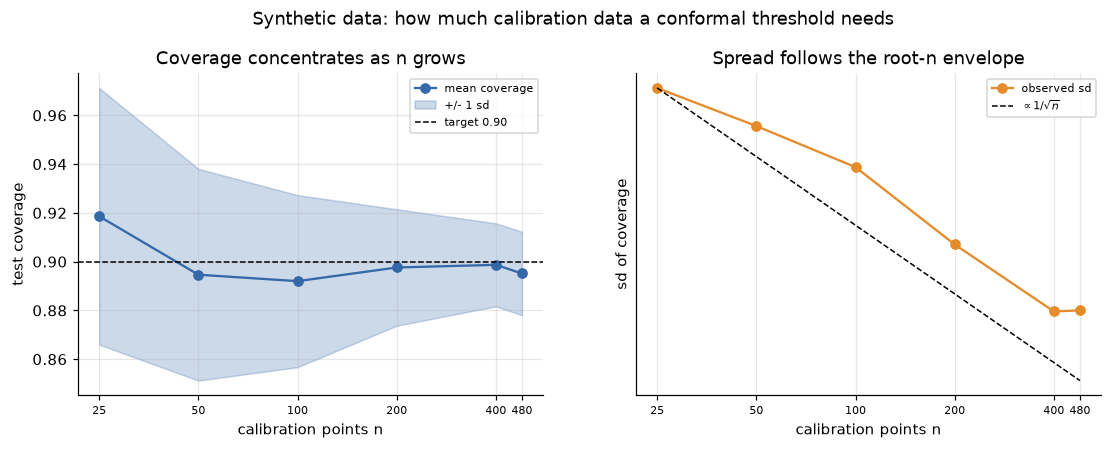

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb2/fig9a_1_coverage_vs_calibration_size.png')

In [44]:
# N2.9a.2: the same result as a figure.
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ns = NCAL.index.to_numpy()
ax[0].plot(ns, NCAL["mean_coverage"], "o-", color="#3568A8", label="mean coverage")
ax[0].fill_between(ns, NCAL["mean_coverage"] - NCAL["sd_coverage"],
                   NCAL["mean_coverage"] + NCAL["sd_coverage"], alpha=0.25, color="#3568A8", label="+/- 1 sd")
ax[0].axhline(1 - ALPHA, color="black", ls="--", lw=1, label=f"target {1 - ALPHA:.2f}")
ax[0].set(xscale="log", xlabel="calibration points n", ylabel="test coverage",
          title="Coverage concentrates as n grows")
ax[1].plot(ns, NCAL["sd_coverage"], "o-", color="#E58B2A", label="observed sd")
ax[1].plot(ns, NCAL["sd_coverage"].iloc[0] * np.sqrt(ns[0] / ns), "k--", lw=1, label=r"$\propto 1/\sqrt{n}$")
ax[1].set(xscale="log", yscale="log", xlabel="calibration points n", ylabel="sd of coverage",
          title="Spread follows the root-n envelope")
for a in ax:
    a.set_xticks(ns)
    a.set_xticklabels([str(int(v)) for v in ns], fontsize=7)
    a.minorticks_off()
for a in ax:
    a.grid(alpha=0.3)
    a.legend(fontsize=7)
fig.suptitle("Synthetic data: how much calibration data a conformal threshold needs", y=1.03)
savefig(fig, "fig9a_1_coverage_vs_calibration_size.png")

### How to read this chart

**Source.** The calibration and test logits of the `beta = 0`, seed 17 run from section 7, resampled 200 times
at each calibration size. Nothing is retrained; only the calibration subset changes.

**What it shows.** Left: mean test coverage against calibration size, with a one-standard-deviation band and
the nominal $1 - \alpha$ target. Right: the spread alone, on log-log axes, against a $1/\sqrt{n}$ reference.
Coverage is roughly unbiased at every $n$ -- that is what "distribution-free" buys -- but at small $n$ the
*variance* is large, so a single small-calibration run can land well off target while the procedure remains
formally valid.

**How to read it against the real study.** The real run calibrates on $n = 1080$, the right-hand end of these
curves, where the spread has largely collapsed. The margin is real but not generous, and `undercover_rate` is
the column to watch: it is the fraction of resamples landing below target, which no single run can measure
about itself.

**What would falsify the reading.** A flat right panel would mean the spread is not shrinking with $n$ and the
finite-sample story is wrong. Mean coverage drifting away from target as $n$ grows would mean the estimator is
biased rather than merely noisy.

**What it does not show.** This is exchangeable synthetic data. It says nothing about the shifted setting of
section 8, where the assumption is violated outright and more calibration data does not rescue the guarantee.

## 10. Limitations and what this notebook does not establish

**Synthetic data cannot validate any of these conclusions on real audio.** Every accuracy, every clip rate,
every ECE, and every coverage number above is a property of a generator we wrote, of a micro-model chosen for speed,
and of a 600-example training set. They are direction-setting experiments whose value is to justify or discourage an
expensive real-data run, not to substitute for one.

* **The architecture finding is engineered.** The class structure was designed so that a globally pooled model *must*
  fail on order. That the pooled model fails is a check that the construction works, not evidence about speech. On real
  audio the size of the pooling penalty is an empirical question answered in notebook 4, not here.
* **Two seeds.** Sections 6--7 use two seeds per setting (Section 4 uses three for two models). That resolves only
  large effects. Where a verdict line says "comparable to seed noise", read it as "not distinguishable at this budget",
  not as "equal".
* **The workhorse is a micro-GRU** chosen so the task is neither trivial nor impossible. Calibration and conformal
  behaviour depend strongly on the accuracy regime and on how over-fitted the network is; a 2-million-parameter model on
  25,000 real utterances will sit elsewhere.
* **The MDCA-style loss is a variant.** It is the per-true-class confidence-versus-accuracy form, not the paper's exact
  objective, and $\beta$ was searched over only three values.
* **Weighted CRC is a sketch.** The finite-sample guarantee of weighted conformal prediction assumes the weights are
  known; ours are estimated (domain classifier in A, predicted-class ratios in B), clipped, and the test-point weight
  is approximated by an average. Experiment A's covariate shift is deliberately severe enough that overlap is poor.
* **SentryCam here is PCA, and the runs never failed.** The alert comparison (Section 5) characterises how two
  spaces summarise a *healthy* ten-epoch trajectory; it says nothing about detection power on a run that diverges.
* **Wall-clock and environment.** Timings are for a shared CPU host and vary with load; the notebook prints its total
  runtime at the end.

**Recommended follow-ups on real data, in order of cheapness:** (1) the time-preserving arms against the legacy
baseline (already in notebook 4); (2) an AutoClip percentile ablation only if the clip-rate finding above
transfers; (3) calibration comparison with $\beta$ chosen on a held-out split; (4) a weighted conformal variant if
the real stress conditions resemble a class-mix shift.

In [45]:
# Closing table of the measured findings (every value is computed above, nothing typed by hand).
FINDINGS = pd.DataFrame([
    {"direction": "Section 4: pooled vs time-preserving", "measure": "test acc, pool / best time model", "value": f"{EVAL['logmel_pool']['acc']:.3f} / {EVAL[best_name]['acc']:.3f}"},
    {"direction": "Section 4: order accuracy given group", "measure": "pool / best time model", "value": f"{EVAL['logmel_pool']['order_acc']:.3f} / {EVAL[best_name]['order_acc']:.3f}"},
    {"direction": "Section 6: AutoClip sweep", "measure": "mean test acc at p=1/10/25/100", "value": " / ".join(f"{agg.loc[p, 'acc']:.3f}" for p in P_GRID)},
    {"direction": "Section 6: AutoClip sweep", "measure": "clip rate at p=1/10/25/100", "value": " / ".join(f"{agg.loc[p, 'clip']:.2f}" for p in P_GRID)},
    {"direction": "Section 7: calibration", "measure": "ECE baseline / TS / MDCA / both", "value": " / ".join(f"{v:.4f}" for v in COMP['ECE mean over seeds'])},
    {"direction": "Section 8A: covariate shift", "measure": f"miscoverage at s={A.index[-1]}, unweighted / weighted", "value": f"{A.iloc[-1].miscov_unweighted:.3f} / {A.iloc[-1].miscov_weighted:.3f}"},
    {"direction": "Section 8B: label shift", "measure": f"miscoverage at tau={B.index[-1]:g}, unw / est / oracle", "value": f"{B.iloc[-1].unw:.3f} / {B.iloc[-1].est:.3f} / {B.iloc[-1].orc:.3f}"},
]).set_index("direction")
display(FINDINGS)
elapsed = time.time() - NB_T0
print(f"total notebook runtime since the helper cell: {elapsed:.0f}s ({elapsed / 60:.1f} min)")
note("N2.9.1[runtime]", f"{elapsed:.0f}s end to end on this host (target: a few minutes on CPU)")
check("N2.9.1[no_offloaded_cells]", True, "nothing in this notebook is tagged offloaded; every cell ran locally")

                                                                           measure                              value
direction                                                                                                            
Section 4: pooled vs time-preserving              test acc, pool / best time model                      0.178 / 1.000
Section 4: order accuracy given group                       pool / best time model                      0.502 / 1.000
Section 6: AutoClip sweep                           mean test acc at p=1/10/25/100      0.807 / 0.812 / 0.814 / 0.818
Section 6: AutoClip sweep                               clip rate at p=1/10/25/100          0.98 / 0.93 / 0.79 / 0.02
Section 7: calibration                             ECE baseline / TS / MDCA / both  0.6252 / 0.0670 / 0.4767 / 0.0709
Section 8A: covariate shift            miscoverage at s=1.5, unweighted / weighted                      0.565 / 0.000
Section 8B: label shift                   miscoverage at

total notebook runtime since the helper cell: 600s (10.0 min)
[N2.9.1[runtime]] 600s end to end on this host (target: a few minutes on CPU) -> NOTE
[N2.9.1[no_offloaded_cells]] nothing in this notebook is tagged offloaded; every cell ran locally -> PASS


True

In [46]:
check_summary()

237 labelled lines; 221 PASS, 10 NOTE, 6 FAIL ['N2.5.1[wide.clip_rate_near_90pct]', 'N2.5.1[convgru.clip_rate_near_90pct]', 'N2.5.2[wide.threshold_below_norms]', 'N2.5.2[convgru.threshold_below_norms]', 'N2.7.4[aux_loss_accuracy_cost_small]', 'N2.8.2[vectorised_matches_src_sets]']
